# MoTrPAC pre-hackathon findings — replication notebook

This notebook re-derives the pre-hackathon findings of the evaluation pipeline in `code/pipeline/`
as one readable narrative. It is a presentation and a check, not new analysis (except the last,
clearly-marked section on a covariates-only baseline).

**Two notebooks.** The replication is split at the section 8/9 boundary: `01_replication.ipynb` holds
sections 1–8 (inventory to shift tests) and `02_transfer.ipynb` holds sections 9–14 (BodyMap, GTEx,
fusion, discordance, the QC-only baseline, limitations). Each runs on its own from the same header and
library, and each ends with the self-check of its own rows of `expected_values.csv`.

**How to read it.** Each section has three parts: *(a)* the question, why it matters and what to look
for; *(b)* the code, commented; *(c)* what the output shows — and what it does not show. The markdown
never states a result number: every number is printed by a code cell, computed in this run or read
from a `results/` CSV in this run. The last cell compares the printed numbers with
`expected_values.csv` and prints a pass/fail table.

**Self-contained.** The notebook does not import the pipeline package. The pipeline's library
(`src/tfp/`) is pasted in below, verbatim, and the logic of each pipeline script is copied into
the section that needs it, with a comment naming its source file and function.

**Two modes.**
- `RECOMPUTE = False` (default): the expensive legs (the 100-split certificate, stability selection,
  fusion tasks, batch-covariate permutation nulls, BodyMap/GTEx transfer) are *loaded* from
  `results/`; everything cheap is recomputed live. Target: under 10 minutes.
- `RECOMPUTE = True`: everything is recomputed from the exported data (about an hour); outputs go to
  `notebooks/_outputs/`, never over `results/`.

Set the mode in the next cell, or with the environment variable `NB_RECOMPUTE=1`.

In [1]:
NOTEBOOK_NAME = "02_transfer.ipynb"

In [2]:
# ---- imports: numpy / pandas / scikit-learn / scipy / matplotlib only (the pipeline's core-path rule) ----
from __future__ import annotations

import itertools
import json
import os
import re
import time
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from types import SimpleNamespace
from typing import Iterable, Iterator

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 4)

# ---- mode ----
RECOMPUTE = os.environ.get("NB_RECOMPUTE", "0") == "1"


# ---- paths: found from this notebook's location (code/pipeline/notebooks/), overridable ----
def _find_pipeline_root() -> Path:
    """The pipeline directory is the nearest ancestor of the working directory holding src/tfp and
    results/. Override with MOTRPAC_PIPELINE_ROOT (the pipeline's own MOTRPAC_ROOT is not used here,
    because in the rest of the repo MOTRPAC_ROOT means the repository root)."""
    if os.environ.get("MOTRPAC_PIPELINE_ROOT"):
        return Path(os.environ["MOTRPAC_PIPELINE_ROOT"]).resolve()
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "tfp").is_dir() and (p / "results").is_dir():
            return p
    raise FileNotFoundError("run this notebook from code/pipeline/notebooks/ or set MOTRPAC_PIPELINE_ROOT")


PIPE = _find_pipeline_root()                 # code/pipeline
REPO = PIPE.parents[1]                       # repository root (holds data/, docs/)
RES = PIPE / "results"                       # the pipeline's published results (read-only here)
NB = PIPE / "notebooks"
OUT = NB / "_outputs"                        # everything this notebook writes goes here
OUT.mkdir(parents=True, exist_ok=True)
print("pipeline root :", PIPE)
print("results       :", RES)
print("outputs       :", OUT)
print("RECOMPUTE     :", RECOMPUTE)


# ---- section timer: section("3 …") closes the previous section's clock and starts a new one ----
_TIMES: dict[str, float] = {}
_CURRENT = {"name": None, "t0": None}


def section(name: str | None) -> None:
    now = time.perf_counter()
    if _CURRENT["name"] is not None:
        _TIMES[_CURRENT["name"]] = _TIMES.get(_CURRENT["name"], 0.0) + now - _CURRENT["t0"]
    _CURRENT.update(name=name, t0=now)


def timing_table() -> pd.DataFrame:
    section(None)
    t = pd.Series(_TIMES, name="seconds").round(1).to_frame()
    t.loc["TOTAL"] = t["seconds"].sum()
    return t


section("0 setup + library")


# ---- self-check registry: record(key, value) stores a number this run printed ----
CHECKS: dict[str, dict] = {}


def record(key: str, value, section_id: str, note: str = "") -> None:
    """Keep a value for the final self-check against expected_values.csv. Returns nothing; print the
    value in the section itself so the reader sees it where it is computed."""
    CHECKS[key] = {"value": float(value), "section": section_id, "note": note}


def res(*parts) -> Path:
    """Path of a published result file; fails loudly if the pipeline has not produced it."""
    p = RES.joinpath(*parts)
    if not p.exists():
        raise FileNotFoundError(f"missing pipeline result {p} (run the pipeline phase that writes it)")
    return p




# ---- small cache so sections that need the same big matrix load it once per run ----
_CACHE: dict[str, object] = {}


def cached(key: str, fn):
    if key not in _CACHE:
        _CACHE[key] = fn()
    return _CACHE[key]

pipeline root : <repo>
results       : <repo>/results
outputs       : <repo>/notebooks/_outputs
RECOMPUTE     : False


**Every figure and table is also written to a run folder.** The next cell installs small hooks, so the
sections need no extra code. Each run of a notebook gets a folder `notebooks/runs/<YYYY-MM-DD_HHMMSS>/`,
which holds:
- `figures/`: every figure shown with `plt.show()` or `show_png()`, as PNG;
- `tables/`: every table shown with `display()` or printed with `.to_string()`, as CSV;
- `logs/`: everything printed, one text file per section;
- `index.csv`: one row per file (notebook, section, kind, shape, columns).

To collect both notebooks in one folder, set the same `NB_RUN_STAMP` for both runs.

In [3]:
# ---- capture: figures / tables / printed output of this run → runs/<date_time>/ (notebook-only helper) ----
import shutil
import sys
from datetime import datetime

RUN_STAMP = os.environ.get("NB_RUN_STAMP") or datetime.now().strftime("%Y-%m-%d_%H%M%S")
RUN_DIR = NB / "runs" / RUN_STAMP
for _d in ("figures", "tables", "logs"):
    (RUN_DIR / _d).mkdir(parents=True, exist_ok=True)
_CAP = {"n": {}}


def _cap_name(kind: str, ext: str) -> Path:
    nb = globals().get("NOTEBOOK_NAME", "notebook.ipynb").replace(".ipynb", "")
    sec = re.sub(r"[^0-9A-Za-z]+", "-", str(_CURRENT["name"] or "setup")).strip("-")
    k = _CAP["n"][(nb, sec, kind)] = _CAP["n"].get((nb, sec, kind), 0) + 1
    return RUN_DIR / f"{kind}s" / f"{nb}__{sec}__{kind}{k:02d}.{ext}"


def _cap_index(path: Path, kind: str, shape="", columns="") -> None:
    row = pd.DataFrame([{"file": str(path.relative_to(RUN_DIR)), "kind": kind,
                         "notebook": globals().get("NOTEBOOK_NAME", ""), "section": _CURRENT["name"],
                         "shape": shape, "columns": columns}])
    idx = RUN_DIR / "index.csv"            # appended, so two notebooks can share one run folder
    row.to_csv(idx, mode="a", header=not idx.exists(), index=False)


def _cap_table(obj) -> None:
    if hasattr(obj, "data") and type(obj).__name__ == "Styler":
        obj = obj.data
    if isinstance(obj, pd.Series):
        obj = obj.to_frame()
    if isinstance(obj, pd.DataFrame):
        p = _cap_name("table", "csv")
        obj.to_csv(p)
        _cap_index(p, "table", "x".join(map(str, obj.shape)), ";".join(map(str, obj.columns))[:300])


# display(): save tables, then show them as usual
_display_orig = display


def display(*objs, **kw):
    for o in objs:
        try:
            _cap_table(o)
        except Exception as e:                      # capturing must never break the analysis
            print(f"[capture] table not saved: {e}")
    return _display_orig(*objs, **kw)


# DataFrame/Series.to_string(): save when called from notebook code (not from pandas' own repr)
def _wrap_to_string(cls):
    orig = cls.to_string

    def to_string(self, *a, **kw):
        caller = sys._getframe(1).f_code.co_filename
        if "site-packages" not in caller and "/pandas/" not in caller:
            try:
                _cap_table(self)
            except Exception as e:
                print(f"[capture] table not saved: {e}")
        return orig(self, *a, **kw)
    to_string.__wrapped__ = orig
    cls.to_string = to_string


for _cls in (pd.DataFrame, pd.Series):
    if not hasattr(_cls.to_string, "__wrapped__"):   # idempotent if the header cell is re-run
        _wrap_to_string(_cls)

# plt.show(): save every open figure first
_plt_show_orig = getattr(plt.show, "__wrapped__", plt.show)


def _show(*a, **kw):
    for num in plt.get_fignums():
        p = _cap_name("figure", "png")
        plt.figure(num).savefig(p, dpi=150, bbox_inches="tight")
        _cap_index(p, "figure")
    return _plt_show_orig(*a, **kw)


_show.__wrapped__ = _plt_show_orig
plt.show = _show


# show_png(): the library's plot functions save a PNG themselves; copy it into the run folder
def show_png(path: Path, width: int = 700) -> None:
    p = _cap_name("figure", "png")
    shutil.copyfile(path, p)
    _cap_index(p, "figure")
    _display_orig(Image(filename=str(path), width=width))


# printed output: tee stdout into one log file per section
class _Tee:
    def __init__(self, stream):
        self._s, self._f, self._name = stream, None, None

    def write(self, t):
        name = _CURRENT["name"]
        if name != self._name:
            if self._f:
                self._f.close()
            nb = globals().get("NOTEBOOK_NAME", "notebook.ipynb").replace(".ipynb", "")
            sec = re.sub(r"[^0-9A-Za-z]+", "-", str(name or "setup")).strip("-")
            self._f, self._name = open(RUN_DIR / "logs" / f"{nb}__{sec}.txt", "a"), name
        self._f.write(t)
        self._f.flush()
        return self._s.write(t)

    def flush(self):
        return self._s.flush()

    def __getattr__(self, k):
        return getattr(self._s, k)


if type(sys.stdout).__name__ != "_Tee":     # idempotent if the cell is re-run
    sys.stdout = _Tee(sys.stdout)
print("figures, tables and printed output of this run are saved under", RUN_DIR)

figures, tables and printed output of this run are saved under <repo>/notebooks/runs/2026-09-26_121031


## Appendix-in-place: the pipeline library, copied verbatim

The cells below are the source of `src/tfp/` (the pipeline's library), pasted in so this notebook runs
without importing it. Three mechanical edits only: package-relative imports (`from . import …`) are
removed because everything shares one namespace; `matplotlib.use("Agg")` is removed so figures can show;
and in `config`, the path constants are computed from this notebook's location instead of the file's.
After each module, a namespace object (`C`, `io`, `splits`, `models`, `cp`, `discordance`, `transfer`,
`plots`) is created so code copied from the scripts can keep calling e.g. `cp.predict_sets(...)`.

**Drift check.** The cell right after the library re-reads each `src/tfp/*.py` from disk (when the
notebook sits in its repository), applies the same three edits with the same function the notebook
builder uses (`transform_module`, pasted in), and compares the result with the library code that actually
executed in this kernel. It prints an identical / differs table and **raises** if any module differs. So
a run that gets past it used exactly the library in `src/`. If `src/tfp` is not reachable (the
notebook was copied elsewhere), it says the inline copy could not be verified, and continues.

In [4]:
# ===== copied verbatim from src/tfp/config.py (see the note above for the 3 mechanical edits) =====
"""Paths, constants, and small helpers shared by every phase."""
# [notebook] removed: from __future__ import annotations

import os
from pathlib import Path

ROOT = PIPE  # [notebook] was: Path(os.environ.get("MOTRPAC_ROOT", Path(__file__).resolve().parents[2]))
DATA_DIR = ROOT / "data"
RAW_DIR = Path(os.environ.get("MOTRPAC_RAW", DATA_DIR / "raw"))
NORM_DIR = RAW_DIR / "norm"
COUNTS_DIR = RAW_DIR / "counts"
DA_DIR = RAW_DIR / "da"
META_DIR = RAW_DIR / "meta"
CODES_DIR = RAW_DIR / "codes"
EXTERNAL_DIR = DATA_DIR / "external"
RESULTS_DIR = PIPE / "results"  # [notebook] read-only here; notebook outputs go to OUT
FIG_DIR = RESULTS_DIR / "figures"

SEED = 20260925

TISSUES = [
    "ADRNL", "BAT", "BLOOD", "COLON", "CORTEX", "HEART", "HIPPOC", "HYPOTH", "KIDNEY", "LIVER",
    "LUNG", "OVARY", "PLASMA", "SKM-GN", "SKM-VL", "SMLINT", "SPLEEN", "TESTES", "VENACV", "WAT-SC",
]
ASSAYS = ["TRNSCRPT", "PROT", "PHOSPHO", "ACETYL", "UBIQ", "METAB", "IMMUNO", "ATAC", "METHYL"]
GROUP_ORDER = ["control", "1w", "2w", "4w", "8w"]
SEXES = ["female", "male"]

# Sample-level tables start with these four columns, then one column per viallabel.
LEADING_COLS = ["feature", "feature_ID", "tissue", "assay"]

PANEL_GRID = [1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 100]
ALPHAS = [0.05, 0.10, 0.20]


def tissue_token(tissue: str) -> str:
    """'SKM-GN' -> 'SKMGN' (R object / file-name form)."""
    return tissue.replace("-", "").upper()


_TOKEN_TO_TISSUE = {tissue_token(t): t for t in TISSUES}


def tissue_from_token(token: str) -> str:
    """'SKMGN' -> 'SKM-GN'; unknown tokens pass through unchanged."""
    return _TOKEN_TO_TISSUE.get(token.upper(), token)


def ensure_dirs() -> None:
    for d in (RESULTS_DIR, FIG_DIR):
        d.mkdir(parents=True, exist_ok=True)

In [5]:
# expose module `config` as `C.<name>`, the way the pipeline scripts call it
C = SimpleNamespace(os=os, Path=Path, ROOT=ROOT, DATA_DIR=DATA_DIR, RAW_DIR=RAW_DIR, NORM_DIR=NORM_DIR, COUNTS_DIR=COUNTS_DIR, DA_DIR=DA_DIR, META_DIR=META_DIR, CODES_DIR=CODES_DIR, EXTERNAL_DIR=EXTERNAL_DIR, RESULTS_DIR=RESULTS_DIR, FIG_DIR=FIG_DIR, SEED=SEED, TISSUES=TISSUES, ASSAYS=ASSAYS, GROUP_ORDER=GROUP_ORDER, SEXES=SEXES, LEADING_COLS=LEADING_COLS, PANEL_GRID=PANEL_GRID, ALPHAS=ALPHAS, tissue_token=tissue_token, _TOKEN_TO_TISSUE=_TOKEN_TO_TISSUE, tissue_from_token=tissue_from_token, ensure_dirs=ensure_dirs)

In [6]:
# ===== copied verbatim from src/tfp/io.py (see the note above for the 3 mechanical edits) =====
"""Loaders for the exported MoTrPAC tables (see docs/DATA_GUIDE.md for the layout).

Everything returns an `OmicsMatrix`: samples × features with sample metadata that always
carries `pid` (animal) so downstream code can group splits correctly.
"""
# [notebook] removed: from __future__ import annotations

import json
import re
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd

# [notebook] removed: from . import config as C


# ---------------------------------------------------------------------------------------
# Container
# ---------------------------------------------------------------------------------------
@dataclass
class OmicsMatrix:
    X: pd.DataFrame            # samples (index=viallabel) × features (columns=feature_ID)
    meta: pd.DataFrame         # index=viallabel; columns include pid, bid, sex, group, tissue, assay
    features: pd.DataFrame     # index=feature_ID; feature (regulated flag), assay, gene_symbol (if mapped)
    assay: str
    name: str = ""
    notes: list[str] = field(default_factory=list)

    @property
    def n_samples(self) -> int:
        return self.X.shape[0]

    @property
    def n_features(self) -> int:
        return self.X.shape[1]

    @property
    def n_animals(self) -> int:
        return int(self.meta["pid"].nunique())

    def groups(self) -> np.ndarray:
        return self.meta["pid"].to_numpy()

    def y(self, col: str) -> np.ndarray:
        return self.meta[col].to_numpy()

    def subset(self, mask) -> "OmicsMatrix":
        mask = np.asarray(mask, dtype=bool)
        return OmicsMatrix(self.X.loc[mask], self.meta.loc[mask], self.features, self.assay,
                           self.name, list(self.notes))

    def select_features(self, feature_ids: Iterable[str]) -> "OmicsMatrix":
        ids = [f for f in feature_ids if f in self.X.columns]
        return OmicsMatrix(self.X[ids], self.meta, self.features.loc[ids], self.assay,
                           self.name, list(self.notes))

    def __repr__(self) -> str:
        return (f"OmicsMatrix({self.name or self.assay}: {self.n_samples} samples, "
                f"{self.n_features} features, {self.n_animals} animals)")


# ---------------------------------------------------------------------------------------
# Low-level readers
# ---------------------------------------------------------------------------------------
_FILE_RE = re.compile(r"^([A-Z]+)__([A-Z]+)\.csv$")


def list_sample_files(kind: str = "norm", raw_dir: Path | None = None) -> pd.DataFrame:
    """Scan data/raw/<kind>/ for <ASSAY>__<TISSUE>.csv files."""
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    d = raw_dir / kind
    rows = []
    if d.exists():
        for p in sorted(d.glob("*.csv")):
            m = _FILE_RE.match(p.name)
            if not m:
                continue
            assay, tok = m.group(1), m.group(2)
            rows.append({"assay": assay, "tissue_token": tok, "tissue": C.tissue_from_token(tok),
                         "path": str(p), "kind": kind})
    return pd.DataFrame(rows, columns=["assay", "tissue_token", "tissue", "path", "kind"])


def _dedupe_index(ids: pd.Series) -> pd.Index:
    """Make feature IDs unique (append __dupN) without dropping anything."""
    ids = ids.astype(str)
    if ids.is_unique:
        return pd.Index(ids)
    counts = {}
    out = []
    for v in ids:
        n = counts.get(v, 0)
        out.append(v if n == 0 else f"{v}__dup{n}")
        counts[v] = n + 1
    return pd.Index(out)


def read_sample_table(path: str | Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Read a features × samples CSV. Returns (feature_table indexed by feature_ID, values)."""
    df = pd.read_csv(path, dtype={c: str for c in C.LEADING_COLS}, low_memory=False)
    lead = [c for c in C.LEADING_COLS if c in df.columns]
    if "feature_ID" not in lead:
        raise ValueError(f"{path}: no feature_ID column; columns start with {list(df.columns[:6])}")
    feat = df[lead].copy()
    vals = df.drop(columns=lead)
    vals.columns = vals.columns.astype(str)
    vals = vals.apply(pd.to_numeric, errors="coerce")
    idx = _dedupe_index(feat["feature_ID"])
    feat.index = idx
    vals.index = idx
    return feat, vals


# ---------------------------------------------------------------------------------------
# Phenotype table
# ---------------------------------------------------------------------------------------
def _first_present(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None


def load_pheno(raw_dir: Path | None = None) -> pd.DataFrame:
    """PHENO with standardized columns: viallabel (index), pid, bid, sex, group, tissue_long.

    Column names in the package use either '.' or '___' separators depending on version;
    both are handled. Sex is 'male'/'female'; group is control/1w/2w/4w/8w.
    """
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    path = raw_dir / "pheno.csv"
    ph = pd.read_csv(path, dtype=str, low_memory=False)
    if "viallabel" not in ph.columns:
        raise ValueError("pheno.csv has no viallabel column")
    ph["viallabel"] = ph["viallabel"].str.strip()
    ph["bid"] = ph["bid"].str.strip() if "bid" in ph.columns else ph["viallabel"].str[:5]
    if "pid" not in ph.columns:
        raise ValueError("pheno.csv has no pid column")
    ph["pid"] = ph["pid"].str.strip()

    # sex
    sex_col = _first_present(ph, ["sex", "registration___sex", "registration.sex"])
    if sex_col is None:
        raise ValueError("no sex column in pheno")
    sex = ph[sex_col].str.strip().str.lower()
    sex = sex.replace({"1": "female", "2": "male", "f": "female", "m": "male"})
    ph["sex"] = sex

    # group / time point
    grp_col = _first_present(ph, ["group", "study_group_timepoint", "sacrificetime"])
    if grp_col is None:
        raise ValueError("no group column in pheno")
    g = ph[grp_col].astype(str).str.strip().str.lower()
    if grp_col != "group":
        # 'control - 1w' -> 'control', 'training - 8w' -> '8w'
        def _parse(v: str) -> str:
            if "control" in v:
                return "control"
            m = re.search(r"(\d)w", v)
            return f"{m.group(1)}w" if m else v
        g = g.map(_parse)
    ph["group"] = g

    tl = _first_present(ph, ["specimen_processing___sampletypedescription",
                             "specimen.processing.sampletypedescription", "tissue"])
    ph["tissue_long"] = ph[tl] if tl else np.nan

    ph = ph.drop_duplicates("viallabel").set_index("viallabel")
    return ph


# ---------------------------------------------------------------------------------------
# Sample metadata assembly
# ---------------------------------------------------------------------------------------
META_COLS = ["pid", "bid", "sex", "group", "tissue", "assay"]


def sample_meta_for(viallabels: Iterable[str], pheno: pd.DataFrame, tissue: str, assay: str) -> pd.DataFrame:
    """Join sample columns (viallabels) to PHENO; fall back to bid-level join if needed."""
    vl = pd.Index([str(v) for v in viallabels], name="viallabel")
    meta = pd.DataFrame(index=vl)
    hit = pheno.reindex(vl)
    meta["pid"] = hit["pid"].values
    meta["bid"] = hit["bid"].values
    meta["sex"] = hit["sex"].values
    meta["group"] = hit["group"].values
    missing = meta["pid"].isna()
    if missing.any():
        # bid is the first 5 characters of the viallabel; PHENO has one row per vial, so
        # any bid should resolve to an animal even if this exact vial is absent.
        by_bid = pheno.drop_duplicates("bid").set_index("bid")
        bids = vl[missing].str[:5]
        fb = by_bid.reindex(bids)
        meta.loc[missing, "pid"] = fb["pid"].values
        meta.loc[missing, "bid"] = bids.values
        meta.loc[missing, "sex"] = fb["sex"].values
        meta.loc[missing, "group"] = fb["group"].values
    still = meta["pid"].isna().sum()
    if still:
        warnings.warn(f"{tissue}/{assay}: {still} samples have no PHENO match and will be dropped")
    meta["tissue"] = tissue
    meta["assay"] = assay
    return meta


# ---------------------------------------------------------------------------------------
# Matrix loaders
# ---------------------------------------------------------------------------------------
def load_norm(assay: str, tissue: str, pheno: pd.DataFrame | None = None,
              raw_dir: Path | None = None) -> OmicsMatrix:
    """Normalized sample-level data for one assay × tissue."""
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    pheno = load_pheno(raw_dir) if pheno is None else pheno
    path = raw_dir / "norm" / f"{assay}__{C.tissue_token(tissue)}.csv"
    feat, vals = read_sample_table(path)
    meta = sample_meta_for(vals.columns, pheno, C.tissue_from_token(C.tissue_token(tissue)), assay)
    keep = ~meta["pid"].isna()
    X = vals.T.loc[keep.values]
    X.index.name = "viallabel"
    features = feat.drop(columns=["feature_ID"], errors="ignore")
    features["assay"] = assay
    return OmicsMatrix(X, meta.loc[keep], features, assay, name=f"{assay}/{tissue}")


def _read_counts_table(tissue: str, pheno: pd.DataFrame, assay: str = "TRNSCRPT",
                       raw_dir: Path | None = None) -> OmicsMatrix:
    """Raw counts for one tissue as an OmicsMatrix (samples × genes, NaN → 0); unfiltered, not logged."""
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    path = raw_dir / "counts" / f"{assay}__{C.tissue_token(tissue)}.csv"
    feat, counts = read_sample_table(path)
    counts = counts.fillna(0.0)
    meta = sample_meta_for(counts.columns, pheno, C.tissue_from_token(C.tissue_token(tissue)), assay)
    keep = ~meta["pid"].isna()
    X = counts.T.loc[keep.values]
    X.index.name = "viallabel"
    features = feat.drop(columns=["feature_ID"], errors="ignore")
    features["assay"] = assay
    return OmicsMatrix(X, meta.loc[keep], features, assay, name=f"{assay}-rawcounts/{tissue}")


def log_cpm(counts: pd.DataFrame, log: bool = True) -> pd.DataFrame:
    """samples × genes counts → CPM (library size = row sum over the genes given) → log2(CPM + 1)."""
    lib = counts.sum(axis=1).replace(0, np.nan)
    cpm = counts.div(lib, axis=0) * 1e6
    return np.log2(cpm + 1.0) if log else cpm


def load_counts(tissue: str, pheno: pd.DataFrame | None = None, assay: str = "TRNSCRPT",
                min_count: int = 10, min_frac: float = 0.2, log: bool = True,
                raw_dir: Path | None = None, filter_genes: bool = True) -> OmicsMatrix:
    """Raw RNA-seq counts → filtered log2 CPM for ONE tissue (uniform across tissues, unlike *_NORM_DATA).

    filter_genes=True keeps genes with >= min_count counts in >= min_frac of this tissue's samples
    (library size is the sum over the kept genes). For cross-tissue matrices use
    stack_tissues(source="counts"), whose default `counts_filter="stacked"` keeps every gene that
    passes this rule in at least one tissue, so tissue-restricted genes are not lost.
    """
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    pheno = load_pheno(raw_dir) if pheno is None else pheno
    raw = _read_counts_table(tissue, pheno, assay, raw_dir)
    counts = raw.X  # samples × genes
    if filter_genes:
        expressed = (counts >= min_count).mean(axis=0) >= min_frac
    else:
        expressed = pd.Series(True, index=counts.columns)
    counts = counts.loc[:, expressed.to_numpy()]
    vals = log_cpm(counts, log=log)
    om = OmicsMatrix(vals, raw.meta, raw.features.loc[vals.columns], assay, name=f"{assay}-counts/{tissue}")
    om.notes.append(f"counts filtered: {int(expressed.sum())}/{len(expressed)} features with "
                    f">= {min_count} counts in >= {min_frac:.0%} of samples; log2 CPM"
                    if filter_genes else f"counts unfiltered: {len(expressed)} features; log2 CPM")
    return om


def stack_tissues(assay: str, tissues: list[str] | None = None, source: str = "norm",
                  join: str = "inner", min_present: float = 0.8, pheno: pd.DataFrame | None = None,
                  raw_dir: Path | None = None, verbose: bool = True, counts_filter: str = "stacked",
                  min_count: int = 10, min_frac: float = 0.2, complete: bool = False,
                  drop_incomplete_samples: float | None = None) -> OmicsMatrix:
    """Concatenate one assay across tissues into one samples × features matrix.

    join='inner': features present in every tissue. join='outer': union, then drop features
    present in < min_present of samples. Always logs the sizes — look at them (DATA_GUIDE §6.2).

    source='counts' with counts_filter='stacked' (default): the raw counts of every tissue are
    stacked first (every counts table carries the full gene annotation, so an unexpressed gene is
    0 counts, never NaN), library sizes are taken over all genes, and a gene is kept if it has
    >= min_count counts in >= min_frac of the samples of AT LEAST ONE tissue. Tissue-restricted
    genes therefore survive and nothing is imputed; `join` is not used on this path.
    counts_filter='per_tissue' is the old behaviour: each tissue filtered on its own, then joined.
    complete=True additionally drops every feature with a missing value in any sample after the
    join (logged), for assays where the missingness pattern encodes tissue (PROT plexes).
    """
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    pheno = load_pheno(raw_dir) if pheno is None else pheno
    files = list_sample_files(source, raw_dir)
    files = files[files["assay"] == assay]
    if tissues is not None:
        files = files[files["tissue"].isin(tissues)]
    if files.empty:
        raise FileNotFoundError(f"no {source} files for assay {assay} under {raw_dir}")
    if source == "counts" and counts_filter == "stacked":
        return _stack_counts(assay, files, pheno, raw_dir, min_count, min_frac, verbose)
    if source == "counts" and counts_filter != "per_tissue":
        raise ValueError(f"counts_filter must be 'stacked' or 'per_tissue', got {counts_filter!r}")
    mats = []
    for _, r in files.iterrows():
        om = (load_counts(r["tissue"], pheno, assay=assay, raw_dir=raw_dir) if source == "counts"
              else load_norm(assay, r["tissue"], pheno, raw_dir=raw_dir))
        mats.append(om)
        if verbose:
            print(f"  loaded {om}")
            for note in om.notes:  # per-tissue filter counts (no silent feature drops)
                print(f"    {note}")
    if join == "inner":
        common = set(mats[0].X.columns)
        for om in mats[1:]:
            common &= set(om.X.columns)
        common = [c for c in mats[0].X.columns if c in common]
        X = pd.concat([om.X[common] for om in mats], axis=0)
    else:
        X = pd.concat([om.X for om in mats], axis=0, join="outer")
        present = X.notna().mean(axis=0)
        X = X.loc[:, present >= min_present]
    complete_note = ""
    meta = pd.concat([om.meta for om in mats], axis=0)
    n_empty = int(X.isna().all(axis=1).sum())
    if n_empty:
        complete_note += f"; WARNING {n_empty} samples have no value for any joined feature (imputed unless dropped)"
    if drop_incomplete_samples is not None:
        frac_nan = X.isna().mean(axis=1)
        keep_s = (frac_nan <= drop_incomplete_samples).to_numpy()
        dropped = meta.loc[~keep_s, "tissue"].value_counts().to_dict()
        X, meta = X.loc[keep_s], meta.loc[keep_s]
        complete_note += (f"; dropped {int((~keep_s).sum())} samples missing > {drop_incomplete_samples:.0%} of features "
                          f"({dropped})")
    if complete:
        n0 = X.shape[1]
        X = X.loc[:, X.notna().all(axis=0).to_numpy()]
        complete_note += f"; complete-features filter kept {X.shape[1]}/{n0} features with no missing value in any sample"
    features = pd.concat([om.features for om in mats], axis=0)
    features = features[~features.index.duplicated(keep="first")].reindex(X.columns)
    union = len(set().union(*[set(om.X.columns) for om in mats]))
    note = (f"stack {assay}/{source}: {len(mats)} tissues, {X.shape[0]} samples, "
            f"{X.shape[1]} features after join={join} (union {union}){complete_note}")
    if verbose:
        print("  " + note)
    out = OmicsMatrix(X, meta, features, assay, name=f"{assay}-{source}-stacked")
    out.notes.append(note)
    return out


def _stack_counts(assay: str, files: pd.DataFrame, pheno: pd.DataFrame, raw_dir: Path,
                  min_count: int, min_frac: float, verbose: bool) -> OmicsMatrix:
    """stack_tissues(source='counts', counts_filter='stacked'); see there."""
    mats = [_read_counts_table(r["tissue"], pheno, assay, raw_dir) for _, r in files.iterrows()]
    if verbose:
        for om in mats:
            print(f"  loaded {om} (raw counts)")
    counts = pd.concat([om.X for om in mats], axis=0, join="outer").fillna(0.0)
    masks = pd.concat([((om.X >= min_count).mean(axis=0) >= min_frac).rename(om.meta["tissue"].iloc[0])
                       for om in mats], axis=1).reindex(counts.columns).fillna(False)
    keep_any, keep_all = masks.any(axis=1), masks.all(axis=1)
    vals = log_cpm(counts, log=True).loc[:, keep_any.to_numpy()]
    meta = pd.concat([om.meta for om in mats], axis=0)
    features = pd.concat([om.features for om in mats], axis=0)
    features = features[~features.index.duplicated(keep="first")].reindex(vals.columns)
    n_any, n_all = int(keep_any.sum()), int(keep_all.sum())
    note = (f"stack {assay}/counts (stacked filter): {len(mats)} tissues, {vals.shape[0]} samples, "
            f"{n_any} genes with >= {min_count} counts in >= {min_frac:.0%} of samples in >= 1 tissue "
            f"(in every tissue: {n_all}; recovered {n_any - n_all} tissue-restricted genes that the per-tissue "
            f"inner join drops; annotation union {counts.shape[1]}); absent = 0 counts, log2 CPM on total library size")
    if verbose:
        print("  " + note)
    out = OmicsMatrix(vals, meta, features, assay, name=f"{assay}-counts-stacked")
    out.notes.append(note)
    out.notes.append("genes_expressed_in_n_tissues:" + ",".join(str(int(v)) for v in masks.sum(axis=1).loc[vals.columns]))
    return out


def align_by_animal(mats: dict[str, OmicsMatrix], key: str = "bid") -> dict[str, OmicsMatrix]:
    """Restrict several matrices to the same animals/biospecimens, in the same order.

    key='bid' for different assays on the same tissue; key='pid' across tissues.
    If an assay has more than one vial per key, values are averaged and a note is added.
    """
    keys = None
    for om in mats.values():
        k = set(om.meta[key].dropna())
        keys = k if keys is None else keys & k
    keys = sorted(keys)
    out = {}
    for name, om in mats.items():
        m = om.meta[om.meta[key].isin(keys)]
        Xk = om.X.loc[m.index].copy()
        Xk[key] = m[key].values
        dup = Xk[key].duplicated().sum()
        Xa = Xk.groupby(key).mean(numeric_only=True).reindex(keys)
        meta = m.drop_duplicates(key).set_index(key).reindex(keys)
        meta.index.name = key
        new = OmicsMatrix(Xa, meta, om.features, om.assay, name=om.name, notes=list(om.notes))
        if dup:
            new.notes.append(f"{name}: averaged {dup} duplicate vials per {key}")
        new.notes.append(f"aligned on {key}: {len(keys)} shared")
        out[name] = new
    return out


# ---------------------------------------------------------------------------------------
# Annotation tables
# ---------------------------------------------------------------------------------------
def load_manifest(raw_dir: Path | None = None) -> dict:
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    p = raw_dir / "manifest.json"
    return json.loads(p.read_text()) if p.exists() else {}


def load_feature_to_gene(raw_dir: Path | None = None) -> pd.DataFrame:
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    return pd.read_csv(raw_dir / "feature_to_gene.csv", dtype=str, low_memory=False)


def map_to_gene_symbols(feature_ids: Iterable[str], f2g: pd.DataFrame | None = None,
                        raw_dir: Path | None = None) -> pd.Series:
    """feature_ID -> gene_symbol (first mapping wins; unmapped -> NaN)."""
    f2g = load_feature_to_gene(raw_dir) if f2g is None else f2g
    sym_col = _first_present(f2g, ["gene_symbol", "symbol", "gene"])
    if sym_col is None:
        raise ValueError("feature_to_gene.csv has no gene_symbol column")
    m = f2g.dropna(subset=["feature_ID"]).drop_duplicates("feature_ID").set_index("feature_ID")[sym_col]
    ids = pd.Index([str(f).split("__dup")[0] for f in feature_ids])
    return pd.Series(m.reindex(ids).values, index=list(feature_ids), name="gene_symbol")


def load_rat_to_human(raw_dir: Path | None = None) -> pd.DataFrame:
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    return pd.read_csv(raw_dir / "rat_to_human_gene.csv", dtype=str, low_memory=False)


def load_da(assay: str, tissue: str, raw_dir: Path | None = None) -> pd.DataFrame:
    """Differential-analysis table for one assay × tissue, with a unified `stat` column
    (zscore for DESeq2 tables, tscore for limma tables, else logFC)."""
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    p = raw_dir / "da" / f"{assay}__{C.tissue_token(tissue)}.csv"
    da = pd.read_csv(p, low_memory=False, dtype={"feature_ID": str, "feature": str})
    stat = _first_present(da, ["zscore", "tscore", "logFC"])
    if stat is None:
        raise ValueError(f"{p}: no zscore/tscore/logFC column")
    da["stat"] = pd.to_numeric(da[stat], errors="coerce")
    pcol = _first_present(da, ["adj_p_value", "selection_fdr", "p_value"])
    da["padj"] = pd.to_numeric(da[pcol], errors="coerce") if pcol else np.nan
    for c in ("sex", "comparison_group"):
        if c in da.columns:
            da[c] = da[c].astype(str).str.lower().str.strip()
    return da


def load_outliers(raw_dir: Path | None = None) -> pd.DataFrame | None:
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    p = raw_dir / "outliers.csv"
    return pd.read_csv(p, dtype=str) if p.exists() else None

In [7]:
# expose module `io` as `io.<name>`, the way the pipeline scripts call it
io = SimpleNamespace(json=json, re=re, warnings=warnings, dataclass=dataclass, field=field, Path=Path, Iterable=Iterable, np=np, pd=pd, OmicsMatrix=OmicsMatrix, _FILE_RE=_FILE_RE, list_sample_files=list_sample_files, _dedupe_index=_dedupe_index, read_sample_table=read_sample_table, _first_present=_first_present, load_pheno=load_pheno, META_COLS=META_COLS, sample_meta_for=sample_meta_for, load_norm=load_norm, _read_counts_table=_read_counts_table, log_cpm=log_cpm, load_counts=load_counts, stack_tissues=stack_tissues, _stack_counts=_stack_counts, align_by_animal=align_by_animal, load_manifest=load_manifest, load_feature_to_gene=load_feature_to_gene, map_to_gene_symbols=map_to_gene_symbols, load_rat_to_human=load_rat_to_human, load_da=load_da, load_outliers=load_outliers)

In [8]:
# ===== copied verbatim from src/tfp/splits.py (see the note above for the 3 mechanical edits) =====
"""Animal-grouped splits. Every split in this project comes from here.

All functions take the sample metadata (`OmicsMatrix.meta`) and yield positional index
arrays (train_idx, test_idx) into that frame's rows.
"""
# [notebook] removed: from __future__ import annotations

from typing import Iterator

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold

# [notebook] removed: from . import config as C

Split = tuple[np.ndarray, np.ndarray]


def assert_no_group_leak(meta: pd.DataFrame, train_idx, test_idx, group: str = "pid") -> None:
    tr = set(meta.iloc[np.asarray(train_idx)][group])
    te = set(meta.iloc[np.asarray(test_idx)][group])
    leak = tr & te
    if leak:
        raise AssertionError(f"{len(leak)} {group}(s) appear in both train and test: {sorted(leak)[:5]}")


def grouped_kfold(meta: pd.DataFrame, label: str = "tissue", n_splits: int = 5,
                  seed: int = C.SEED, group: str = "pid") -> Iterator[Split]:
    """Stratified (on `label`) K-fold with all samples of an animal on one side.

    Falls back to plain GroupKFold when a class has fewer groups than folds (sklearn raises
    in that case); the fallback is logged in the returned generator's first yield via a warning.
    """
    y = meta[label].astype(str).to_numpy()
    g = meta[group].astype(str).to_numpy()
    n_groups = len(np.unique(g))
    n_splits = min(n_splits, n_groups)
    try:
        cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splits = list(cv.split(np.zeros(len(y)), y, g))
    except ValueError:
        cv = GroupKFold(n_splits=n_splits)
        splits = list(cv.split(np.zeros(len(y)), y, g))
    for tr, te in splits:
        assert_no_group_leak(meta, tr, te, group)
        yield tr, te


def fit_calibration_split(meta: pd.DataFrame, train_idx, cal_frac: float = 0.3,
                          seed: int = C.SEED, group: str = "pid") -> Split:
    """Split a training index into (fit_idx, cal_idx) by animal, for split conformal."""
    train_idx = np.asarray(train_idx)
    rng = np.random.default_rng(seed)
    groups = meta.iloc[train_idx][group].astype(str).to_numpy()
    uniq = np.unique(groups)
    rng.shuffle(uniq)
    n_cal = max(1, int(round(cal_frac * len(uniq))))
    cal_groups = set(uniq[:n_cal])
    is_cal = np.array([x in cal_groups for x in groups])
    fit_idx, cal_idx = train_idx[~is_cal], train_idx[is_cal]
    assert_no_group_leak(meta, fit_idx, cal_idx, group)
    return fit_idx, cal_idx


def leave_one_sex_out(meta: pd.DataFrame) -> Iterator[tuple[str, Split]]:
    """Yields ('train_male_test_female', (train, test)) and the reverse."""
    sex = meta["sex"].astype(str).to_numpy()
    for train_sex, test_sex in (("male", "female"), ("female", "male")):
        tr = np.flatnonzero(sex == train_sex)
        te = np.flatnonzero(sex == test_sex)
        if len(tr) and len(te):
            assert_no_group_leak(meta, tr, te)
            yield f"train_{train_sex}_test_{test_sex}", (tr, te)


def leave_one_group_out(meta: pd.DataFrame, col: str = "group",
                        holdouts: list[str] | None = None) -> Iterator[tuple[str, Split]]:
    """Hold out one level of `col` (default: a training time point) entirely."""
    v = meta[col].astype(str).to_numpy()
    levels = holdouts or [x for x in C.GROUP_ORDER if x in set(v)]
    for lvl in levels:
        te = np.flatnonzero(v == lvl)
        tr = np.flatnonzero(v != lvl)
        if len(tr) and len(te):
            assert_no_group_leak(meta, tr, te)
            yield f"holdout_{col}_{lvl}", (tr, te)


def train_controls_test_trained(meta: pd.DataFrame) -> Iterator[tuple[str, Split]]:
    """Fit on sedentary controls only; test on every trained animal."""
    g = meta["group"].astype(str).to_numpy()
    tr = np.flatnonzero(g == "control")
    te = np.flatnonzero(g != "control")
    if len(tr) and len(te):
        assert_no_group_leak(meta, tr, te)
        yield "train_control_test_trained", (tr, te)


def describe_split(meta: pd.DataFrame, train_idx, test_idx, label: str = "tissue") -> dict:
    tr, te = meta.iloc[np.asarray(train_idx)], meta.iloc[np.asarray(test_idx)]
    return {
        "n_train": len(tr), "n_test": len(te),
        "animals_train": int(tr["pid"].nunique()), "animals_test": int(te["pid"].nunique()),
        "classes_train": int(tr[label].nunique()), "classes_test": int(te[label].nunique()),
    }

In [9]:
# expose module `splits` as `splits.<name>`, the way the pipeline scripts call it
splits = SimpleNamespace(Iterator=Iterator, np=np, pd=pd, GroupKFold=GroupKFold, StratifiedGroupKFold=StratifiedGroupKFold, Split=Split, assert_no_group_leak=assert_no_group_leak, grouped_kfold=grouped_kfold, fit_calibration_split=fit_calibration_split, leave_one_sex_out=leave_one_sex_out, leave_one_group_out=leave_one_group_out, train_controls_test_trained=train_controls_test_trained, describe_split=describe_split)

In [10]:
# ===== copied verbatim from src/tfp/models.py (see the note above for the 3 mechanical edits) =====
"""Baselines, tuned pipelines, grouped-CV evaluation, compact panels, and fusion.

Everything data-dependent (imputation, scaling, variance filter, feature selection, tuning)
lives inside an sklearn Pipeline so it is fit on the training fold only.
"""
# [notebook] removed: from __future__ import annotations

import time
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score, log_loss, roc_auc_score
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.neighbors import NearestCentroid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# [notebook] removed: from . import config as C
# [notebook] removed: from .io import OmicsMatrix
# [notebook] removed: from .splits import assert_no_group_leak, grouped_kfold

BASELINES = ["centroid", "logreg_l1", "logreg_l2", "rf"]


# ---------------------------------------------------------------------------------------
# Transformers
# ---------------------------------------------------------------------------------------
class VarianceTopK(BaseEstimator, TransformerMixin):
    """Keep the k highest-variance features (fit on the training fold, no labels used)."""

    def __init__(self, k: int | None = 5000):
        self.k = k

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        v = np.nanvar(X, axis=0)
        v = np.where(np.isnan(v), -np.inf, v)
        if self.k is None or self.k >= X.shape[1]:
            self.idx_ = np.arange(X.shape[1])
        else:
            self.idx_ = np.sort(np.argsort(v)[::-1][: self.k])
        return self

    def transform(self, X):
        return np.asarray(X, dtype=float)[:, self.idx_]

    def get_support_indices(self):
        return self.idx_


class RoundRobinSelector(BaseEstimator, TransformerMixin):
    """Class-aware panel selection: rank features per class by one-vs-rest effect size
    (|mean_in − mean_out| / pooled sd), then take the best remaining feature of each class in
    turn until k unique features are chosen.

    Why not SelectKBest(f_classif)? For multiclass problems the top-k F-scores tend to be
    k markers of the *same* easy class, so a k=20 "panel" can leave most classes
    unrepresented. The synthetic smoke test reproduces that failure (accuracy ~0.3 at k=20).
    """

    def __init__(self, k: int = 10, min_sd: float = 1e-6, exclude: np.ndarray | None = None):
        self.k = k
        self.min_sd = min_sd
        self.exclude = exclude  # (classes × features) bool, classes in np.unique(y) order

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        scores = np.zeros((len(self.classes_), X.shape[1]))
        for i, c in enumerate(self.classes_):
            m_in, m_out = y == c, y != c
            if m_in.sum() < 2 or m_out.sum() < 2:
                continue
            mu_in, mu_out = np.nanmean(X[m_in], axis=0), np.nanmean(X[m_out], axis=0)
            sd = np.sqrt((np.nanvar(X[m_in], axis=0) + np.nanvar(X[m_out], axis=0)) / 2) + self.min_sd
            scores[i] = np.abs(mu_in - mu_out) / sd
        scores = np.nan_to_num(scores, nan=0.0)
        self.scores_ = scores
        self.order_ = roundrobin_order(scores, self.k, self.exclude)  # pick order; idx_ for any k' <= k is sorted(order_[:k'])
        self.idx_ = np.array(sorted(self.order_))
        return self

    def transform(self, X):
        return np.asarray(X, dtype=float)[:, self.idx_]

    def get_support(self, indices: bool = False):
        if indices:
            return self.idx_
        mask = np.zeros(self.scores_.shape[1], dtype=bool)
        mask[self.idx_] = True
        return mask


def roundrobin_order(scores: np.ndarray, k: int, exclude: np.ndarray | None = None) -> np.ndarray:
    """The order in which the round-robin selector picks features from a (classes × features) score
    matrix: the best remaining feature of each class in turn. The choice for a smaller k is the
    prefix of the choice for a larger k, so one call with k_max serves a whole panel-size grid.
    `exclude` (classes × features, bool) marks features a class may not pick — e.g. genes that are
    training-regulated or QC-correlated in that tissue (transferability-aware selection)."""
    if exclude is not None:
        exclude = np.asarray(exclude, dtype=bool)
        ranked = [[j for j in np.argsort(-scores[i]) if not exclude[i, j]] for i in range(scores.shape[0])]
    else:
        ranked = [list(np.argsort(-scores[i])) for i in range(scores.shape[0])]
    chosen: list[int] = []
    k = min(k, scores.shape[1])
    while len(chosen) < k:
        progressed = False
        for r in ranked:
            while r and r[0] in chosen:
                r.pop(0)
            if r and len(chosen) < k:
                chosen.append(r.pop(0))
                progressed = True
        if not progressed:
            break
    return np.array(chosen, dtype=int)


def make_selector(selector: str, k: int):
    if selector == "roundrobin":
        return RoundRobinSelector(k=k)
    if selector == "fclassif":
        return SelectKBest(f_classif, k=k)
    raise ValueError(f"unknown selector {selector}")


class BlockScaler(BaseEstimator, TransformerMixin):
    """Z-score features, then divide each block by sqrt(block size) so blocks contribute
    equally to distances/penalties regardless of feature count (for early fusion)."""

    def __init__(self, block_sizes: list[int] | None = None):
        self.block_sizes = block_sizes

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_[self.std_ == 0] = 1.0
        sizes = self.block_sizes or [X.shape[1]]
        w = np.concatenate([np.full(s, 1.0 / np.sqrt(s)) for s in sizes])
        self.w_ = w[: X.shape[1]]
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.std_ * self.w_


# ---------------------------------------------------------------------------------------
# Pipelines and grids
# ---------------------------------------------------------------------------------------
def make_pipeline(kind: str, k: int | None = None, prefilter: int | None = 5000,
                  seed: int = C.SEED, n_jobs: int = -1, selector: str = "roundrobin") -> Pipeline:
    """impute → variance prefilter → scale → panel selector(k) → classifier."""
    if kind == "centroid":
        clf = NearestCentroid()
    elif kind == "logreg_l1":
        clf = LogisticRegression(penalty="l1", solver="saga", C=0.1, max_iter=3000, tol=1e-3)
    elif kind == "logreg_l2":
        clf = LogisticRegression(penalty="l2", solver="lbfgs", C=0.1, max_iter=3000)
    elif kind == "rf":
        clf = RandomForestClassifier(n_estimators=500, max_features="sqrt", random_state=seed,
                                     n_jobs=n_jobs, class_weight="balanced")
    else:
        raise ValueError(f"unknown model kind {kind}")
    steps = [
        ("impute", SimpleImputer(strategy="median")),
        ("prefilter", VarianceTopK(prefilter)),
        ("scale", StandardScaler()),
        ("select", make_selector(selector, k) if k else "passthrough"),
        ("clf", clf),
    ]
    return Pipeline(steps)


def param_grid(kind: str, quick: bool = False) -> dict:
    if kind == "centroid":
        return {"clf__shrink_threshold": [None, 0.5]} if not quick else {}
    if kind in ("logreg_l1", "logreg_l2"):
        return {"clf__C": [0.01, 0.1, 1.0]} if not quick else {"clf__C": [0.1]}
    if kind == "rf":
        return {"clf__max_features": ["sqrt", 0.05]} if not quick else {}
    return {}


def fit_tuned(kind: str, X: np.ndarray, y: np.ndarray, groups: np.ndarray, k: int | None = None,
              prefilter: int | None = 5000, inner_splits: int = 3, quick: bool = False,
              seed: int = C.SEED, selector: str = "roundrobin"):
    """Fit a pipeline with an inner GroupKFold grid search (on the training fold only)."""
    pipe = make_pipeline(kind, k=k, prefilter=prefilter, seed=seed, selector=selector)
    grid = param_grid(kind, quick)
    n_groups = len(np.unique(groups))
    if not grid or n_groups < inner_splits + 1:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            return pipe.fit(X, y)
    gs = GridSearchCV(pipe, grid, cv=GroupKFold(n_splits=inner_splits), scoring="balanced_accuracy",
                      n_jobs=1 if kind == "rf" else -1, refit=True)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        gs.fit(X, y, groups=groups)
    return gs.best_estimator_


def has_proba(est) -> bool:
    return hasattr(est, "predict_proba")


# ---------------------------------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------------------------------
def classification_metrics(y_true, y_pred, proba: np.ndarray | None, classes) -> dict:
    out = {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "accuracy": float(np.mean(np.asarray(y_true) == np.asarray(y_pred))),
    }
    if proba is not None:
        try:
            out["log_loss"] = log_loss(y_true, proba, labels=list(classes))
        except ValueError:
            out["log_loss"] = np.nan
        if len(classes) == 2:
            pos = list(classes)[1]
            out["auroc"] = roc_auc_score((np.asarray(y_true) == pos).astype(int), proba[:, 1])
    return out


# ---------------------------------------------------------------------------------------
# Grouped-CV evaluation
# ---------------------------------------------------------------------------------------
@dataclass
class CVResult:
    per_fold: pd.DataFrame          # one row per (model, fold)
    predictions: pd.DataFrame       # one row per (model, sample): y_true, y_pred, fold, proba cols
    confusion: dict[str, pd.DataFrame]

    def summary(self) -> pd.DataFrame:
        num = [c for c in self.per_fold.columns if c not in ("model", "fold", "fit_seconds")]
        agg = self.per_fold.groupby("model")[num].agg(["mean", "std"])
        agg.columns = [f"{a}_{b}" for a, b in agg.columns]
        agg["n_folds"] = self.per_fold.groupby("model")["fold"].nunique()
        return agg.reset_index()


def evaluate_cv(om: OmicsMatrix, label: str = "tissue", kinds: list[str] | None = None,
                n_splits: int = 5, k: int | None = None, prefilter: int | None = 5000,
                quick: bool = False, seed: int = C.SEED, verbose: bool = True,
                max_folds: int | None = None) -> CVResult:
    """Animal-grouped outer CV for each model kind; tuning is inside each training fold.
    max_folds limits the number of outer folds actually run (for timing a projection)."""
    kinds = kinds or BASELINES
    X = om.X.to_numpy(dtype=float)
    y = om.meta[label].astype(str).to_numpy()
    g = om.groups()
    classes = sorted(np.unique(y))
    rows, preds, conf = [], [], {}
    for fold, (tr, te) in enumerate(grouped_kfold(om.meta, label, n_splits, seed)):
        if max_folds is not None and fold >= max_folds:
            break
        assert_no_group_leak(om.meta, tr, te)
        for kind in kinds:
            t0 = time.time()
            est = fit_tuned(kind, X[tr], y[tr], g[tr], k=k, prefilter=prefilter, quick=quick, seed=seed)
            y_pred = est.predict(X[te])
            proba = est.predict_proba(X[te]) if has_proba(est) else None
            m = classification_metrics(y[te], y_pred, proba, list(est.classes_) if proba is not None else classes)
            m.update({"model": kind, "fold": fold, "n_train_animals": int(om.meta.iloc[tr]["pid"].nunique()),
                      "n_test_animals": int(om.meta.iloc[te]["pid"].nunique()),
                      "n_test": len(te), "fit_seconds": round(time.time() - t0, 1)})
            rows.append(m)
            p = pd.DataFrame({"model": kind, "fold": fold, "viallabel": om.meta.index[te],
                              "pid": g[te], "y_true": y[te], "y_pred": y_pred})
            if proba is not None:
                for j, c in enumerate(est.classes_):
                    p[f"p_{c}"] = proba[:, j]
            preds.append(p)
            if verbose:
                print(f"  fold {fold} {kind:10s} bal.acc={m['balanced_accuracy']:.3f} "
                      f"macroF1={m['macro_f1']:.3f} ({m['fit_seconds']}s, {m['n_test_animals']} test animals)")
    per_fold = pd.DataFrame(rows)
    predictions = pd.concat(preds, ignore_index=True)
    for kind in kinds:
        pk = predictions[predictions["model"] == kind]
        conf[kind] = pd.crosstab(pk["y_true"], pk["y_pred"]).reindex(index=classes, columns=classes, fill_value=0)
    return CVResult(per_fold, predictions, conf)


# ---------------------------------------------------------------------------------------
# Compact panels
# ---------------------------------------------------------------------------------------
def panel_curve(om: OmicsMatrix, label: str = "tissue", grid: list[int] | None = None,
                kind: str = "logreg_l2", n_splits: int = 5, prefilter: int | None = 5000,
                quick: bool = False, seed: int = C.SEED, verbose: bool = True,
                selector: str = "roundrobin", return_predictions: bool = False):
    """Accuracy vs panel size k. Returns (per-fold table, selected features per fold/k), plus the
    per-sample predictions table (fold, k, viallabel, y_true, y_pred) when return_predictions=True."""
    grid = grid or C.PANEL_GRID
    X = om.X.to_numpy(dtype=float)
    y = om.meta[label].astype(str).to_numpy()
    g = om.groups()
    feat_ids = np.asarray(om.X.columns)
    rows, sel, preds = [], [], []
    for fold, (tr, te) in enumerate(grouped_kfold(om.meta, label, n_splits, seed)):
        for k in grid:
            if k > X.shape[1]:
                continue
            est = fit_tuned(kind, X[tr], y[tr], g[tr], k=k, prefilter=prefilter, quick=quick, seed=seed,
                            selector=selector)
            y_pred = est.predict(X[te])
            proba = est.predict_proba(X[te]) if has_proba(est) else None
            m = classification_metrics(y[te], y_pred, proba, list(est.classes_) if proba is not None else None)
            m.update({"k": k, "fold": fold, "model": kind, "selector": selector,
                      "n_train_animals": int(om.meta.iloc[tr]["pid"].nunique()),
                      "n_test_animals": int(om.meta.iloc[te]["pid"].nunique())})
            rows.append(m)
            chosen = selected_feature_ids(est, feat_ids)
            sel.extend({"fold": fold, "k": k, "feature_ID": f} for f in chosen)
            preds.append(pd.DataFrame({"fold": fold, "k": k, "viallabel": om.meta.index[te], "pid": g[te],
                                       "y_true": y[te], "y_pred": y_pred}))
            if verbose:
                print(f"  fold {fold} k={k:4d} bal.acc={m['balanced_accuracy']:.3f}")
    if return_predictions:
        return pd.DataFrame(rows), pd.DataFrame(sel), pd.concat(preds, ignore_index=True)
    return pd.DataFrame(rows), pd.DataFrame(sel)


def selected_feature_ids(est: Pipeline, feat_ids: np.ndarray) -> list[str]:
    """Trace a fitted pipeline's prefilter + SelectKBest back to feature IDs."""
    idx = np.arange(len(feat_ids))
    pre = est.named_steps.get("prefilter")
    if pre is not None and hasattr(pre, "idx_"):
        idx = idx[pre.idx_]
    sel = est.named_steps.get("select")
    if sel is not None and sel != "passthrough" and hasattr(sel, "get_support"):
        idx = idx[sel.get_support()]
    return list(feat_ids[idx])


def stability_selection(om: OmicsMatrix, label: str = "tissue", k: int = 10, n_boot: int = 50,
                        prefilter: int | None = 5000, seed: int = C.SEED,
                        selector: str = "roundrobin") -> pd.DataFrame:
    """Selection frequency of each feature over bootstrap resamples of *animals*."""
    rng = np.random.default_rng(seed)
    X = om.X.to_numpy(dtype=float)
    y = om.meta[label].astype(str).to_numpy()
    pids = om.meta["pid"].astype(str).to_numpy()
    uniq = np.unique(pids)
    counts = pd.Series(0, index=om.X.columns, dtype=float)
    for _ in range(n_boot):
        chosen = rng.choice(uniq, size=len(uniq), replace=True)
        idx = np.concatenate([np.flatnonzero(pids == p) for p in chosen])
        if len(np.unique(y[idx])) < 2:
            continue
        pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("prefilter", VarianceTopK(prefilter)),
                         ("scale", StandardScaler()), ("select", make_selector(selector, k))])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            pipe.fit(X[idx], y[idx])
        for f in selected_feature_ids(pipe, np.asarray(om.X.columns)):
            counts[f] += 1
    freq = (counts / n_boot).sort_values(ascending=False)
    out = freq[freq > 0].rename("selection_frequency").reset_index().rename(columns={"index": "feature_ID"})
    return out


# ---------------------------------------------------------------------------------------
# Fusion
# ---------------------------------------------------------------------------------------
def early_fusion_matrix(blocks: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, list[int]]:
    """Concatenate aligned blocks (same row order). Returns (X, block_sizes)."""
    names = list(blocks)
    idx = blocks[names[0]].index
    for n in names[1:]:
        if not blocks[n].index.equals(idx):
            raise ValueError(f"block {n} is not aligned with {names[0]} — use align_by_animal first")
    X = pd.concat([blocks[n].add_prefix(f"{n}::") for n in names], axis=1)
    return X, [blocks[n].shape[1] for n in names]


def make_fusion_pipeline(kind: str, block_sizes: list[int], seed: int = C.SEED) -> Pipeline:
    base = make_pipeline(kind, k=None, prefilter=None, seed=seed)
    clf = base.named_steps["clf"]
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale", BlockScaler(block_sizes)), ("clf", clone(clf))])


def late_fusion_proba(estimators: list, Xs: list[np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
    """Average predict_proba across per-block estimators (all must share classes_)."""
    classes = estimators[0].classes_
    P = np.zeros((Xs[0].shape[0], len(classes)))
    for est, X in zip(estimators, Xs):
        p = est.predict_proba(X)
        order = [list(est.classes_).index(c) for c in classes]
        P += p[:, order]
    P /= len(estimators)
    return P, classes

In [11]:
# expose module `models` as `models.<name>`, the way the pipeline scripts call it
models = SimpleNamespace(time=time, warnings=warnings, dataclass=dataclass, np=np, pd=pd, BaseEstimator=BaseEstimator, TransformerMixin=TransformerMixin, clone=clone, RandomForestClassifier=RandomForestClassifier, SelectKBest=SelectKBest, f_classif=f_classif, SimpleImputer=SimpleImputer, LogisticRegression=LogisticRegression, balanced_accuracy_score=balanced_accuracy_score, f1_score=f1_score, log_loss=log_loss, roc_auc_score=roc_auc_score, GridSearchCV=GridSearchCV, GroupKFold=GroupKFold, NearestCentroid=NearestCentroid, Pipeline=Pipeline, StandardScaler=StandardScaler, BASELINES=BASELINES, VarianceTopK=VarianceTopK, RoundRobinSelector=RoundRobinSelector, roundrobin_order=roundrobin_order, make_selector=make_selector, BlockScaler=BlockScaler, make_pipeline=make_pipeline, param_grid=param_grid, fit_tuned=fit_tuned, has_proba=has_proba, classification_metrics=classification_metrics, CVResult=CVResult, evaluate_cv=evaluate_cv, panel_curve=panel_curve, selected_feature_ids=selected_feature_ids, stability_selection=stability_selection, early_fusion_matrix=early_fusion_matrix, make_fusion_pipeline=make_fusion_pipeline, late_fusion_proba=late_fusion_proba)

In [12]:
# ===== copied verbatim from src/tfp/conformal.py (see the note above for the 3 mechanical edits) =====
"""Split-conformal prediction sets for classification, and an LTT-style certified panel size.

References: Angelopoulos & Bates (2021) for split conformal / LAC / APS; Angelopoulos et al.
(2021) "Learn then Test" and Bates et al. (2021) RCPS for the risk-control view.
"""
# [notebook] removed: from __future__ import annotations

from dataclasses import dataclass

import numpy as np
import pandas as pd
from scipy import stats

# [notebook] removed: from . import config as C


# ---------------------------------------------------------------------------------------
# Nonconformity scores
# ---------------------------------------------------------------------------------------
def lac_scores(proba: np.ndarray, y_idx: np.ndarray) -> np.ndarray:
    """1 - p̂(true class). Smallest average set size among simple scores."""
    return 1.0 - proba[np.arange(len(y_idx)), y_idx]


def aps_scores(proba: np.ndarray, y_idx: np.ndarray, rng: np.random.Generator | None = None) -> np.ndarray:
    """Adaptive prediction sets: cumulative mass of classes ranked above the true class
    (+ randomized share of the true class's mass). Better conditional coverage, larger sets."""
    rng = rng or np.random.default_rng(C.SEED)
    order = np.argsort(-proba, axis=1)
    sorted_p = np.take_along_axis(proba, order, axis=1)
    cum = np.cumsum(sorted_p, axis=1)
    ranks = np.argmax(order == y_idx[:, None], axis=1)
    cum_before = cum[np.arange(len(y_idx)), ranks] - sorted_p[np.arange(len(y_idx)), ranks]
    u = rng.uniform(size=len(y_idx))
    return cum_before + u * sorted_p[np.arange(len(y_idx)), ranks]


def conformal_quantile(scores: np.ndarray, alpha: float) -> float:
    """Textbook split-conformal threshold: the ceil((n+1)(1-α))-th smallest of the n calibration
    scores. When that rank exceeds n (too few calibration points for level α) there is no finite
    threshold: return +inf, so every class enters every set (LAC and APS alike).

    Fixed 2026-09-25. The previous rule, np.quantile(scores, min(ceil((n+1)(1-α))/n, 1), "higher"),
    returned the largest score instead of +inf when the rank exceeded n, and one rank too high
    otherwise (FINDINGS_REPORT §14, item 13(a))."""
    n = len(scores)
    if n == 0:
        return float("inf")
    k = int(np.ceil((n + 1) * (1 - alpha) - 1e-9))   # tolerance: (n+1)(1-α) can be an integer + ε
    if k > n:
        return float("inf")
    return float(np.sort(np.asarray(scores, dtype=float))[max(k, 1) - 1])


def predict_sets(proba: np.ndarray, qhat: float, method: str = "lac") -> np.ndarray:
    """Boolean matrix (n × classes): class j is in sample i's set."""
    if method == "lac":
        return proba >= (1.0 - qhat)
    # APS: include classes in descending order until cumulative mass exceeds qhat
    order = np.argsort(-proba, axis=1)
    sorted_p = np.take_along_axis(proba, order, axis=1)
    cum = np.cumsum(sorted_p, axis=1)
    include_sorted = (cum - sorted_p) <= qhat  # classes whose "cum before" is within budget
    sets = np.zeros_like(proba, dtype=bool)
    np.put_along_axis(sets, order, include_sorted, axis=1)
    return sets


def class_indices(y: np.ndarray, classes: list[str]) -> tuple[np.ndarray, np.ndarray]:
    """Map labels to column positions of a fitted estimator's `classes_`.

    Returns (idx, seen): idx is -1 where the label is not among `classes`, and `seen` marks the
    rows that have a probability column at all. Never index a probability matrix with idx
    without masking on `seen`: -1 would silently pick the last class.
    """
    pos = {c: i for i, c in enumerate(classes)}
    idx = np.array([pos.get(v, -1) for v in np.asarray(y)], dtype=int)
    return idx, idx >= 0


def calibration_scores(proba: np.ndarray, y: np.ndarray, classes: list[str], method: str = "lac",
                       rng: np.random.Generator | None = None) -> tuple[np.ndarray, int]:
    """Nonconformity scores for the calibration samples whose label the estimator has seen.

    Samples whose label is absent from `classes` (a class missing from the fit animals) are
    DROPPED and counted, never scored: they have no probability column, and the conformal
    quantile must come from scores that are exchangeable with those of coverable test points.
    Returns (scores over seen samples, number of dropped samples).
    """
    proba = np.asarray(proba, dtype=float)
    if proba.ndim != 2 or proba.shape[1] != len(classes):
        raise ValueError(f"proba has {proba.shape[1] if proba.ndim == 2 else '?'} columns, "
                         f"but {len(classes)} classes were given")
    idx, seen = class_indices(y, classes)
    p, yi = proba[seen], idx[seen]
    scores = lac_scores(p, yi) if method == "lac" else aps_scores(p, yi, rng)
    return scores, int((~seen).sum())


def coverage_seen(sets: np.ndarray, y: np.ndarray, classes: list[str]) -> tuple[float, int]:
    """Empirical coverage over samples whose label is among `classes`; the others are dropped
    and counted (they cannot be covered by any set). Returns (coverage, number dropped)."""
    idx, seen = class_indices(y, classes)
    if not seen.any():
        return float("nan"), int(len(idx))
    covered = sets[np.flatnonzero(seen), idx[seen]]
    return float(covered.mean()), int((~seen).sum())


def conformal_quantile_per_class(scores: np.ndarray, y_idx: np.ndarray, alpha: float, n_classes: int,
                                 fallback: float | None = None, floor: float | None = None) -> np.ndarray:
    """Mondrian (class-conditional) conformal: one finite-sample quantile per true class, from the
    calibration samples of that class. A class with no calibration sample gets `fallback` (use the
    marginal quantile) or NaN. Coverage is then guaranteed within each class, at the price of
    larger sets for the classes the model confuses.

    `floor` (marginal-floor Mondrian): every class quantile is raised to at least `floor` (pass the
    marginal quantile). The resulting sets contain both the marginal and the plain Mondrian sets,
    so the marginal 1 − α guarantee is kept alongside the per-class one; the price is paid in set
    size on the classes whose own quantile was below the marginal one (the easy classes, whose
    Mondrian threshold is tighter than the marginal because a few well-classified calibration
    samples make a small per-class quantile). With few calibration samples per class the plain
    Mondrian quantile is noisy in both directions; the floor removes the downward noise."""
    q = np.full(n_classes, np.nan)
    for c in range(n_classes):
        sc = scores[y_idx == c]
        if len(sc):
            q[c] = conformal_quantile(sc, alpha)
    if fallback is not None:
        q[np.isnan(q)] = fallback
    if floor is not None:
        q = np.fmax(q, float(floor))
    return q


def predict_sets_conditional(proba: np.ndarray, qhat_per_class: np.ndarray, method: str = "lac") -> np.ndarray:
    """Boolean matrix (n × classes) with a class-specific threshold: class j is in sample i's set
    when its class-j nonconformity is within class j's quantile."""
    q = np.asarray(qhat_per_class, dtype=float)[None, :]
    if method == "lac":
        return proba >= (1.0 - q)
    order = np.argsort(-proba, axis=1)
    sorted_p = np.take_along_axis(proba, order, axis=1)
    cum_before_sorted = np.cumsum(sorted_p, axis=1) - sorted_p
    cum_before = np.empty_like(proba)
    np.put_along_axis(cum_before, order, cum_before_sorted, axis=1)
    return cum_before <= q


def evaluate_sets(sets: np.ndarray, y_idx: np.ndarray, classes: list[str],
                  extra: pd.DataFrame | None = None) -> tuple[dict, pd.DataFrame]:
    """Coverage / size overall and per true class (conditional coverage)."""
    covered = sets[np.arange(len(y_idx)), y_idx]
    size = sets.sum(axis=1)
    overall = {"coverage": float(covered.mean()), "avg_set_size": float(size.mean()),
               "frac_singleton": float((size == 1).mean()), "frac_empty": float((size == 0).mean()),
               "n": int(len(y_idx))}
    df = pd.DataFrame({"y_true": [classes[i] for i in y_idx], "covered": covered, "size": size})
    if extra is not None:
        df = pd.concat([df.reset_index(drop=True), extra.reset_index(drop=True)], axis=1)
    per_class = df.groupby("y_true").agg(coverage=("covered", "mean"), avg_set_size=("size", "mean"),
                                         n=("covered", "size")).reset_index()
    return overall, per_class


# ---------------------------------------------------------------------------------------
# One-sample-per-animal calibration (exchangeability hygiene)
# ---------------------------------------------------------------------------------------
def one_per_group(idx: np.ndarray, groups: np.ndarray, seed: int = C.SEED) -> np.ndarray:
    """Subsample idx so each group (animal) contributes one calibration point."""
    rng = np.random.default_rng(seed)
    g = groups[idx]
    out = []
    for u in np.unique(g):
        members = idx[g == u]
        out.append(rng.choice(members))
    return np.array(sorted(out))


# ---------------------------------------------------------------------------------------
# Split-conformal wrapper
# ---------------------------------------------------------------------------------------
@dataclass
class ConformalResult:
    alpha: float
    method: str
    qhat: float
    n_cal: int
    overall: dict
    per_class: pd.DataFrame
    qhat_per_class: np.ndarray | None = None


CONDITIONAL_VARIANTS = ("marginal", "mondrian", "floored")


def calibrate_and_evaluate(proba_cal: np.ndarray, y_cal_idx: np.ndarray, proba_test: np.ndarray,
                           y_test_idx: np.ndarray, classes: list[str], alpha: float,
                           method: str = "lac", extra_test: pd.DataFrame | None = None,
                           conditional: bool | str = False) -> ConformalResult:
    """Split conformal. conditional=True or "mondrian" uses Mondrian (per-class) quantiles with the
    marginal quantile as fallback for classes absent from the calibration set; "floored" is the
    marginal-floor Mondrian variant (per-class quantiles never below the marginal one)."""
    variant = {False: "marginal", True: "mondrian"}.get(conditional, conditional)
    if variant not in CONDITIONAL_VARIANTS:
        raise ValueError(f"conditional must be one of {CONDITIONAL_VARIANTS} (or a bool), got {conditional!r}")
    scores = lac_scores(proba_cal, y_cal_idx) if method == "lac" else aps_scores(proba_cal, y_cal_idx)
    qhat = conformal_quantile(scores, alpha)
    if variant != "marginal":
        qs = conformal_quantile_per_class(scores, y_cal_idx, alpha, len(classes), fallback=qhat,
                                          floor=qhat if variant == "floored" else None)
        sets = predict_sets_conditional(proba_test, qs, method)
        overall, per_class = evaluate_sets(sets, y_test_idx, classes, extra_test)
        return ConformalResult(alpha, method, float(np.nanmean(qs)), len(scores), overall, per_class, qs)
    sets = predict_sets(proba_test, qhat, method)
    overall, per_class = evaluate_sets(sets, y_test_idx, classes, extra_test)
    return ConformalResult(alpha, method, qhat, len(scores), overall, per_class)


# ---------------------------------------------------------------------------------------
# Certified panel size (fixed-sequence testing, LTT flavour)
# ---------------------------------------------------------------------------------------
def clopper_pearson_upper(n_err: int, n: int, delta: float) -> float:
    """Exact one-sided (1-δ) upper confidence bound on a binomial error rate."""
    if n == 0:
        return 1.0
    if n_err >= n:
        return 1.0
    return float(stats.beta.ppf(1 - delta, n_err + 1, n - n_err))


def hoeffding_upper(err_hat: float, n: int, delta: float) -> float:
    if n == 0:
        return 1.0
    return float(min(1.0, err_hat + np.sqrt(np.log(1 / delta) / (2 * n))))


def certify_panel_size(errors: dict[int, tuple[int, int]], alpha: float, delta: float,
                       bound: str = "clopper_pearson") -> tuple[int | None, pd.DataFrame]:
    """errors: {k: (n_errors_on_calibration, n_calibration)}.

    Fixed-sequence testing from the largest k downward: certify k while UCB(err_k) <= alpha,
    stop at the first failure. Returns (smallest certified k or None, table).
    The order must be fixed before looking at the data — it is (descending k).
    """
    ks = sorted(errors, reverse=True)
    rows, certified, stopped = [], None, False
    for k in ks:
        n_err, n = errors[k]
        err_hat = n_err / n if n else np.nan
        ucb = clopper_pearson_upper(n_err, n, delta) if bound == "clopper_pearson" else hoeffding_upper(err_hat, n, delta)
        passes = (ucb <= alpha) and not stopped
        if passes:
            certified = k
        else:
            stopped = True
        rows.append({"k": k, "n_cal": n, "n_err": n_err, "err_hat": err_hat, "ucb": ucb,
                     "certified": passes})
    table = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
    return certified, table

In [13]:
# expose module `conformal` as `cp.<name>`, the way the pipeline scripts call it
cp = SimpleNamespace(dataclass=dataclass, np=np, pd=pd, stats=stats, lac_scores=lac_scores, aps_scores=aps_scores, conformal_quantile=conformal_quantile, predict_sets=predict_sets, class_indices=class_indices, calibration_scores=calibration_scores, coverage_seen=coverage_seen, conformal_quantile_per_class=conformal_quantile_per_class, predict_sets_conditional=predict_sets_conditional, evaluate_sets=evaluate_sets, one_per_group=one_per_group, ConformalResult=ConformalResult, CONDITIONAL_VARIANTS=CONDITIONAL_VARIANTS, calibrate_and_evaluate=calibrate_and_evaluate, clopper_pearson_upper=clopper_pearson_upper, hoeffding_upper=hoeffding_upper, certify_panel_size=certify_panel_size)

In [14]:
# ===== copied verbatim from src/tfp/discordance.py (see the note above for the 3 mechanical edits) =====
"""Track 2 helpers: transcript–protein (or any two-layer) discordance.

Three complementary definitions, all computed within a tissue:
  1. sample-level: per-gene correlation between layers across matched animals
  2. DA-level: disagreement of differential statistics (sign/significance) per sex × time point
  3. model-level: residuals of protein ~ transcript per gene (how much protein is unexplained)
"""
# [notebook] removed: from __future__ import annotations

import warnings

import numpy as np
import pandas as pd
from scipy import stats

# [notebook] removed: from . import config as C
# [notebook] removed: from .io import OmicsMatrix, align_by_animal, load_da, load_norm, map_to_gene_symbols


def gene_level(om: OmicsMatrix, symbols: pd.Series) -> pd.DataFrame:
    """Collapse features to gene symbols (mean of duplicates). Returns samples × genes."""
    sym = symbols.reindex(om.X.columns)
    keep = sym.notna()
    X = om.X.loc[:, keep.values]
    X.columns = sym[keep].values
    return X.T.groupby(level=0).mean().T


def channel_map(assay: str = "PROT", raw_dir=None) -> pd.Series | None:
    """viallabel → TMT channel from data/raw/meta/<ASSAY>.csv (None when absent)."""
    p = (raw_dir or C.RAW_DIR) / "meta" / f"{assay}.csv"
    if not p.exists():
        return None
    m = pd.read_csv(p, dtype=str).drop_duplicates("viallabel").set_index("viallabel")
    return m["tmt11_channel"] if "tmt11_channel" in m.columns else None


def residualize_channel(om: OmicsMatrix, channel: pd.Series) -> OmicsMatrix:
    """Unsupervised batch removal: subtract each feature's per-channel mean within the tissue (no
    labels used). Samples without a channel entry are centred on the overall mean."""
    ch = channel.reindex(om.X.index).fillna("unknown").to_numpy()
    X = om.X.copy()
    for c in np.unique(ch):
        m = ch == c
        X.loc[m] = X.loc[m] - X.loc[m].mean(axis=0)
    out = OmicsMatrix(X, om.meta, om.features, om.assay, om.name, list(om.notes))
    out.notes.append(f"channel residualized: {len(np.unique(ch))} channels")
    return out


def paired_layers(tissue: str, assay_a: str = "TRNSCRPT", assay_b: str = "PROT",
                  pheno=None, f2g=None, raw_dir=None, complete_b: bool = False,
                  residualize_b: pd.Series | None = None) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Gene-level matrices for two assays aligned on biospecimen (bid). Returns (A, B, meta).
    complete_b drops layer-b features with any missing value in this tissue; residualize_b (a
    viallabel → channel map) subtracts per-channel means from layer b before the gene collapse."""
    a = load_norm(assay_a, tissue, pheno, raw_dir)
    b = load_norm(assay_b, tissue, pheno, raw_dir)
    if complete_b:
        keep = b.X.notna().all(axis=0)
        n0 = b.n_features
        b = b.select_features(list(b.X.columns[keep.to_numpy()]))
        b.notes.append(f"{assay_b}/{tissue}: {b.n_features}/{n0} features with no missing value")
    if residualize_b is not None:
        b = residualize_channel(b, residualize_b)
    aligned = align_by_animal({assay_a: a, assay_b: b}, key="bid")
    a, b = aligned[assay_a], aligned[assay_b]
    ga = gene_level(a, map_to_gene_symbols(a.X.columns, f2g, raw_dir))
    gb = gene_level(b, map_to_gene_symbols(b.X.columns, f2g, raw_dir))
    genes = sorted(set(ga.columns) & set(gb.columns))
    return ga[genes], gb[genes], a.meta


def per_gene_correlation(A: pd.DataFrame, B: pd.DataFrame, method: str = "spearman",
                         min_n: int = 8) -> pd.DataFrame:
    rows = []
    for g in A.columns:
        x, y = A[g].to_numpy(dtype=float), B[g].to_numpy(dtype=float)
        ok = ~(np.isnan(x) | np.isnan(y))
        if ok.sum() < min_n:
            rows.append({"gene": g, "rho": np.nan, "p": np.nan, "n": int(ok.sum())})
            continue
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")  # constant inputs → NaN, reported as such
            if method == "spearman":
                r, p = stats.spearmanr(x[ok], y[ok])
            else:
                r, p = stats.pearsonr(x[ok], y[ok])
        rows.append({"gene": g, "rho": float(r), "p": float(p), "n": int(ok.sum())})
    return pd.DataFrame(rows)


def da_discordance(tissue: str, assay_a: str = "TRNSCRPT", assay_b: str = "PROT",
                   fdr: float = 0.1, f2g=None, raw_dir=None) -> pd.DataFrame:
    """Per gene × sex × comparison_group: statistics from both layers and discordance flags.

    discordant_sign: both layers significant (padj < fdr) with opposite signs
    discordant_sig : one layer significant, the other not (|stat| small)
    """
    da_a, da_b = load_da(assay_a, tissue, raw_dir), load_da(assay_b, tissue, raw_dir)
    for da in (da_a, da_b):
        da["gene"] = map_to_gene_symbols(da["feature_ID"], f2g, raw_dir).values
    keys = ["gene", "sex", "comparison_group"]
    agg = {"stat": "mean", "padj": "min"}
    A = da_a.dropna(subset=["gene"]).groupby(keys).agg(agg).rename(columns={"stat": "stat_a", "padj": "padj_a"})
    B = da_b.dropna(subset=["gene"]).groupby(keys).agg(agg).rename(columns={"stat": "stat_b", "padj": "padj_b"})
    m = A.join(B, how="inner").reset_index()
    sig_a, sig_b = m["padj_a"] < fdr, m["padj_b"] < fdr
    m["sig_a"], m["sig_b"] = sig_a, sig_b
    m["discordant_sign"] = sig_a & sig_b & (np.sign(m["stat_a"]) != np.sign(m["stat_b"]))
    m["discordant_sig"] = sig_a ^ sig_b
    m["concordant"] = sig_a & sig_b & (np.sign(m["stat_a"]) == np.sign(m["stat_b"]))
    return m


def ptm_site_counts(tissue: str, assay: str, f2g=None, raw_dir=None) -> pd.Series:
    """Number of quantified PTM sites per gene in this tissue (0 when the assay has no table here).
    PTM feature IDs look like NP_001030329.2_S14s: the protein accession is everything before the
    last underscore; it maps to a gene through feature_to_gene."""
    pass  # [notebook] removed: from .io import read_sample_table
    p = (raw_dir or C.RAW_DIR) / "norm" / f"{assay}__{C.tissue_token(tissue)}.csv"
    if not p.exists():
        return pd.Series(dtype=float, name=f"n_{assay.lower()}_sites")
    feat, _ = read_sample_table(p)
    acc = pd.Series([str(f).rsplit("_", 1)[0] for f in feat.index])
    genes = map_to_gene_symbols(acc.unique(), f2g, raw_dir)
    g = acc.map(genes.to_dict())
    return g.dropna().value_counts().rename(f"n_{assay.lower()}_sites")


def discordance_features(A: pd.DataFrame, B: pd.DataFrame, corr: pd.DataFrame,
                         regulated: set[str] | None = None, ptm: dict[str, pd.Series] | None = None) -> pd.DataFrame:
    """Per-gene covariates for a 'predict discordance' model: transcript mean/variance, protein
    mean/variance and abundance rank, ρ, training-regulated flag, PTM site counts."""
    df = pd.DataFrame({
        "gene": A.columns,
        "mean_a": A.mean(axis=0).values, "mean_b": B.mean(axis=0).values,
        "var_a": A.var(axis=0).values, "var_b": B.var(axis=0).values,
        "cv_a": (A.std(axis=0) / A.mean(axis=0).abs().replace(0, np.nan)).values,
        "cv_b": (B.std(axis=0) / B.mean(axis=0).abs().replace(0, np.nan)).values,
    }).merge(corr[["gene", "rho"]], on="gene", how="left")
    df["prot_abundance_rank"] = df["mean_b"].rank(pct=True)
    if regulated is not None:
        df["is_training_regulated"] = df["gene"].isin(regulated).astype(int)
    for name, counts in (ptm or {}).items():
        df[name] = df["gene"].map(counts).fillna(0).astype(float)
    return df


def predict_discordance(df: pd.DataFrame, target: str, features: list[str], n_splits: int = 5,
                        seed: int = C.SEED, importance: bool = False):
    """Gene-grouped CV AUROC for predicting a binary discordance label from gene covariates.
    importance=True also returns a per-covariate table: mean |standardized coefficient| and
    drop-one ΔAUROC for the logistic model, mean impurity importance for the forest."""
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    from sklearn.model_selection import GroupKFold
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler

    d = df.dropna(subset=[target]).copy()
    y = d[target].astype(int).to_numpy()
    X = d[features].to_numpy(dtype=float)
    g = d["gene"].astype(str).to_numpy()
    if len(np.unique(y)) < 2 or y.sum() < n_splits:
        empty = pd.DataFrame([{"model": "n/a", "fold": 0, "auroc": np.nan, "note": "too few positives"}])
        return (empty, pd.DataFrame()) if importance else empty
    models = {
        "logreg": Pipeline([("imp", SimpleImputer()), ("sc", StandardScaler()),
                            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
        "rf": Pipeline([("imp", SimpleImputer()),
                        ("clf", RandomForestClassifier(n_estimators=300, random_state=seed, class_weight="balanced", n_jobs=-1))]),
    }
    rows, imp_rows = [], []
    for fold, (tr, te) in enumerate(GroupKFold(n_splits=min(n_splits, len(np.unique(g)))).split(X, y, g)):
        if len(np.unique(y[te])) < 2:
            continue
        for name, m in models.items():
            m.fit(X[tr], y[tr])
            auc = roc_auc_score(y[te], m.predict_proba(X[te])[:, 1])
            rows.append({"model": name, "fold": fold, "auroc": auc, "n_test": len(te), "prevalence": float(y[te].mean())})
            if not importance:
                continue
            if name == "logreg":
                coef = m.named_steps["clf"].coef_.ravel()
                for j, f in enumerate(features):
                    keep = [i for i in range(len(features)) if i != j]
                    m1 = Pipeline([("imp", SimpleImputer()), ("sc", StandardScaler()),
                                   ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]).fit(X[tr][:, keep], y[tr])
                    d_auc = auc - roc_auc_score(y[te], m1.predict_proba(X[te][:, keep])[:, 1])
                    imp_rows.append({"fold": fold, "covariate": f, "logreg_abs_coef": float(abs(coef[j])), "logreg_drop_one_dAUROC": float(d_auc)})
            else:
                for j, f in enumerate(features):
                    imp_rows.append({"fold": fold, "covariate": f, "rf_importance": float(m.named_steps["clf"].feature_importances_[j])})
    if importance:
        imp = pd.DataFrame(imp_rows)
        imp = imp.groupby("covariate").agg(logreg_abs_coef=("logreg_abs_coef", "mean"), logreg_drop_one_dAUROC=("logreg_drop_one_dAUROC", "mean"),
                                          rf_importance=("rf_importance", "mean")).reset_index() if len(imp) else imp
        return pd.DataFrame(rows), imp
    return pd.DataFrame(rows)

In [15]:
# expose module `discordance` as `discordance.<name>`, the way the pipeline scripts call it
discordance = SimpleNamespace(warnings=warnings, np=np, pd=pd, stats=stats, gene_level=gene_level, channel_map=channel_map, residualize_channel=residualize_channel, paired_layers=paired_layers, per_gene_correlation=per_gene_correlation, da_discordance=da_discordance, ptm_site_counts=ptm_site_counts, discordance_features=discordance_features, predict_discordance=predict_discordance)

In [16]:
# ===== copied verbatim from src/tfp/transfer.py (see the note above for the 3 mechanical edits) =====
"""Cross-dataset transfer of the tissue fingerprint (rat BodyMap, human GTEx): shared code path.

Panels are fit on the source (MoTrPAC) raw log matrix: median imputation → variance prefilter on the
raw values → per-gene z-score within the source → round-robin panel order (optionally with a
class × gene exclusion mask for transferability) → one classifier per panel size on one of three
representations: per-gene z-scores (within each dataset), within-sample ranks of the panel genes,
or top-scoring pairs (which of two panel genes is higher within the sample). Targets are scored
through the same imputation and prefilter, z-scored within the target. Target tissues map to source
classes, some as super-classes; unmapped ones are out-of-distribution. Conformal sets calibrated on
held-out source animals are compared with sets recalibrated on a few target individuals.
"""
# [notebook] removed: from __future__ import annotations

import itertools

import numpy as np
import pandas as pd
from scipy.stats import rankdata
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# [notebook] removed: from . import config as C, conformal as cp, models

REPRESENTATIONS = ("zscore", "rank", "pairs")


def zscore(df: pd.DataFrame) -> np.ndarray:
    return StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(np.asarray(df, dtype=float)))


def pair_features(X: np.ndarray) -> np.ndarray:
    """Top-scoring-pair indicators: for every pair i < j of the k panel genes, 1 if gene i is higher
    than gene j within the sample (k(k−1)/2 binary features)."""
    i, j = np.triu_indices(X.shape[1], k=1)
    return (X[:, i] > X[:, j]).astype(float)


def represent(kind: str, Lp_rows: np.ndarray, Zp_rows: np.ndarray, idx: np.ndarray) -> np.ndarray:
    if kind == "zscore":
        return Zp_rows[:, idx]
    if kind == "rank":
        return rankdata(Lp_rows[:, idx], axis=1) / len(idx)
    if kind == "pairs":
        return pair_features(Lp_rows[:, idx])
    raise ValueError(f"unknown representation {kind}")


class PanelModels:
    """Fit on the source raw log matrix L (samples × genes). See the module docstring.
    `exclude` is a (classes × genes) boolean mask aligned to `genes` and np.unique(y)."""

    def __init__(self, L, y, genes, grid, prefilter, representation="zscore", exclude=None, C_=0.1, full=True):
        L = np.asarray(L, dtype=float)
        self.genes = np.asarray(genes)
        self.representation = representation
        self.imp = SimpleImputer(strategy="median").fit(L)
        Li = self.imp.transform(L)
        self.pre = models.VarianceTopK(prefilter).fit(Li)
        Lp = self.pre.transform(Li)
        self.genes_pre = self.genes[self.pre.idx_]
        self.scaler = StandardScaler().fit(Lp)
        Zp = self.scaler.transform(Lp)
        ex = None if exclude is None else np.asarray(exclude, dtype=bool)[:, self.pre.idx_]
        sel = models.RoundRobinSelector(k=max(grid), exclude=ex).fit(Zp, y)
        self.order, self.scores, self.classes = sel.order_, sel.scores_, list(sel.classes_)
        self.fits, self.rep_scalers = {}, {}
        for k in grid:
            idx = np.sort(self.order[:k])
            F = represent(representation, Lp, Zp, idx)
            sc = StandardScaler().fit(F) if representation == "rank" else None
            self.rep_scalers[f"k{k}"] = sc
            self.fits[f"k{k}"] = (idx, LogisticRegression(solver="lbfgs", C=C_, max_iter=3000).fit(sc.transform(F) if sc else F, y))
        if full:
            self.fits["full"] = (np.arange(Zp.shape[1]), LogisticRegression(solver="lbfgs", C=C_, max_iter=3000).fit(Zp, y))

    def panel_genes(self, k):
        return list(self.genes_pre[np.sort(self.order[:k])])

    def source_matrices(self, L):
        """Prefiltered raw values and z-scores (source scaler) for source rows, e.g. calibration animals."""
        Lp = self.pre.transform(self.imp.transform(np.asarray(L, dtype=float)))
        return Lp, self.scaler.transform(Lp)

    def target_matrices(self, L_target):
        """Prefiltered raw values and z-scores computed within the target (all its samples)."""
        Lp = self.pre.transform(self.imp.transform(np.asarray(L_target, dtype=float)))
        return Lp, StandardScaler().fit_transform(Lp)

    def proba(self, name, Lp_rows, Zp_rows):
        idx, clf = self.fits[name]
        if name == "full":
            F = Zp_rows
        else:
            F = represent(self.representation, Lp_rows, Zp_rows, idx)
            sc = self.rep_scalers.get(name)
            F = sc.transform(F) if sc else F
        return clf.predict_proba(F), list(clf.classes_)


def superclass_correct(pred, organ, organ_map):
    ts = organ_map.get(organ)
    return bool(ts) and pred in ts


def score_block(pm, name, Lp_rows, Zp_rows, mt_rows, organ_map):
    p, cls = pm.proba(name, Lp_rows, Zp_rows)
    pred = np.asarray(cls)[p.argmax(axis=1)]
    ok = np.array([superclass_correct(pr, o, organ_map) for pr, o in zip(pred, mt_rows["organ"])])
    return pred, ok, p, cls


CONFORMAL_VARIANTS = ("marginal", "mondrian", "floored")


def calibrate_models(pm_c, Lp_cal, Zp_cal, y_cal, classes, alpha, model_names):
    """Per model: marginal LAC quantile (`q`), Mondrian per-class quantiles (`q_class`), the
    marginal-floor Mondrian quantiles (`q_floor` = max(q_class, q)) from held-out source animals,
    and a `proba(Lp, Zp)` closure."""
    out = {}
    y_idx = np.array([classes.index(v) for v in y_cal])
    for name in model_names:
        p_cal, cls = pm_c.proba(name, Lp_cal, Zp_cal)
        assert cls == classes
        scores = cp.lac_scores(p_cal, y_idx)
        q = cp.conformal_quantile(scores, alpha)
        q_c = cp.conformal_quantile_per_class(scores, y_idx, alpha, len(classes), fallback=q)
        q_f = cp.conformal_quantile_per_class(scores, y_idx, alpha, len(classes), fallback=q, floor=q)
        out[name] = {"q": q, "q_class": q_c, "q_floor": q_f, "n_cal": int(len(scores)),
                     "proba": (lambda Lr, Zr, n=name: pm_c.proba(n, Lr, Zr)[0])}
    return out


def sets_for(cal: dict, p: np.ndarray, variant: str) -> np.ndarray:
    """Prediction sets (LAC) for one calibrated model under one conformal variant."""
    if variant == "marginal":
        return cp.predict_sets(p, cal["q"], "lac")
    if variant == "mondrian":
        return cp.predict_sets_conditional(p, cal["q_class"], "lac")
    if variant == "floored":
        return cp.predict_sets_conditional(p, cal["q_floor"], "lac")
    raise ValueError(f"unknown conformal variant {variant}")


def per_organ_coverage(calib, classes, Lp_t, Zp_t, mt, organ_map, model_names, variants=CONFORMAL_VARIANTS):
    """Per target organ: coverage (super-class), empty-set rate and set size for every model ×
    conformal variant on the rows given; unmapped organs get NaN coverage."""
    rows = []
    for name in model_names:
        cal = calib[name]
        p = cal["proba"](Lp_t, Zp_t)
        for variant in variants:
            sets = sets_for(cal, p, variant)
            size = sets.sum(axis=1)
            for organ, idx in mt.reset_index(drop=True).groupby("organ").indices.items():
                idx = np.asarray(idx)
                ts = [t for t in (organ_map.get(organ) or ()) if t in classes]
                cov = float(np.mean([any(sets[i, classes.index(t)] for t in ts) for i in idx])) if ts else np.nan
                rows.append({"model": name, "conformal": variant, "organ": organ, "n": int(len(idx)), "coverage": cov,
                             "frac_empty": float((size[idx] == 0).mean()), "avg_set_size": float(size[idx].mean())})
    return pd.DataFrame(rows)


def conformal_transfer(calib, classes, Lp_t, Zp_t, mt, organ_map, alpha, stage_col, primary_stage, recal_ns, recal_repeats, rng,
                       model_names, ood_organs):
    """Source-calibrated sets (marginal, Mondrian, floored Mondrian) on the target per stage, what the sets hold for the
    out-of-distribution organs at the primary stage, and recalibration on N target individuals
    (pooled tissues; the calibration label is the organ's best-scoring mapped class), tested on the
    remaining individuals of the primary stage. `mt` needs columns organ, group_id and `stage_col`."""
    conf_rows, ood_rows, recal_rows = [], [], []
    primary = (mt[stage_col] == primary_stage).to_numpy()
    for name in model_names:
        cal = calib[name]
        for stage in sorted(mt[stage_col].unique()):
            m_s = (mt[stage_col] == stage).to_numpy()
            p_b = cal["proba"](Lp_t[m_s], Zp_t[m_s])
            for cname in CONFORMAL_VARIANTS:
                sets = sets_for(cal, p_b, cname)
                sub = mt[m_s]
                in_dist = np.array([bool(organ_map.get(o)) for o in sub["organ"]])
                covered = np.array([bool(organ_map.get(o)) and any(sets[i, classes.index(t)] for t in organ_map[o] if t in classes)
                                    for i, o in enumerate(sub["organ"])])
                size = sets.sum(axis=1)
                conf_rows.append({stage_col: stage, "model": name, "conformal": cname, "n_mapped": int(in_dist.sum()),
                                  "coverage_mapped": float(covered[in_dist].mean()) if in_dist.any() else np.nan,
                                  "frac_empty_mapped": float((size[in_dist] == 0).mean()) if in_dist.any() else np.nan,
                                  "avg_set_size_mapped": float(size[in_dist].mean()) if in_dist.any() else np.nan,
                                  "ood_frac_empty": float((size[~in_dist] == 0).mean()) if (~in_dist).any() else np.nan,
                                  "ood_avg_set_size": float(size[~in_dist].mean()) if (~in_dist).any() else np.nan})
                if stage == primary_stage:
                    for organ in ood_organs:
                        mo = (sub["organ"] == organ).to_numpy()
                        if not mo.any():
                            continue
                        counts = pd.Series(sets[mo].sum(axis=0), index=classes).sort_values(ascending=False)
                        ood_rows.append({"model": name, "conformal": cname, "organ": organ, "n": int(mo.sum()),
                                         "frac_empty": float((size[mo] == 0).mean()), "avg_set_size": float(size[mo].mean()),
                                         "max_set_size": int(size[mo].max()),
                                         "most_frequent_members": "; ".join(f"{t} ({int(c)})" for t, c in counts.head(4).items() if c > 0)})
        ids = sorted(mt.loc[primary, "group_id"].unique())
        p_ad = cal["proba"](Lp_t[primary], Zp_t[primary])
        sub_ad = mt[primary].reset_index(drop=True)
        mapped_ad = np.array([bool(organ_map.get(o)) for o in sub_ad["organ"]])
        for n_recal in recal_ns:
            if n_recal >= len(ids):
                continue
            combos = list(itertools.combinations(ids, n_recal)) if len(ids) <= 12 else None
            if combos is None or len(combos) > recal_repeats:
                combos = [tuple(rng.choice(ids, size=n_recal, replace=False)) for _ in range(recal_repeats)]
            cov_r, cov_s, emp_r, emp_s, sz_r = [], [], [], [], []
            for chosen in combos:
                m_c = sub_ad["group_id"].isin(chosen).to_numpy() & mapped_ad
                m_t = ~sub_ad["group_id"].isin(chosen).to_numpy() & mapped_ad
                if not m_c.any() or not m_t.any():
                    continue
                y_c = [max([t for t in organ_map[sub_ad.loc[i, "organ"]] if t in classes], key=lambda t: p_ad[i, classes.index(t)])
                       for i in np.flatnonzero(m_c)]
                sc, _ = cp.calibration_scores(p_ad[m_c], np.array(y_c), classes, "lac")
                q_t = cp.conformal_quantile(sc, alpha)
                for q_use, cov_list, emp_list in ((q_t, cov_r, emp_r), (cal["q"], cov_s, emp_s)):
                    sets = cp.predict_sets(p_ad[m_t], q_use, "lac")
                    covered = [any(sets[j, classes.index(t)] for t in organ_map[sub_ad.loc[i, "organ"]] if t in classes)
                               for j, i in enumerate(np.flatnonzero(m_t))]
                    cov_list.append(float(np.mean(covered)))
                    emp_list.append(float((sets.sum(axis=1) == 0).mean()))
                    if q_use is q_t:
                        sz_r.append(float(sets.sum(axis=1).mean()))
            recal_rows.append({"model": name, "n_recal": n_recal, "n_test_individuals": len(ids) - n_recal, "draws": len(cov_r),
                               "coverage_recalibrated": float(np.mean(cov_r)), "coverage_source_cal_same_test": float(np.mean(cov_s)),
                               "frac_empty_recalibrated": float(np.mean(emp_r)), "frac_empty_source_cal": float(np.mean(emp_s)),
                               "set_size_recalibrated": float(np.mean(sz_r))})
    return pd.DataFrame(conf_rows), pd.DataFrame(ood_rows), pd.DataFrame(recal_rows)


def gene_check(pm, genes, sym, Zm_df, y, Zt_df, mt_primary, tissue_to_organ, flags):
    """Per panel gene: marker tissue on the source, effect there vs the target organ (mean z in the
    marker organ minus the highest other-organ mean); 'fails' = effect <= 0 on the target."""
    rows = []
    for gg in genes:
        j = list(pm.genes_pre).index(gg)
        marker = pm.classes[int(np.argmax(pm.scores[:, j]))]
        organ = tissue_to_organ.get(marker)
        mu_m = Zm_df[gg].groupby(y).mean()
        eff_m = float(mu_m[marker] - mu_m.drop(marker).max())
        row = {"feature_ID": gg, "gene_symbol": sym.get(gg, gg), "marker_tissue": marker, "target_organ": organ or "not in target",
               "source_effect_z": eff_m}
        if organ and organ in set(mt_primary["organ"]):
            mu_b = Zt_df[gg].groupby(mt_primary["organ"]).mean()
            eff_b = float(mu_b[organ] - mu_b.drop(organ).max())
            row.update({"target_effect_z": eff_b, "target_top_organ": str(mu_b.idxmax()), "fails_in_target": bool(eff_b <= 0),
                        "weakened": bool(0 < eff_b < 0.5 * eff_m)})
        else:
            row.update({"target_effect_z": np.nan, "target_top_organ": None, "fails_in_target": None, "weakened": None})
        row.update(flags.get(gg, {"risk_T7_regulated": None, "risk_qc_correlated": None}))
        rows.append(row)
    return pd.DataFrame(rows)


def one_to_one_orthologs(raw_dir=None) -> pd.DataFrame:
    """Strict 1:1 rat–human pairs from data/raw/rat_to_human_gene.csv (versionless human Ensembl ids)."""
    r = pd.read_csv((raw_dir or C.RAW_DIR) / "rat_to_human_gene.csv", dtype=str)
    r = r.dropna(subset=["RAT_ENSEMBL_ID"])
    r["HUMAN_ORTHOLOG_ENSEMBL_ID"] = r["HUMAN_ORTHOLOG_ENSEMBL_ID"].str.split(".").str[0]
    r = r[r["HUMAN_ORTHOLOG_ENSEMBL_ID"].notna() | r["HUMAN_ORTHOLOG_SYMBOL"].notna()]
    r["human_key"] = r["HUMAN_ORTHOLOG_ENSEMBL_ID"].fillna("SYM:" + r["HUMAN_ORTHOLOG_SYMBOL"].astype(str))
    n_rat = r.groupby("RAT_ENSEMBL_ID")["human_key"].nunique()
    n_hum = r.groupby("human_key")["RAT_ENSEMBL_ID"].nunique()
    keep = r["RAT_ENSEMBL_ID"].map(n_rat).eq(1) & r["human_key"].map(n_hum).eq(1)
    return r[keep].drop_duplicates("RAT_ENSEMBL_ID")[["RAT_ENSEMBL_ID", "RAT_SYMBOL", "HUMAN_ORTHOLOG_ENSEMBL_ID", "HUMAN_ORTHOLOG_SYMBOL"]]


def qc_correlation(L, y, classes, qc) -> np.ndarray:
    """(classes × genes) Pearson r between each gene and a sample-level QC covariate within each class."""
    L = np.asarray(L, dtype=float)
    qc = np.asarray(qc, dtype=float)
    out = np.full((len(classes), L.shape[1]), np.nan)
    for i, t in enumerate(classes):
        m = (y == t) & ~np.isnan(qc)
        if m.sum() < 8:
            continue
        X = L[m] - L[m].mean(axis=0)
        q = qc[m] - qc[m].mean()
        denom = np.sqrt((X ** 2).sum(axis=0)) * np.sqrt((q ** 2).sum())
        with np.errstate(invalid="ignore", divide="ignore"):
            out[i] = (X.T @ q) / denom
    return out


def exclusion_mask(L, y, genes, classes, qc=None, regulated=None, r_thresh=0.5) -> np.ndarray:
    """(classes × genes) True where a gene may not be picked for that class: |r| > r_thresh with the
    QC covariate inside the class, or training-regulated in that tissue (regulated: tissue → set of ids)."""
    genes = np.asarray(genes)
    mask = np.zeros((len(classes), len(genes)), dtype=bool)
    if qc is not None:
        r = qc_correlation(L, y, classes, qc)
        mask |= np.abs(np.nan_to_num(r)) > r_thresh
    if regulated:
        for i, t in enumerate(classes):
            mask[i] |= np.isin(genes, list(regulated.get(t, ())))
    return mask


def match_gtex_orthologs(orth: pd.DataFrame, gtex_genes, gtex_symbols: pd.Series | None = None):
    """Match 1:1 rat–human pairs to the GTEx columns by human Ensembl id, then by symbol for the
    rest (when a GTEx id → symbol map is given). Returns (pairs, n_by_ensembl, n_by_symbol) with
    pairs strictly 1:1 on both sides."""
    hum = set(gtex_genes)
    by_ens = orth[orth["HUMAN_ORTHOLOG_ENSEMBL_ID"].isin(hum)]
    n_by_ensembl, used_symbol = len(by_ens), 0
    if gtex_symbols is not None:
        sym_to_ens = {sym: e for e, sym in gtex_symbols.items() if isinstance(sym, str)}
        rest = orth[~orth["HUMAN_ORTHOLOG_ENSEMBL_ID"].isin(hum) & orth["HUMAN_ORTHOLOG_SYMBOL"].isin(sym_to_ens)].copy()
        rest["HUMAN_ORTHOLOG_ENSEMBL_ID"] = rest["HUMAN_ORTHOLOG_SYMBOL"].map(sym_to_ens)
        used_symbol = len(rest)
        by_ens = pd.concat([by_ens, rest])
    by_ens = by_ens.drop_duplicates("RAT_ENSEMBL_ID").drop_duplicates("HUMAN_ORTHOLOG_ENSEMBL_ID")
    return by_ens, n_by_ensembl, used_symbol


def gtex_symbols(external_dir=None) -> pd.Series | None:
    p = (external_dir or C.EXTERNAL_DIR) / "gtex_gene_symbols.csv"
    return pd.read_csv(p, index_col=0).iloc[:, 0] if p.exists() else None

In [17]:
# expose module `transfer` as `transfer.<name>`, the way the pipeline scripts call it
transfer = SimpleNamespace(itertools=itertools, np=np, pd=pd, rankdata=rankdata, SimpleImputer=SimpleImputer, LogisticRegression=LogisticRegression, StandardScaler=StandardScaler, REPRESENTATIONS=REPRESENTATIONS, zscore=zscore, pair_features=pair_features, represent=represent, PanelModels=PanelModels, superclass_correct=superclass_correct, score_block=score_block, CONFORMAL_VARIANTS=CONFORMAL_VARIANTS, calibrate_models=calibrate_models, sets_for=sets_for, per_organ_coverage=per_organ_coverage, conformal_transfer=conformal_transfer, gene_check=gene_check, one_to_one_orthologs=one_to_one_orthologs, qc_correlation=qc_correlation, exclusion_mask=exclusion_mask, match_gtex_orthologs=match_gtex_orthologs, gtex_symbols=gtex_symbols)

In [18]:
# ===== copied verbatim from src/tfp/plots.py (see the note above for the 3 mechanical edits) =====
"""Matplotlib-only figures. One idea per figure; PNG at 150 dpi."""
# [notebook] removed: from __future__ import annotations

from pathlib import Path

import matplotlib

# [notebook] removed: matplotlib.use("Agg")  (keep the inline backend)
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402

# [notebook] removed: from . import config as C  # noqa: E402

DPI = 150


def _save(fig, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=DPI)
    plt.close(fig)
    return path


def pca_scatter(scores: np.ndarray, meta: pd.DataFrame, color: str, shape: str | None,
                title: str, path: Path, explained: tuple[float, float] | None = None,
                pcs: tuple[int, int] = (0, 1)) -> Path:
    fig, ax = plt.subplots(figsize=(7, 6))
    cats = sorted(meta[color].astype(str).unique())
    cmap = plt.get_cmap("tab20" if len(cats) > 10 else "tab10")
    markers = {}
    if shape:
        for i, s in enumerate(sorted(meta[shape].astype(str).unique())):
            markers[s] = ["o", "^", "s", "D", "v", "P", "X"][i % 7]
    for i, c in enumerate(cats):
        m = (meta[color].astype(str) == c).to_numpy()
        if shape:
            for s, mk in markers.items():
                mm = m & (meta[shape].astype(str) == s).to_numpy()
                if mm.any():
                    ax.scatter(scores[mm, pcs[0]], scores[mm, pcs[1]], s=22, color=cmap(i % 20), marker=mk,
                               edgecolor="k", linewidth=0.3, label=c if s == list(markers)[0] else None)
        else:
            ax.scatter(scores[m, pcs[0]], scores[m, pcs[1]], s=22, color=cmap(i % 20), edgecolor="k", linewidth=0.3, label=c)
    xl = f"PC{pcs[0]+1}" + (f" ({explained[0]:.0%})" if explained else "")
    yl = f"PC{pcs[1]+1}" + (f" ({explained[1]:.0%})" if explained else "")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(title + (f"  [marker = {shape}]" if shape else ""))
    ax.legend(fontsize=7, ncol=2, frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    return _save(fig, path)


def confusion_heatmap(conf: pd.DataFrame, title: str, path: Path, normalize: bool = True) -> Path:
    M = conf.to_numpy(dtype=float)
    if normalize:
        M = M / np.maximum(M.sum(axis=1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(0.45 * len(conf) + 3, 0.45 * len(conf) + 2.5))
    im = ax.imshow(M, cmap="Blues", vmin=0, vmax=1 if normalize else None)
    ax.set_xticks(range(len(conf.columns)))
    ax.set_xticklabels(conf.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(conf.index)))
    ax.set_yticklabels(conf.index, fontsize=7)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if conf.iat[i, j] > 0 and i != j:
                ax.text(j, i, int(conf.iat[i, j]), ha="center", va="center", fontsize=6, color="red")
    fig.colorbar(im, ax=ax, fraction=0.03)
    return _save(fig, path)


def panel_curve_plot(per_fold: pd.DataFrame, metric: str, title: str, path: Path,
                     certified_k: int | None = None) -> Path:
    agg = per_fold.groupby("k")[metric].agg(["mean", "std"]).reset_index()
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.errorbar(agg["k"], agg["mean"], yerr=agg["std"].fillna(0), marker="o", capsize=3)
    ax.set_xscale("log")
    ax.set_xlabel("panel size k (features)")
    ax.set_ylabel(metric.replace("_", " "))
    ax.set_title(title)
    if certified_k:
        ax.axvline(certified_k, color="red", ls="--", label=f"certified k = {certified_k}")
        ax.legend(frameon=False)
    ax.grid(alpha=0.3)
    return _save(fig, path)


def certificate_plot(table: pd.DataFrame, alpha: float, title: str, path: Path) -> Path:
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.plot(table["k"], table["err_hat"], marker="o", label="calibration error (point est.)")
    ax.plot(table["k"], table["ucb"], marker="s", label="upper confidence bound")
    ax.axhline(alpha, color="red", ls="--", label=f"α = {alpha}")
    cert = table[table["certified"]]
    if len(cert):
        ax.axvline(cert["k"].min(), color="green", ls=":", label=f"smallest certified k = {int(cert['k'].min())}")
    ax.set_xscale("log")
    ax.set_xlabel("panel size k")
    ax.set_ylabel("error rate")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)
    ax.grid(alpha=0.3)
    return _save(fig, path)


def coverage_bars(df: pd.DataFrame, x: str, title: str, path: Path, alpha: float | None = None) -> Path:
    fig, ax = plt.subplots(figsize=(max(5, 0.4 * len(df) + 2), 4))
    ax.bar(df[x].astype(str), df["coverage"], color="steelblue")
    if alpha is not None:
        ax.axhline(1 - alpha, color="red", ls="--", label=f"target 1−α = {1-alpha:.2f}")
        ax.legend(frameon=False)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("empirical coverage")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    return _save(fig, path)


def histogram(values: np.ndarray, title: str, xlabel: str, path: Path, bins: int = 40) -> Path:
    fig, ax = plt.subplots(figsize=(6, 4))
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    ax.hist(v, bins=bins, color="gray", edgecolor="white")
    ax.axvline(np.median(v), color="red", ls="--", label=f"median = {np.median(v):.2f}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("count")
    ax.set_title(title)
    ax.legend(frameon=False)
    return _save(fig, path)


def missingness_heatmap(present: pd.DataFrame, title: str, path: Path) -> Path:
    """present: tissues × assays (values = n samples)."""
    fig, ax = plt.subplots(figsize=(1.1 * present.shape[1] + 3, 0.4 * present.shape[0] + 2))
    im = ax.imshow(present.to_numpy(dtype=float), cmap="viridis")
    ax.set_xticks(range(present.shape[1]))
    ax.set_xticklabels(present.columns, rotation=45, ha="right")
    ax.set_yticks(range(present.shape[0]))
    ax.set_yticklabels(present.index, fontsize=8)
    for i in range(present.shape[0]):
        for j in range(present.shape[1]):
            v = present.iat[i, j]
            if v > 0:
                ax.text(j, i, int(v), ha="center", va="center", fontsize=7, color="white")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.03, label="n samples")
    return _save(fig, path)

In [19]:
# expose module `plots` as `plots.<name>`, the way the pipeline scripts call it
plots = SimpleNamespace(Path=Path, matplotlib=matplotlib, plt=plt, np=np, pd=pd, DPI=DPI, _save=_save, pca_scatter=pca_scatter, confusion_heatmap=confusion_heatmap, panel_curve_plot=panel_curve_plot, certificate_plot=certificate_plot, coverage_bars=coverage_bars, histogram=histogram, missingness_heatmap=missingness_heatmap)

In [20]:
# ---- drift check: is the inline library (the cells above) still identical to src/tfp/*.py? ----
# notebook-only helper (not in the pipeline). transform_module is pasted from notebooks/_build/build.py, the
# function that generated the cells above, so "identical" means exactly what the build did.
def transform_module(mod: str, src: str) -> str:
    """The three mechanical edits applied to a src/tfp module before it is pasted into the notebook:
    (1) package-relative imports removed (indented ones become `pass`), (2) matplotlib.use("Agg") removed,
    (3) in config, ROOT and RESULTS_DIR computed from the notebook's location. Also used verbatim by the
    notebook's drift check, so the check and the build can never disagree about what "the same" means."""
    lines = []
    for line in src.splitlines():
        m = re.match(r"^(\s*)from \.(\w+)? import ", line)
        if m or re.match(r"^from __future__ import", line):
            ind = m.group(1) if m else ""
            # indented (in-function) relative imports become `pass` so the block stays valid
            lines.append(f"{ind}pass  # [notebook] removed: {line.strip()}" if ind else f"# [notebook] removed: {line}")
            continue
        if line.strip() == 'matplotlib.use("Agg")':
            lines.append(f"# [notebook] removed: {line}  (keep the inline backend)")
            continue
        lines.append(line)
    body = "\n".join(lines)
    if mod == "config":
        body = re.sub(r'^ROOT = .*$', 'ROOT = PIPE  # [notebook] was: Path(os.environ.get("MOTRPAC_ROOT", Path(__file__).resolve().parents[2]))',
                      body, count=1, flags=re.M)
        body = re.sub(r'^RESULTS_DIR = .*$', 'RESULTS_DIR = PIPE / "results"  # [notebook] read-only here; notebook outputs go to OUT',
                      body, count=1, flags=re.M)
    return f"# ===== copied verbatim from src/tfp/{mod}.py (see the note above for the 3 mechanical edits) =====\n" + body


def _executed_library_cells() -> dict:
    """The library cells as they actually ran in this kernel (IPython's input history), falling back to
    the saved notebook file. Keyed by module name, from each cell's first line."""
    hist = list(globals().get("In", []))
    if not any(h.startswith("# ===== copied verbatim from src/tfp/") for h in hist):
        import nbformat as _nbf
        hist = [c.source for c in _nbf.read(NB / NOTEBOOK_NAME, 4).cells if c.cell_type == "code"]
    out = {}
    for h in hist:
        m = re.match(r"# ===== copied verbatim from src/tfp/(\w+)\.py", h)
        if m:
            out[m.group(1)] = h.rstrip("\n")      # the last execution of each module's cell wins
    return out


_src_dir = PIPE / "src" / "tfp"
_mods = ["config", "io", "splits", "models", "conformal", "discordance", "transfer", "plots"]
if not _src_dir.is_dir():
    print(f"src/tfp not found at {_src_dir}: the inline copy of the library could NOT be verified; continuing.")
else:
    _ran = _executed_library_cells()
    _rows = []
    for _m in _mods:
        _expected = transform_module(_m, (_src_dir / f"{_m}.py").read_text()).rstrip("\n")
        _got = _ran.get(_m)
        _rows.append({"module": _m, "status": "missing" if _got is None else ("identical" if _got == _expected else "DIFFERS"),
                      "inline_lines": None if _got is None else _got.count("\n") + 1,
                      "src_lines": _expected.count("\n") + 1})
    _drift = pd.DataFrame(_rows)
    print(_drift.to_string(index=False))
    _bad = _drift[_drift["status"] != "identical"]
    if len(_bad):
        raise RuntimeError(f"inline library differs from src/tfp for: {', '.join(_bad['module'])}. Rebuild the "
                           "notebook (python notebooks/_build/build.py) or revert the edit; results below would not "
                           "come from the pipeline's library.")
    print("inline library identical to src/tfp (after the 3 documented edits)")

     module    status  inline_lines  src_lines
     config identical            52         52
         io identical           466        466
     splits identical           106        106
     models identical           407        407
  conformal identical           261        261
discordance identical           203        203
   transfer identical           323        323
      plots identical           152        152
inline library identical to src/tfp (after the 3 documented edits)


## 9. External validation within species: the rat BodyMap

**Question.** The tissue fingerprint was fit on MoTrPAC's 50 animals, all sequenced by one
consortium with one protocol. Does it still name the tissue when it is applied to a different rat
dataset — the rat BodyMap (GSE53960, via the Bioconductor `bodymapRat` package), a different lab
and library protocol, with animals at four ages (2, 6, 21 and 104 weeks)? And does the
conformal *guarantee* (90 % coverage at α = 0.10) travel with the accuracy?

**Why it matters.** A within-cohort cross-validation number says nothing about a new lab. This is
the cheapest external test available: same species, so no orthology step, and the 21-week adults are
the closest in age to the MoTrPAC animals.

**Design (from `scripts/12_bodymap_validate.py`, flags of `make bodymap`).** Genes are matched by
Ensembl id and z-scored *within each dataset*. Muscle and brain are scored as super-classes (BodyMap
"Muscle" is correct if called SKM-GN or SKM-VL; "Brain" if called CORTEX, HIPPOC or HYPOTH); thymus
and uterus have no MoTrPAC counterpart and are out-of-distribution. The BodyMap has no animal
identifier, so the animal is taken to be the replicate index within sex × stage — an assumption the
pipeline states. Panels of k = 20 and 50 genes and the "full" model (5,000-gene variance prefilter)
are fit on all 50 MoTrPAC animals.

**What to look for.** (i) Accuracy on the adults, and how it changes with age; (ii) whether a panel
selected *on the BodyMap itself* does better than the imported one, in the same scope; (iii) the
conformal coverage with MoTrPAC calibration versus after recalibrating on a few BodyMap animals;
(iv) *why* the juvenile testis and spleen fail.

**Mode.** The pipeline phase takes a few minutes, so with `RECOMPUTE = False` its result tables are
loaded from `results/12_bodymap/` (written after the 2026-09-25 conformal-quantile fix). With
`RECOMPUTE = True` the copied script logic below re-runs and writes to `_outputs/s09/`. Cheap checks
(gene matching, marker expression) are recomputed live in both modes.

In [21]:
section("9 BodyMap")

# from scripts/12_bodymap_validate.py (verbatim): the organ mapping
ORGAN_MAP = {"Adrenal": {"ADRNL"}, "Brain": {"CORTEX", "HIPPOC", "HYPOTH"}, "Heart": {"HEART"}, "Kidney": {"KIDNEY"},
             "Liver": {"LIVER"}, "Lung": {"LUNG"}, "Muscle": {"SKM-GN", "SKM-VL"}, "Spleen": {"SPLEEN"},
             "Testes": {"TESTES"}, "Thymus": None, "Uterus": None}
TISSUE_TO_ORGAN = {t: o for o, ts in ORGAN_MAP.items() if ts for t in ts}


# from scripts/12_bodymap_validate.py::load_bodymap (verbatim; renamed s09_load_bodymap because
# section 10 copies phase 14's different load_bodymap)
def s09_load_bodymap():
    X = pd.read_csv(C.EXTERNAL_DIR / "bodymap_counts.csv", index_col=0)
    X.index = X.index.astype(str)
    meta = pd.read_csv(C.EXTERNAL_DIR / "bodymap_meta.csv", dtype=str).set_index("sample")
    meta = meta.loc[X.columns]
    meta["stage_weeks"] = meta["stage_weeks"].astype(int)
    meta["sex"] = meta["sex"].map({"F": "female", "M": "male"}).fillna(meta["sex"])
    meta["replicate_index"] = meta["replicate"].astype(str).str.rsplit("_", n=1).str[-1]
    meta["animal_id"] = meta["sex"].str[0] + "_" + meta["stage_weeks"].astype(str) + "_" + meta["replicate_index"]
    return X.T, meta  # samples × genes


# the flags of `make bodymap` (script defaults; cli.common_parser gives prefilter 5000, seed C.SEED)
s09_args = SimpleNamespace(alpha=0.10, grid="20,50", cal_frac=0.3, recal_animals="3,5", recal_repeats=20,
                           prefilter=5000, seed=C.SEED)
S09_OUT = OUT / "s09"
S09_OUT.mkdir(parents=True, exist_ok=True)
# pre-fix copies of the pipeline's results (for "published" columns); read-only
PREFIX = REPO / "backup" / "pipeline_history" / "results_pre_quantile_fix_2026-09-25"

# -- data: the stacked MoTrPAC TRNSCRPT counts (same call as phases 04/12/13/14; shared cache key) --
pheno = cached("pheno", io.load_pheno)
om_trn = cached("TRNSCRPT_counts", lambda: io.stack_tissues(
    "TRNSCRPT", tissues=None, source="counts", join="inner", pheno=pheno, complete=False, drop_incomplete_samples=None))
s09_Xb_counts, s09_mb = s09_load_bodymap()
s09_lb = io.log_cpm(s09_Xb_counts, log=True)                 # BodyMap total-library log2 CPM (as the script)
s09_sym = io.map_to_gene_symbols(om_trn.X.columns, io.load_feature_to_gene())

# -- gene matching by Ensembl id, recomputed live (script 12, "data" block) --
_bm_genes = set(s09_Xb_counts.columns)
s09_shared = [g for g in om_trn.X.columns if g in _bm_genes]
s09_overlap = {"motrpac_genes": om_trn.n_features, "bodymap_genes": s09_Xb_counts.shape[1],
               "shared_ensembl": len(s09_shared), "motrpac_only": om_trn.n_features - len(s09_shared),
               "shared_frac_of_motrpac": len(s09_shared) / om_trn.n_features}
_pub = pd.read_csv(res("12_bodymap", "gene_overlap.csv")).iloc[0]
print(pd.DataFrame({"recomputed": pd.Series(s09_overlap), "published": _pub[list(s09_overlap)]}).to_string())
print(f"\nBodyMap: {len(s09_mb)} samples, {s09_mb['animal_id'].nunique()} animal ids; samples per organ × stage:")
print(pd.crosstab(s09_mb["organ"], s09_mb["stage_weeks"]).to_string())
record("s09.shared_genes", len(s09_shared), "09")
record("s09.bodymap_samples", len(s09_mb), "09")

  loaded OmicsMatrix(TRNSCRPT-rawcounts/ADRNL: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/BAT: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/BLOOD: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/COLON: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/CORTEX: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/HEART: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/HIPPOC: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/HYPOTH: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/KIDNEY: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/LIVER: 50 samples, 32883 features, 50 animals) (raw counts

  stack TRNSCRPT/counts (stacked filter): 19 tissues, 899 samples, 21193 genes with >= 10 counts in >= 20% of samples in >= 1 tissue (in every tissue: 10424; recovered 10769 tissue-restricted genes that the per-tissue inner join drops; annotation union 32883); absent = 0 counts, log2 CPM on total library size


                        recomputed published
motrpac_genes           21193.0000     21193
bodymap_genes           32637.0000     32637
shared_ensembl          21040.0000     21040
motrpac_only              153.0000       153
shared_frac_of_motrpac      0.9928    0.9928

BodyMap: 316 samples, 32 animal ids; samples per organ × stage:
stage_weeks  2    6    21   104
organ                          
Adrenal        8    8    8    8
Brain          8    8    8    8
Heart          8    8    8    8
Kidney         8    8    8    5
Liver          8    8    8    8
Lung           8    8    8    8
Muscle         8    8    8    8
Spleen         8    7    8    8
Testes         4    4    4    4
Thymus         8    8    8    8
Uterus         4    4    4    4


In [22]:
# ---- the pipeline phase: scripts/12_bodymap_validate.py::main, copied (trimmed: argparse, report.add_section and
# the printing dropped; results written to `out`, a folder under OUT; the native-panel CV predictions are
# additionally kept, so the native panel can be scored on the adults alone — see 9.2) ----
def s09_run_phase12(out: Path) -> dict:
    args = s09_args
    grid = [int(k) for k in args.grid.split(",")]
    om = om_trn
    Xb_counts, mb = s09_Xb_counts, s09_mb.copy()
    shared = s09_shared
    sym = s09_sym
    lb = s09_lb
    Zm = zscore(om.X[shared])                                   # MoTrPAC log2 CPM → z within MoTrPAC
    Zb_all = zscore(lb[shared])                                 # z within BodyMap (all 316 samples)
    y = om.meta["tissue"].astype(str).to_numpy()
    g = om.groups()
    mb["group_id"] = mb["animal_id"]
    n_animals_bm = mb["animal_id"].nunique()
    # ---- panels on all 50 MoTrPAC animals ----
    L_src = om.X[shared].to_numpy(dtype=float)
    pm = PanelModels(L_src, y, shared, grid, args.prefilter)
    Lb_pre, Zb_pre = pm.target_matrices(lb[shared].to_numpy(dtype=float))
    surv = []
    core_p = C.RESULTS_DIR / "05_panels" / "TRNSCRPT" / "candidate_panel_annotated.csv"
    core = pd.read_csv(core_p) if core_p.exists() else None
    for k in grid:
        genes = pm.panel_genes(k)
        surv.append({"panel": f"k={k} (all-animal fit)", "n_genes": k, "present_in_bodymap": sum(gg in set(Xb_counts.columns) for gg in genes),
                     "genes": ";".join(str(sym.get(gg, gg)) for gg in genes)})
    if core is not None:
        surv.append({"panel": "T5 stable core", "n_genes": len(core), "present_in_bodymap": int(core["feature_ID"].isin(Xb_counts.columns).sum()),
                     "genes": ";".join(core["gene_symbol"].astype(str))})
    surv = pd.DataFrame(surv)
    model_names = [f"k{k}" for k in grid] + ["full"]
    # ---- primary test: adults, and every stage ----
    acc_rows, conf = [], {}
    for stage in sorted(mb["stage_weeks"].unique()):
        m_s = (mb["stage_weeks"] == stage).to_numpy()
        for name in model_names:
            pred, ok, _, _ = score_block(pm, name, Lb_pre[m_s], Zb_pre[m_s], mb[m_s], ORGAN_MAP)
            sub = mb[m_s].assign(pred=pred, correct=ok)
            for organ, d in sub.groupby("organ"):
                acc_rows.append({"stage_weeks": stage, "model": name, "organ": organ, "n": len(d),
                                 "accuracy": float(d["correct"].mean()) if ORGAN_MAP.get(organ) else np.nan,
                                 "top_prediction": d["pred"].value_counts().index[0],
                                 "top_prediction_frac": float(d["pred"].value_counts().iloc[0] / len(d))})
            if stage == 21:
                conf[name] = pd.crosstab(sub["organ"], sub["pred"]).reindex(columns=pm.classes, fill_value=0)
    acc = pd.DataFrame(acc_rows)
    mapped = acc[acc["accuracy"].notna()]
    overall = mapped.groupby(["stage_weeks", "model"]).apply(lambda d: np.average(d["accuracy"], weights=d["n"]), include_groups=False).unstack("model").reset_index()
    # ---- conformal transfer (shared code path) ----
    rng = np.random.default_rng(args.seed)
    uniq = np.unique(g)
    rng.shuffle(uniq)
    n_cal = max(1, int(round(args.cal_frac * len(uniq))))
    cal_animals = set(uniq[:n_cal])
    is_cal = np.array([a in cal_animals for a in g])
    fit_idx, cal_idx = np.flatnonzero(~is_cal), np.flatnonzero(is_cal)
    assert_no_group_leak(om.meta, fit_idx, cal_idx)
    pm_c = PanelModels(L_src[fit_idx], y[fit_idx], shared, grid, args.prefilter)
    classes = pm_c.classes
    Lm_c, Zm_c = pm_c.source_matrices(L_src[cal_idx])
    calib = calibrate_models(pm_c, Lm_c, Zm_c, y[cal_idx], classes, args.alpha, model_names)
    Lt_c, Zt_c = pm_c.target_matrices(lb[shared].to_numpy(dtype=float))
    adults = (mb["stage_weeks"] == 21).to_numpy()
    conf_df, ood, recal = conformal_transfer(calib, classes, Lt_c, Zt_c, mb, ORGAN_MAP, args.alpha, "stage_weeks", 21,
                                             [int(v) for v in args.recal_animals.split(",") if v.strip()], args.recal_repeats, rng,
                                             model_names, ["Thymus", "Uterus"])
    po = per_organ_coverage(calib, classes, Lt_c[adults], Zt_c[adults], mb[adults], ORGAN_MAP, model_names)
    # ---- age shift table ----
    age = overall.copy()
    cov_age = conf_df[conf_df["conformal"] == "marginal"].pivot(index="stage_weeks", columns="model", values="coverage_mapped").add_prefix("cov_").reset_index()
    age = age.merge(cov_age, on="stage_weeks")
    for name in model_names:
        ref = age.loc[age["stage_weeks"] == 21, name].iloc[0]
        age[f"acc_drop_{name}"] = ref - age[name]
        refc = age.loc[age["stage_weeks"] == 21, f"cov_{name}"].iloc[0]
        age[f"cov_drop_{name}"] = refc - age[f"cov_{name}"]
    # ---- native BodyMap panel under animal-grouped CV ----
    Zb_df = pd.DataFrame(Zb_all, index=mb.index, columns=shared)
    meta_bm = pd.DataFrame({"pid": mb["animal_id"].to_numpy(), "bid": mb.index, "sex": mb["sex"].to_numpy(),
                            "group": mb["stage_weeks"].astype(str).to_numpy(), "tissue": mb["organ"].to_numpy(), "assay": "BODYMAP"}, index=mb.index)
    om_bm = io.OmicsMatrix(Zb_df, meta_bm, pd.DataFrame(index=shared), "BODYMAP", name="bodymap")
    curve, sel = models.panel_curve(om_bm, label="tissue", grid=[20], kind="logreg_l2", n_splits=5, prefilter=args.prefilter,
                                    quick=True, seed=args.seed, verbose=False)
    native_acc = float(curve["balanced_accuracy"].mean())
    imported = {}
    for name in model_names:
        _, ok, _, _ = score_block(pm, name, Lb_pre, Zb_pre, mb, ORGAN_MAP)
        m_map = np.array([bool(ORGAN_MAP.get(o)) for o in mb["organ"]])
        imported[name] = float(ok[m_map].mean())
    _, _, preds = models.panel_curve(om_bm, label="tissue", grid=[20], kind="logreg_l2", n_splits=5, prefilter=args.prefilter,
                                     quick=True, seed=args.seed, verbose=False, return_predictions=True)
    pm_ok = preds["y_true"].map(lambda o: bool(ORGAN_MAP.get(o)))
    native_map = float((preds.loc[pm_ok, "y_true"] == preds.loc[pm_ok, "y_pred"]).mean())
    native = pd.DataFrame([{"native_panel_k20_balanced_accuracy_11_organs": native_acc,
                            "native_panel_k20_accuracy_9_mapped_organs": native_map,
                            **{f"imported_{n}_accuracy_9_mapped_organs_all_ages": v for n, v in imported.items()},
                            "gap_native_minus_imported_k20": native_map - imported["k20"], "n_bodymap_animals": n_animals_bm,
                            "native_panel_genes": ";".join(str(sym.get(gg, gg)) for gg in sel[sel["fold"] == 0]["feature_ID"].tolist())}])
    # ---- per-gene failure analysis ----
    genes20 = pm.panel_genes(max(grid[0], 20)) if 20 in grid else pm.panel_genes(grid[0])
    flags = {}
    for fn in ("stability_k20_annotated.csv", "candidate_panel_annotated.csv"):
        p = C.RESULTS_DIR / "05_panels" / "TRNSCRPT" / fn
        if p.exists():
            a = pd.read_csv(p)
            for _, r in a.iterrows():
                flags.setdefault(r["feature_ID"], {"risk_T7_regulated": bool(r.get("risk_T7_regulated", False)),
                                                  "risk_qc_correlated": bool(r.get("risk_qc_correlated", False))})
    sub_ad = mb[adults]
    Zb_ad = pd.DataFrame(Zb_all[adults], index=sub_ad.index, columns=shared)
    Zm_df = pd.DataFrame(Zm, index=om.X.index, columns=shared)
    rows = []
    for gg in genes20:
        j = list(pm.genes_pre).index(gg)
        i_t = int(np.argmax(pm.scores[:, j]))
        marker = pm.classes[i_t]
        organ = TISSUE_TO_ORGAN.get(marker)
        mu_m = Zm_df[gg].groupby(y).mean()
        eff_m = float(mu_m[marker] - mu_m.drop(marker).max())
        row = {"feature_ID": gg, "gene_symbol": sym.get(gg, gg), "marker_tissue": marker, "bodymap_organ": organ or "not in BodyMap",
               "motrpac_effect_z": eff_m}
        if organ:
            mu_b = Zb_ad[gg].groupby(sub_ad["organ"]).mean()
            eff_b = float(mu_b[organ] - mu_b.drop(organ).max())
            row.update({"bodymap_effect_z": eff_b, "bodymap_top_organ": str(mu_b.idxmax()),
                        "fails_in_bodymap": bool(eff_b <= 0), "weakened": bool(0 < eff_b < 0.5 * eff_m)})
        else:
            row.update({"bodymap_effect_z": np.nan, "bodymap_top_organ": None, "fails_in_bodymap": None, "weakened": None})
        row.update(flags.get(gg, {"risk_T7_regulated": None, "risk_qc_correlated": None}))
        rows.append(row)
    gene_check_df = pd.DataFrame(rows)
    jv = []
    for gg in genes20:
        j = list(pm.genes_pre).index(gg)
        marker = pm.classes[int(np.argmax(pm.scores[:, j]))]
        m = pd.DataFrame({"v": lb[gg].to_numpy(dtype=float), "organ": mb["organ"].to_numpy(), "stage_weeks": mb["stage_weeks"].to_numpy()})
        for (organ, stage), dd in m.groupby(["organ", "stage_weeks"]):
            jv.append({"feature_ID": gg, "gene_symbol": sym.get(gg, gg), "marker_tissue": marker, "organ": organ, "stage_weeks": int(stage),
                       "mean_log2_cpm": float(dd["v"].mean()), "n": int(len(dd))})
    tables = {"panel_survival": surv, "accuracy_by_organ": acc, "age_shift_accuracy": overall, "conformal_transfer": conf_df,
              "ood_sets": ood, "recalibration": recal, "coverage_by_organ": po, "age_shift": age, "native_panel": native,
              "panel_gene_check": gene_check_df, "juvenile_marker_check": pd.DataFrame(jv),
              **{f"confusion_{n}_adult": conf[n].reset_index() for n in model_names}}
    for name, t in tables.items():
        t.to_csv(out / f"{name}.csv", index=False)
    preds.to_csv(out / "native_panel_cv_predictions.csv", index=False)      # [notebook] extra output
    return tables


S09_TABLES = ["panel_survival", "accuracy_by_organ", "age_shift_accuracy", "conformal_transfer", "ood_sets",
              "recalibration", "coverage_by_organ", "age_shift", "native_panel", "panel_gene_check",
              "juvenile_marker_check", "confusion_k20_adult", "confusion_k50_adult", "confusion_full_adult"]
if RECOMPUTE:
    t0 = time.perf_counter()
    s09_t = s09_run_phase12(S09_OUT)
    print(f"phase 12 recomputed in {time.perf_counter() - t0:.0f} s → {S09_OUT}")
else:
    s09_t = {n: pd.read_csv(res("12_bodymap", f"{n}.csv")) for n in S09_TABLES}
    print("phase 12 tables loaded from", RES / "12_bodymap")
# the same tables as the pipeline published them before the 2026-09-25 quantile fix
s09_pre = {n: pd.read_csv(PREFIX / "12_bodymap" / f"{n}.csv") for n in S09_TABLES}

phase 12 tables loaded from <repo>/results/12_bodymap


### 9.1 Does the imported fingerprint name the BodyMap organs?

The panel-survival table says whether the 20 and 50 MoTrPAC panel genes exist in the BodyMap
annotation at all. Then: per-organ accuracy on the 21-week adults, the sample-weighted accuracy at
every age, and the adult confusion matrix of the 20-gene panel (rows = BodyMap organ, columns = the
predicted MoTrPAC tissue; zero columns dropped). These numbers do not involve conformal prediction,
so the quantile fix cannot have changed them — the cell checks that too.

In [23]:
print(s09_t["panel_survival"].drop(columns=["genes"]).to_string(index=False))
_acc = s09_t["accuracy_by_organ"]
s09_acc_adult = _acc[(_acc["stage_weeks"] == 21) & _acc["accuracy"].notna()].pivot(index="organ", columns="model", values="accuracy")
print("\nPer-organ accuracy, 21-week adults (super-class scoring):")
print(s09_acc_adult[["k20", "k50", "full"]].round(2).to_string())
s09_age = s09_t["age_shift_accuracy"].set_index("stage_weeks")[["k20", "k50", "full"]]
print("\nSample-weighted accuracy on the 9 mapped organs, by age (weeks):")
print(s09_age.round(3).to_string())
_pre_age = s09_pre["age_shift_accuracy"].set_index("stage_weeks")[["k20", "k50", "full"]]
print("max |this − pre-fix| over the age table:", float((s09_age - _pre_age).abs().max().max()))
_cf = s09_t["confusion_k20_adult"].set_index("organ")
print("\nAdult confusion, k = 20:")
print(_cf.loc[:, (_cf > 0).any(axis=0)].to_string())
for k in ("k20", "k50", "full"):
    record(f"s09.acc_adult_{k}", s09_age.loc[21, k], "09")
record("s09.acc_2wk_k20", s09_age.loc[2, "k20"], "09")
record("s09.acc_104wk_k20", s09_age.loc[104, "k20"], "09")

                panel  n_genes  present_in_bodymap
k=20 (all-animal fit)       20                  20
k=50 (all-animal fit)       50                  50
       T5 stable core       10                  10

Per-organ accuracy, 21-week adults (super-class scoring):
model    k20   k50  full
organ                   
Adrenal  1.0  1.00   1.0
Brain    1.0  1.00   1.0
Heart    1.0  1.00   1.0
Kidney   1.0  1.00   1.0
Liver    1.0  0.88   1.0
Lung     1.0  1.00   1.0
Muscle   1.0  1.00   1.0
Spleen   1.0  1.00   1.0
Testes   1.0  1.00   1.0

Sample-weighted accuracy on the 9 mapped organs, by age (weeks):
               k20    k50   full
stage_weeks                     
2            0.765  0.824  0.941
6            0.970  0.970  1.000
21           1.000  0.985  1.000
104          0.908  0.923  0.938
max |this − pre-fix| over the age table: 0.0

Adult confusion, k = 20:
         ADRNL  COLON  HEART  HIPPOC  HYPOTH  KIDNEY  LIVER  LUNG  SKM-GN  SKM-VL  SMLINT  SPLEEN  TESTES  VENACV
organ        

**What this shows.** All panel genes are present in the BodyMap, and on the adults the imported
panels name almost every mapped organ; a muscle sample called SKM-VL instead of SKM-GN is
still correct under super-class scoring. Accuracy falls at the two ends of life, most at 2 weeks and
for the 20-gene panel (9.4 asks why). The out-of-distribution rows (thymus, uterus) are forced into
some MoTrPAC tissue by the argmax — the classifier has no "none of these" answer; only the conformal
sets in 9.3 can abstain.

**What it does not show.** The adult test is small (a handful of samples per organ), so a perfect
per-organ accuracy has wide uncertainty. Several panel markers belong to MoTrPAC tissues the BodyMap does
not have (ovary, adipose, blood, BAT, small intestine, colon, vena cava) and are untested here.

### 9.2 Native versus imported panel — in the same scope

A 20-gene panel selected and cross-validated *on the BodyMap itself* (5 animal-grouped folds, all
samples, all ages, all 11 organs) is the ceiling an imported panel can be compared with. The pipeline
reports the native panel on two scopes (balanced accuracy over all 11 organs; plain accuracy on the 9
mapped organs) and the imported panels on the 9 mapped organs at all ages. Scores computed on
different scopes are not comparable, so the table below puts each number in its scope; the adults-only
scope for the imported panels is the 21-week row of the age table above.

In [24]:
_nat = s09_t["native_panel"].iloc[0]
s09_scope = pd.DataFrame({
    "native k20 (BodyMap CV)": [_nat["native_panel_k20_balanced_accuracy_11_organs"], _nat["native_panel_k20_accuracy_9_mapped_organs"], np.nan],
    "imported k20": [np.nan, _nat["imported_k20_accuracy_9_mapped_organs_all_ages"], s09_age.loc[21, "k20"]],
    "imported k50": [np.nan, _nat["imported_k50_accuracy_9_mapped_organs_all_ages"], s09_age.loc[21, "k50"]],
    "imported full": [np.nan, _nat["imported_full_accuracy_9_mapped_organs_all_ages"], s09_age.loc[21, "full"]]},
    index=["11 organs, all ages (balanced acc.)", "9 mapped organs, all ages (accuracy)", "9 mapped organs, adults only (accuracy)"])
# native panel on the adults alone: the pipeline saves only the all-ages summary, so the native CV predictions are
# recomputed here in both modes (cheap: 316 samples) with the same call as scripts/12_bodymap_validate.py::main
# (copied; the `return_predictions=True` call), then checked against the published all-ages number
_zb = pd.DataFrame(zscore(s09_lb[s09_shared]), index=s09_mb.index, columns=s09_shared)
_meta_bm = pd.DataFrame({"pid": s09_mb["animal_id"].to_numpy(), "bid": s09_mb.index, "sex": s09_mb["sex"].to_numpy(),
                         "group": s09_mb["stage_weeks"].astype(str).to_numpy(), "tissue": s09_mb["organ"].to_numpy(),
                         "assay": "BODYMAP"}, index=s09_mb.index)
_om_bm = io.OmicsMatrix(_zb, _meta_bm, pd.DataFrame(index=s09_shared), "BODYMAP", name="bodymap")
_, _, s09_native_pred = models.panel_curve(_om_bm, label="tissue", grid=[20], kind="logreg_l2", n_splits=5,
                                           prefilter=s09_args.prefilter, quick=True, seed=s09_args.seed, verbose=False,
                                           return_predictions=True)
_p = s09_native_pred.merge(s09_mb[["stage_weeks"]], left_on="viallabel", right_index=True)
_p = _p[_p["y_true"].map(lambda o: bool(ORGAN_MAP.get(o)))]
_native_all_live = float((_p["y_true"] == _p["y_pred"]).mean())
print(f"native k20, 9 mapped organs, all ages: recomputed {_native_all_live:.4f}  published "
      f"{_nat['native_panel_k20_accuracy_9_mapped_organs']:.4f}")
_pa = _p[_p["stage_weeks"] == 21]
s09_scope.iloc[2, 0] = float((_pa["y_true"] == _pa["y_pred"]).mean())
print(f"native k20 on the adults alone: {len(_pa)} mapped adult samples\n")
record("s09.native_acc_9_live", _native_all_live, "09")
record("s09.native_acc_9_adults", s09_scope.iloc[2, 0], "09")
record("s09.imported_k20_acc_9_adults", s09_scope.iloc[2, 1], "09")
print(s09_scope.round(3).to_string())
print("\ngap native − imported k20, 9 mapped organs all ages:", round(float(_nat["gap_native_minus_imported_k20"]), 3))
print("native panel genes (fold 0):", _nat["native_panel_genes"].replace(";", ", "))
record("s09.native_bal_acc_11", _nat["native_panel_k20_balanced_accuracy_11_organs"], "09")
record("s09.native_acc_9", _nat["native_panel_k20_accuracy_9_mapped_organs"], "09")
record("s09.imported_k20_acc_9_all_ages", _nat["imported_k20_accuracy_9_mapped_organs_all_ages"], "09")

native k20, 9 mapped organs, all ages: recomputed 0.9925  published 0.9925
native k20 on the adults alone: 68 mapped adult samples

                                         native k20 (BodyMap CV)  imported k20  imported k50  imported full
11 organs, all ages (balanced acc.)                        0.993           NaN           NaN            NaN
9 mapped organs, all ages (accuracy)                       0.993          0.91         0.925           0.97
9 mapped organs, adults only (accuracy)                    1.000          1.00         0.985           1.00

gap native − imported k20, 9 mapped organs all ages: 0.082
native panel genes (fold 0): Wnt3a, Dusp29, Slc35f4, Gnb3, Ca5a, RGD1308742, Drd1, Atf7ip2, Nubpl, AABR07001926.1, Fcrl1, Slc16a3, Skint1, Mep1b, Kcnip2, AABR07073021.1, AABR07071821.1, AABR07007717.1, Tinag, AABR07064373.2


**What this shows.** In the one scope where both are measured (9 mapped organs, all ages) the native
panel is ahead of the imported 20-gene panel, and the gap narrows as the imported model grows to 50
genes and to the full 5,000-gene model. On the adults alone the imported panels are already at or
near the top of the scale, as is the native panel, so the all-ages gap comes from the juvenile and aged
animals: see the age table above, and 9.4.

**What it does not show.** The native number is a cross-validation estimate on assumed animal
ids (see the design note), not an independent test; the imported number is a true external test. The native panel is
almost entirely different genes from the MoTrPAC panel (compare the gene lists), so "native beats
imported" does not say the MoTrPAC markers are wrong — only that other markers separate the BodyMap
organs as well. The two scopes answer different questions: on the adults alone both panels are at
the top of the scale (the last row), while across all four ages the native panel leads (the middle
row), so the all-ages gap is an age effect, not a panel-quality effect. The native adults-only cell
is recomputed in this notebook: the pipeline saves only the all-ages native summary.

### 9.3 Does the conformal guarantee travel?

Models are refit on 70 % of the MoTrPAC animals and calibrated (LAC, α = 0.10) on the held-out
30 %; the sets are then formed on the BodyMap. Three variants: marginal, Mondrian (one quantile per
tissue) and floored Mondrian (each tissue's quantile at least the marginal one). Then the pooled
threshold is *recalibrated* on 3 or 5 BodyMap adult animals and tested on the remaining adults (20
draws). These numbers depend on the conformal quantile, so each one is printed next to its pre-fix
value.

In [25]:
_key = ["stage_weeks", "model", "conformal"]
_ct = s09_t["conformal_transfer"].merge(s09_pre["conformal_transfer"], on=_key, suffixes=("", "_prefix"))
s09_cov = _ct[_ct["stage_weeks"] == 21][_key[1:] + ["coverage_mapped", "coverage_mapped_prefix", "frac_empty_mapped",
                                                     "frac_empty_mapped_prefix", "avg_set_size_mapped", "ood_frac_empty"]]
print("Adults (21 weeks), MoTrPAC calibration, α = 0.10:")
print(s09_cov.round(3).to_string(index=False))
print("\nMarginal coverage (k20) by age, this vs pre-fix:")
print(_ct[(_ct["model"] == "k20") & (_ct["conformal"] == "marginal")][["stage_weeks", "coverage_mapped", "coverage_mapped_prefix"]].round(3).to_string(index=False))
_rc = s09_t["recalibration"].merge(s09_pre["recalibration"], on=["model", "n_recal"], suffixes=("", "_prefix"))
s09_recal = _rc[["model", "n_recal", "n_test_individuals", "coverage_recalibrated", "coverage_recalibrated_prefix",
                 "coverage_source_cal_same_test", "coverage_source_cal_same_test_prefix", "set_size_recalibrated", "set_size_recalibrated_prefix"]]
print("\nRecalibration on BodyMap adult animals (mean of 20 draws):")
print(s09_recal.round(3).to_string(index=False))
print("\nWhat the MoTrPAC-calibrated sets hold for the out-of-distribution organs (adults):")
print(s09_t["ood_sets"][s09_t["ood_sets"]["conformal"] == "marginal"].to_string(index=False))
_c = s09_cov.set_index(["model", "conformal"])
for m in ("k20", "k50", "full"):
    for v in ("marginal", "mondrian", "floored"):
        record(f"s09.cov_adult_{m}_{v}", _c.loc[(m, v), "coverage_mapped"], "09")
_r = s09_recal.set_index(["model", "n_recal"])
for m in ("k20", "full"):
    for n in (3, 5):
        record(f"s09.recal_cov_{m}_n{n}", _r.loc[(m, n), "coverage_recalibrated"], "09")
    record(f"s09.srccal_cov_same_test_{m}", _r.loc[(m, 3), "coverage_source_cal_same_test"], "09")

Adults (21 weeks), MoTrPAC calibration, α = 0.10:
model conformal  coverage_mapped  coverage_mapped_prefix  frac_empty_mapped  frac_empty_mapped_prefix  avg_set_size_mapped  ood_frac_empty
  k20  marginal            0.618                   0.618              0.382                     0.382                0.618           0.833
  k20  mondrian            0.338                   0.279              0.000                     0.632                2.368           0.000
  k20   floored            0.691                   0.691              0.000                     0.235                2.721           0.000
  k50  marginal            0.662                   0.662              0.324                     0.324                0.676           1.000
  k50  mondrian            0.235                   0.176              0.000                     0.735                2.265           0.000
  k50   floored            0.691                   0.691              0.000                     0.206               

After the fix, the Mondrian and floored sets are never empty and hold two or more tissues on average
(table above). The next cell checks, live, the explanation the textbook rule suggests: the script's
calibration split (the first draw of its seeded generator) leaves some tissues with so few calibration
vials that ⌈(n+1)(1 − α)⌉ > n, so their per-tissue threshold is infinite and they enter *every* set.

In [26]:
# the calibration animals of scripts/12_bodymap_validate.py (same generator, same first draw: the shuffle of the
# unique animal ids comes before any other use of `rng` in the script)
_g = om_trn.groups()
_uniq = np.unique(_g)
np.random.default_rng(s09_args.seed).shuffle(_uniq)
_cal = set(_uniq[:max(1, int(round(s09_args.cal_frac * len(_uniq))))])
_n_cal = om_trn.meta.loc[[a in _cal for a in _g], "tissue"].value_counts().sort_index()
s09_mondrian = pd.DataFrame({"n_cal_vials": _n_cal,
                             "rank_needed": np.ceil((_n_cal + 1) * (1 - s09_args.alpha) - 1e-9).astype(int)})
s09_mondrian["threshold_infinite"] = s09_mondrian["rank_needed"] > s09_mondrian["n_cal_vials"]
print(f"{len(_cal)} calibration animals; per-tissue calibration vials and the textbook Mondrian rank (α = {s09_args.alpha}):")
print(s09_mondrian.T.to_string())
print("tissues in every Mondrian / floored set:", list(s09_mondrian.index[s09_mondrian["threshold_infinite"]]))
_po = s09_t["coverage_by_organ"]
print("\nk = 20 Mondrian, adults: mean set size per BodyMap organ")
print(_po[(_po["model"] == "k20") & (_po["conformal"] == "mondrian")].set_index("organ")[["n", "coverage", "frac_empty", "avg_set_size"]].round(2).to_string())
record("s09.n_mondrian_infinite", int(s09_mondrian["threshold_infinite"].sum()), "09")

15 calibration animals; per-tissue calibration vials and the textbook Mondrian rank (α = 0.1):
tissue              ADRNL    BAT  BLOOD  COLON CORTEX  HEART HIPPOC HYPOTH KIDNEY  LIVER   LUNG OVARY SKM-GN SKM-VL SMLINT SPLEEN TESTES VENACV WAT-SC
n_cal_vials            15     15     15     15     15     15     15     15     15     15     15     8     15     15     15     15      7     15     15
rank_needed            15     15     15     15     15     15     15     15     15     15     15     9     15     15     15     15      8     15     15
threshold_infinite  False  False  False  False  False  False  False  False  False  False  False  True  False  False  False  False   True  False  False
tissues in every Mondrian / floored set: ['OVARY', 'TESTES']

k = 20 Mondrian, adults: mean set size per BodyMap organ
         n  coverage  frac_empty  avg_set_size
organ                                         
Adrenal  8      0.50         0.0          2.88
Brain    8      0.00         0.0         

**What this shows.** Accuracy transfers but the guarantee does not: with MoTrPAC calibration the
marginal coverage on BodyMap adults is far below the 90 % target, and almost all of the marginal
shortfall is *empty* sets (compare coverage with the empty fraction) — on the new library chemistry the model's top
probability is lower than on MoTrPAC and falls under the MoTrPAC threshold. Plain Mondrian covers
less than marginal; the floored variant covers the most. After the quantile fix the Mondrian and
floored sets are no longer empty, but not because they got better: the tissues with too few
calibration vials (the sex-specific ones, per the table above) now have an infinite threshold and sit
in every set, which raises the set size without covering the right organ. Recalibrating on a few
BodyMap animals restores coverage near the target with sets of about one tissue. Under marginal
calibration thymus and uterus, which MoTrPAC never saw, mostly receive empty sets — the desired "none
of these" behaviour; under Mondrian they receive the always-included tissues instead. The pre-fix
columns show what the quantile fix moved (not the marginal adult coverage, nor the source-calibrated
coverage on the recalibration test animals).

**What it does not show.** The recalibration draws share test animals (there are few adult animal
ids — see the sample table in the first cell), so the 20 draws are not independent and their mean has
no simple error bar. Coverage "restored" on the pooled organs says nothing about per-organ coverage
after recalibration. The calibration labels used for recalibration are the organ's best-scoring
mapped tissue (a muscle sample calibrates as whichever of SKM-GN / SKM-VL the model prefers), which
makes the super-class task slightly easier.

### 9.4 Why the juvenile testis and spleen fail

At 2 weeks the 20-gene panel gets two organs wrong in a systematic way. The first table reads, from
the phase's own output, what the panel calls each 2-week organ. The second reads the relevant panel
markers' mean expression (log2 CPM, BodyMap) in the juvenile and the adult organ: Pgk2 (the panel's
only testis marker) and Mybph (an SKM-VL marker) in testes; Hbq1b (the blood marker) and Fcrl5 (the
spleen marker) in spleen.

In [27]:
_a2 = _acc[(_acc["model"] == "k20") & (_acc["organ"].isin(["Testes", "Spleen"]))]
print(_a2.pivot_table(index="organ", columns="stage_weeks", values="top_prediction", aggfunc="first").to_string())
print(_a2.pivot_table(index="organ", columns="stage_weeks", values="accuracy").round(2).to_string())
_jv = s09_t["juvenile_marker_check"]
_pairs = {"Testes": ["Pgk2", "Mybph"], "Spleen": ["Hbq1b", "Fcrl5"]}
s09_juv = (_jv[[gs in _pairs.get(o, []) for gs, o in zip(_jv["gene_symbol"], _jv["organ"])]]
           .pivot_table(index=["organ", "gene_symbol", "marker_tissue"], columns="stage_weeks", values="mean_log2_cpm"))
print("\nMean log2 CPM in BodyMap, by age (weeks):")
print(s09_juv.round(2).to_string())
record("s09.acc_2wk_testes_k20", float(_a2[(_a2["organ"] == "Testes") & (_a2["stage_weeks"] == 2)]["accuracy"].iloc[0]), "09")
record("s09.acc_2wk_spleen_k20", float(_a2[(_a2["organ"] == "Spleen") & (_a2["stage_weeks"] == 2)]["accuracy"].iloc[0]), "09")
record("s09.pgk2_testes_2wk", s09_juv.loc[("Testes", "Pgk2", "TESTES"), 2], "09")
record("s09.pgk2_testes_21wk", s09_juv.loc[("Testes", "Pgk2", "TESTES"), 21], "09")

stage_weeks     2       6       21      104
organ                                      
Spleen        BLOOD  SPLEEN  SPLEEN  SPLEEN
Testes       SKM-VL  TESTES  TESTES  TESTES
stage_weeks  2     6    21    104
organ                            
Spleen       0.0  0.86  1.0  0.75
Testes       0.0  0.75  1.0  0.50

Mean log2 CPM in BodyMap, by age (weeks):
stage_weeks                        2     6     21    104
organ  gene_symbol marker_tissue                        
Spleen Fcrl5       SPLEEN         4.60  5.36  5.79  5.28
       Hbq1b       BLOOD          3.32  2.69  1.69  2.56
Testes Mybph       SKM-VL         4.57  2.67  2.66  1.15
       Pgk2        TESTES         0.23  8.98  9.68  2.27


**Supporting evidence beyond the panel (a notebook addition, not a pipeline output).** The two
explanations proposed in the pipeline's summary each predict something about genes *outside* the
panel, which can be checked directly in the BodyMap:
- if the juvenile testis lacks Pgk2 because it has no post-meiotic germ cells yet, other
  spermatid-specific genes (protamine Prm1, transition proteins Tnp1/Tnp2, acrosomal Acrv1) should
  also be near zero at 2 weeks and high in adults;
- if the juvenile spleen looks like blood because it is still haematopoietic, erythroid-lineage
  genes (Alas2, Klf1, Gypa, the adult β-globin Hbb) should be higher in the 2-week spleen than in the
  adult spleen.

The gene choice is background knowledge (the textbook markers of each cell type), stated before
looking; the values are computed live from the BodyMap counts.

In [28]:
_sym2id = s09_sym.dropna().reset_index().drop_duplicates("gene_symbol").set_index("gene_symbol")["index"]
s09_support_genes = {"Testes": ["Pgk2", "Prm1", "Tnp1", "Tnp2", "Acrv1"],
                     "Spleen": ["Hbq1b", "Alas2", "Klf1", "Gypa", "Hbb", "Fcrl5"]}
_rows = []
for organ, genes in s09_support_genes.items():
    for gs in genes:
        gid = _sym2id.get(gs)
        if gid is None or gid not in s09_lb.columns:
            print(f"  {gs}: not found in the BodyMap / MoTrPAC annotation — skipped")
            continue
        v = s09_lb[gid].groupby([s09_mb["organ"], s09_mb["stage_weeks"]]).mean()
        _rows.append({"organ": organ, "gene": gs, **{f"{s} wk": v.get((organ, s), np.nan) for s in (2, 6, 21, 104)},
                      "adult_minus_2wk": v.get((organ, 21), np.nan) - v.get((organ, 2), np.nan)})
s09_support = pd.DataFrame(_rows)
print("Mean log2 CPM in the BodyMap organ, by age:")
print(s09_support.round(2).to_string(index=False))

  Gypa: not found in the BodyMap / MoTrPAC annotation — skipped
Mean log2 CPM in the BodyMap organ, by age:
 organ  gene  2 wk  6 wk  21 wk  104 wk  adult_minus_2wk
Testes  Pgk2  0.23  8.98   9.68    2.27             9.46
Testes  Prm1  0.04 10.01  11.01    2.61            10.96
Testes  Tnp1  0.36 10.85  11.48    3.18            11.11
Testes  Tnp2  0.12 10.85  11.42    3.07            11.30
Testes Acrv1  0.41  6.75   7.11    1.42             6.71
Spleen Hbq1b  3.32  2.69   1.69    2.56            -1.63
Spleen Alas2  9.54  9.41   8.45    9.27            -1.08
Spleen  Klf1  6.61  5.24   4.14    5.22            -2.47
Spleen   Hbb 14.56 14.84  13.80   14.68            -0.76
Spleen Fcrl5  4.60  5.36   5.79    5.28             1.19


**What this shows (measured).** At 2 weeks the panel calls the testis a muscle tissue and the spleen
blood (first table). The testis marker Pgk2 is essentially absent from the 2-week testis and high in
the adult one, while the muscle marker Mybph is higher in the juvenile testis than in the adult; the
blood marker Hbq1b is higher and the spleen marker Fcrl5 lower in the juvenile spleen than in the
adult. The last table shows whether the non-panel genes move the way each explanation predicts
(read the `adult_minus_2wk` column: positive for the spermatid genes in testes, negative for the
erythroid genes in spleen, if the explanations hold).
They do, for every such gene found in the annotation. The aged (104-week) testis also
expresses the spermatid genes, Pgk2 included, well below the adult level, and the panel's accuracy on
aged testes is lower too (first table) — the same single-marker mechanism may be at work there,
though it was not the pipeline's question.

**Interpretation (not measured here).** Pgk2 is a spermatid-specific glycolytic isozyme; in the rat,
spermatids first appear weeks after the age of the youngest BodyMap group, so a 2-week testis has no
cells that make it. The rodent spleen remains a site of erythropoiesis in early postnatal life, so a juvenile spleen
carries red-cell-lineage transcripts. Both are developmental stage effects acting on single
markers: a 20-gene panel with one marker per tissue fails when that marker's cell type is absent,
and the larger models (k = 50, full) degrade less. The panel is an *adult* fingerprint.

**What it does not show.** Hbq1b (ENSRNOG00000028114) is the rn6 globin gene that this repository's
data notes flag as an annotation artifact (it vanishes in the rn7 reprocessing), so the blood-marker
half of the spleen story rests on a gene of doubtful identity; the erythroid genes in the last table
are the check that does not depend on it. The BodyMap has only a few samples per organ × age × sex
cell (first cell), so none of these differences carries a test; they are descriptive.

## 10. Across species: scoring human GTEx tissues with the rat fingerprint

**Question.** Can the rat tissue fingerprint name *human* tissues? GTEx v8 (17 tissues that have a
MoTrPAC counterpart, at most 150 donors each) is scored through the same code path as the BodyMap
(section 9), after an orthology step: only strict 1:1 rat–human ortholog pairs are kept.

**Why it matters.** A human user of the fingerprint would meet three losses at once: genes without a
1:1 ortholog, a different species' tissue biology, and a different library protocol and unit (the GTEx
portal gives TPM; MoTrPAC is analysed as CPM). The section measures what survives.

**Design (from `scripts/13_gtex_transfer.py` and `scripts/14_transfer_representations.py`, flags of
`make gtex` / `make transfer`).** Panels are re-selected in the ortholog space on all 50 MoTrPAC
animals; genes are z-scored within species; every GTEx split is grouped on the donor. Mapping: Muscle
- Skeletal → {SKM-GN, SKM-VL} as a super-class, each brain region to its rat region, Artery - Aorta →
VENACV (imperfect: an artery for a vein; read as a caveat), all others one-to-one. α = 0.10 (LAC).

**What to look for.** How many genes are lost, and at which step; which tissues transfer and which
collapse into a wrong rat tissue (read off the confusion matrix, not asserted); whether the rat-
calibrated conformal sets cover human samples, and what recalibrating on a few donors costs in set
size; and whether representations that do not depend on the gene's scale (within-sample ranks,
top-scoring pairs) transfer better than z-scores.

**Mode.** Phase 13 and phase 14 take minutes to tens of minutes (the GTEx matrix alone is a
multi-gigabyte CSV), so with `RECOMPUTE = False` their tables are loaded from `results/13_gtex/`, `results/14_transfer/`
and `results/14_transfer_cpm/` (post-fix). The orthology bookkeeping is recomputed live. With
`RECOMPUTE = True` the copied script logic below re-runs into `_outputs/s10/`.

In [29]:
section("10 GTEx")

# from scripts/13_gtex_transfer.py (verbatim): GTEx tissue → MoTrPAC tissue(s)
GTEX_TO_RAT = {
    "Whole Blood": {"BLOOD"}, "Muscle - Skeletal": {"SKM-GN", "SKM-VL"}, "Adipose - Subcutaneous": {"WAT-SC"},
    "Heart - Left Ventricle": {"HEART"}, "Liver": {"LIVER"}, "Kidney - Cortex": {"KIDNEY"}, "Lung": {"LUNG"},
    "Brain - Cortex": {"CORTEX"}, "Brain - Hippocampus": {"HIPPOC"}, "Brain - Hypothalamus": {"HYPOTH"},
    "Colon - Transverse": {"COLON"}, "Small Intestine - Terminal Ileum": {"SMLINT"}, "Spleen": {"SPLEEN"},
    "Adrenal Gland": {"ADRNL"}, "Ovary": {"OVARY"}, "Testis": {"TESTES"}, "Artery - Aorta": {"VENACV"},
}
s10_args = SimpleNamespace(alpha=0.10, grid="20,50", cal_frac=0.3, recal_donors="3,5", recal_repeats=20,
                           prefilter=5000, seed=C.SEED, n_splits=5, r_thresh=0.5)
S10_OUT = OUT / "s10"
S10_OUT.mkdir(parents=True, exist_ok=True)
PREFIX = REPO / "backup" / "pipeline_history" / "results_pre_quantile_fix_2026-09-25"   # pre-fix copies (read-only)

pheno = cached("pheno", io.load_pheno)
om_trn = cached("TRNSCRPT_counts", lambda: io.stack_tissues(
    "TRNSCRPT", tissues=None, source="counts", join="inner", pheno=pheno, complete=False, drop_incomplete_samples=None))

# ---- orthology losses, step by step (live). The last two steps are exactly the pipeline's
# transfer.one_to_one_orthologs + transfer.match_gtex_orthologs; the intermediate counts re-trace the
# filters inside one_to_one_orthologs so each loss can be seen. ----
_mot = set(om_trn.X.columns)
_r = pd.read_csv(C.RAW_DIR / "rat_to_human_gene.csv", dtype=str).dropna(subset=["RAT_ENSEMBL_ID"])
_r_m = _r[_r["RAT_ENSEMBL_ID"].isin(_mot)]
_has_h = _r_m[_r_m["HUMAN_ORTHOLOG_ENSEMBL_ID"].notna() | _r_m["HUMAN_ORTHOLOG_SYMBOL"].notna()]
s10_orth = one_to_one_orthologs()
s10_orth = s10_orth[s10_orth["RAT_ENSEMBL_ID"].isin(_mot)]
_gtex_cols = pd.read_csv(C.EXTERNAL_DIR / "gtex_tpm_subset.csv", index_col=0, nrows=0).columns   # header only
s10_pairs, _n_ens, _n_sym = match_gtex_orthologs(s10_orth, _gtex_cols, gtex_symbols())
s10_steps = pd.DataFrame([
    ("MoTrPAC genes (stacked TRNSCRPT)", om_trn.n_features),
    ("… with a row in the RGD rat–human table", _r_m["RAT_ENSEMBL_ID"].nunique()),
    ("… with any human ortholog (id or symbol)", _has_h["RAT_ENSEMBL_ID"].nunique()),
    ("… whose ortholog is strictly 1:1 (both directions)", len(s10_orth)),
    ("… whose human gene is a GTEx column (Ensembl id + symbol fallback, deduplicated)", len(s10_pairs)),
], columns=["step", "genes"])
s10_steps["lost_at_step"] = (-s10_steps["genes"].diff()).fillna(0).astype(int)
print(s10_steps.to_string(index=False))
print(f"\nGTEx matches: {_n_ens} by human Ensembl id, {_n_sym} by symbol fallback; GTEx matrix has {len(_gtex_cols)} genes")
_pub = pd.read_csv(res("13_gtex", "gene_overlap.csv")).iloc[0]
_chk = {"rat_genes_with_1to1_human_ortholog": len(s10_orth), "orthologs_present_in_gtex": len(s10_pairs),
        "matched_by_human_ensembl_id": _n_ens, "matched_by_symbol_fallback": _n_sym,
        "lost_to_orthology": om_trn.n_features - len(s10_pairs)}
print(pd.DataFrame({"recomputed": pd.Series(_chk), "published": _pub[list(_chk)]}).to_string())
_mg = pd.read_csv(C.EXTERNAL_DIR / "gtex_meta.csv", dtype=str)
print(f"\nGTEx metadata: {len(_mg)} samples, {_mg['donor'].nunique()} donors, {_mg['SMTSD'].nunique()} tissues "
      f"(published: {_pub['gtex_samples']} samples, {_pub['gtex_donors']} donors)")
record("s10.orthologs_1to1", len(s10_orth), "10")
record("s10.orthologs_in_gtex", len(s10_pairs), "10")
record("s10.lost_to_orthology", om_trn.n_features - len(s10_pairs), "10")

                                                                            step  genes  lost_at_step
                                                MoTrPAC genes (stacked TRNSCRPT)  21193             0
                                         … with a row in the RGD rat–human table  16881          4312
                                        … with any human ortholog (id or symbol)  16881             0
                              … whose ortholog is strictly 1:1 (both directions)  14609          2272
… whose human gene is a GTEx column (Ensembl id + symbol fallback, deduplicated)  14569            40

GTEx matches: 14523 by human Ensembl id, 46 by symbol fallback; GTEx matrix has 56156 genes
                                    recomputed  published
rat_genes_with_1to1_human_ortholog       14609      14609
orthologs_present_in_gtex                14569      14569
matched_by_human_ensembl_id              14523      14523
matched_by_symbol_fallback                  46         46
lost_

In [30]:
# from scripts/13_gtex_transfer.py (verbatim; renamed from TISSUE_TO_ORGAN, which section 9 uses for the BodyMap)
GTEX_TO_RAT_T2O = {t: o for o, ts in GTEX_TO_RAT.items() for t in ts}

# ---- phase 13: scripts/13_gtex_transfer.py::main, copied (trimmed: argparse, report.add_section and printing
# dropped; results written to `out`) ----
def s10_run_phase13(out: Path) -> dict:
    args = s10_args
    grid = [int(k) for k in args.grid.split(",")]
    rng = np.random.default_rng(args.seed)
    om = om_trn
    Xg = pd.read_csv(C.EXTERNAL_DIR / "gtex_tpm_subset.csv", index_col=0)      # samples × human genes (log2 TPM+1)
    mg = pd.read_csv(C.EXTERNAL_DIR / "gtex_meta.csv", dtype=str).set_index("SAMPID").loc[Xg.index]
    mg["organ"] = mg["SMTSD"]
    mg["group_id"] = mg["donor"]
    mg["stage"] = "adult"
    orth = one_to_one_orthologs()
    orth = orth[orth["RAT_ENSEMBL_ID"].isin(om.X.columns)]
    by_ens, n_by_ensembl, used_symbol = match_gtex_orthologs(orth, Xg.columns, gtex_symbols())
    rat_genes = by_ens["RAT_ENSEMBL_ID"].tolist()
    hum_genes = by_ens["HUMAN_ORTHOLOG_ENSEMBL_ID"].tolist()
    ov = pd.DataFrame([{"motrpac_genes": om.n_features, "rat_genes_with_1to1_human_ortholog": int(orth.shape[0]),
                        "orthologs_present_in_gtex": len(rat_genes), "matched_by_human_ensembl_id": n_by_ensembl,
                        "matched_by_symbol_fallback": used_symbol,
                        "lost_to_orthology": om.n_features - len(rat_genes), "gtex_genes": Xg.shape[1], "gtex_samples": len(mg),
                        "gtex_donors": mg["donor"].nunique()}])
    sym = io.map_to_gene_symbols(om.X.columns)
    Zm = zscore(om.X[rat_genes])
    Zt = zscore(Xg[hum_genes])
    L_src = om.X[rat_genes].to_numpy(dtype=float)
    L_tgt = Xg[hum_genes].to_numpy(dtype=float)
    y = om.meta["tissue"].astype(str).to_numpy()
    g = om.groups()
    pm = PanelModels(L_src, y, rat_genes, grid, args.prefilter)
    Lt_pre, Zt_pre = pm.target_matrices(L_tgt)
    model_names = [f"k{k}" for k in grid] + ["full"]
    pm_all = PanelModels(om.X.to_numpy(dtype=float), y, list(om.X.columns), grid, args.prefilter, full=False)
    surv = []
    for k in grid:
        full_panel = pm_all.panel_genes(k)
        surv.append({"panel": f"k={k} (all-gene fit)", "n_genes": k, "with_1to1_ortholog_in_gtex": sum(gg in set(rat_genes) for gg in full_panel),
                     "lost": ";".join(str(sym.get(gg, gg)) for gg in full_panel if gg not in set(rat_genes))})
    core_p = C.RESULTS_DIR / "05_panels" / "TRNSCRPT" / "candidate_panel_annotated.csv"
    if core_p.exists():
        core = pd.read_csv(core_p)
        surv.append({"panel": "T5 stable core", "n_genes": len(core), "with_1to1_ortholog_in_gtex": int(core["feature_ID"].isin(rat_genes).sum()),
                     "lost": ";".join(core.loc[~core["feature_ID"].isin(rat_genes), "gene_symbol"].astype(str))})
    surv = pd.DataFrame(surv)
    acc_rows, conf = [], {}
    for name in model_names:
        pred, ok, _, _ = score_block(pm, name, Lt_pre, Zt_pre, mg, GTEX_TO_RAT)
        sub = mg.assign(pred=pred, correct=ok)
        for organ, d in sub.groupby("organ"):
            acc_rows.append({"model": name, "gtex_tissue": organ, "rat_classes": "/".join(sorted(GTEX_TO_RAT[organ])), "n": len(d),
                             "n_donors": d["donor"].nunique(), "accuracy": float(d["correct"].mean()),
                             "top_prediction": d["pred"].value_counts().index[0], "top_prediction_frac": float(d["pred"].value_counts().iloc[0] / len(d))})
        conf[name] = pd.crosstab(sub["organ"], sub["pred"]).reindex(columns=pm.classes, fill_value=0)
    acc = pd.DataFrame(acc_rows)
    overall = acc.groupby("model").apply(lambda d: np.average(d["accuracy"], weights=d["n"]), include_groups=False)
    macro = acc.groupby("model")["accuracy"].mean()
    acc_overall = pd.DataFrame({"model": overall.index, "accuracy_sample_weighted": overall.to_numpy(), "accuracy_macro_over_tissues": macro.loc[overall.index].to_numpy(),
                                "n_samples": int(len(mg)), "n_tissues": int(mg["organ"].nunique())})
    uniq = np.unique(g)
    rng.shuffle(uniq)
    cal_animals = set(uniq[:max(1, int(round(args.cal_frac * len(uniq))))])
    is_cal = np.array([a in cal_animals for a in g])
    fit_idx, cal_idx = np.flatnonzero(~is_cal), np.flatnonzero(is_cal)
    assert_no_group_leak(om.meta, fit_idx, cal_idx)
    pm_c = PanelModels(L_src[fit_idx], y[fit_idx], rat_genes, grid, args.prefilter)
    classes = pm_c.classes
    Lm_c, Zm_c = pm_c.source_matrices(L_src[cal_idx])
    calib = calibrate_models(pm_c, Lm_c, Zm_c, y[cal_idx], classes, args.alpha, model_names)
    Lt_c, Zt_c = pm_c.target_matrices(L_tgt)
    recal_ns = [int(v) for v in args.recal_donors.split(",") if v.strip()]
    conf_df, ood, recal = conformal_transfer(calib, classes, Lt_c, Zt_c, mg, GTEX_TO_RAT, args.alpha, "stage", "adult",
                                             recal_ns, args.recal_repeats, rng, model_names, [])
    pt = per_organ_coverage(calib, classes, Lt_c, Zt_c, mg, GTEX_TO_RAT, model_names).rename(columns={"organ": "gtex_tissue", "coverage": "coverage_rat_cal"})
    Zt_df = pd.DataFrame(Zt, index=mg.index, columns=hum_genes)
    meta_g = pd.DataFrame({"pid": mg["donor"].to_numpy(), "bid": mg.index, "sex": "unknown", "group": "adult",
                           "tissue": mg["organ"].to_numpy(), "assay": "GTEX"}, index=mg.index)
    om_g = io.OmicsMatrix(Zt_df, meta_g, pd.DataFrame(index=hum_genes), "GTEX", name="gtex")
    curve, sel, preds = models.panel_curve(om_g, label="tissue", grid=[20], kind="logreg_l2", n_splits=5, prefilter=args.prefilter,
                                           quick=True, seed=args.seed, verbose=False, return_predictions=True)
    native_acc = float((preds["y_true"] == preds["y_pred"]).mean())
    imported = {n: float(overall[n]) for n in model_names}
    native = pd.DataFrame([{"native_gtex_panel_k20_accuracy": native_acc, "native_panel_balanced_accuracy": float(curve["balanced_accuracy"].mean()),
                            **{f"imported_{n}_accuracy": v for n, v in imported.items()},
                            "gap_native_minus_imported_k20": native_acc - imported["k20"], "n_donors": mg["donor"].nunique(),
                            "native_panel_genes_fold0": ";".join(sel[sel["fold"] == 0]["feature_ID"].tolist())}])
    flags = {}
    for fn in ("stability_k20_annotated.csv", "candidate_panel_annotated.csv"):
        p = C.RESULTS_DIR / "05_panels" / "TRNSCRPT" / fn
        if p.exists():
            for _, r in pd.read_csv(p).iterrows():
                flags.setdefault(r["feature_ID"], {"risk_T7_regulated": bool(r.get("risk_T7_regulated", False)),
                                                  "risk_qc_correlated": bool(r.get("risk_qc_correlated", False))})
    Zm_df = pd.DataFrame(Zm, index=om.X.index, columns=rat_genes)
    rat_to_hum = dict(zip(rat_genes, hum_genes))
    Zt_rat_cols = pd.DataFrame(Zt, index=mg.index, columns=rat_genes)
    gc = gene_check(pm, pm.panel_genes(20 if 20 in grid else grid[0]), sym, Zm_df, y, Zt_rat_cols, mg, GTEX_TO_RAT_T2O, flags)
    gc["human_gene"] = gc["feature_ID"].map(rat_to_hum)
    tables = {"gene_overlap": ov, "panel_survival": surv, "accuracy_by_tissue": acc, "accuracy_overall": acc_overall,
              "conformal_transfer": conf_df, "recalibration": recal, "coverage_by_tissue": pt, "native_panel": native,
              "panel_gene_check": gc, **{f"confusion_{n}": conf[n].reset_index() for n in model_names}}
    for name, t in tables.items():
        t.to_csv(out / f"{name}.csv", index=False)
    return tables


S10_T13 = ["panel_survival", "accuracy_by_tissue", "accuracy_overall", "conformal_transfer", "recalibration",
           "coverage_by_tissue", "native_panel", "panel_gene_check", "confusion_k20", "confusion_k50", "confusion_full"]
if RECOMPUTE:
    t0 = time.perf_counter()
    (S10_OUT / "13_gtex").mkdir(exist_ok=True)
    s10_t = s10_run_phase13(S10_OUT / "13_gtex")
    print(f"phase 13 recomputed in {time.perf_counter() - t0:.0f} s")
else:
    s10_t = {n: pd.read_csv(res("13_gtex", f"{n}.csv")) for n in S10_T13}
    print("phase 13 tables loaded from", RES / "13_gtex")
s10_pre = {n: pd.read_csv(PREFIX / "13_gtex" / f"{n}.csv") for n in S10_T13}

phase 13 tables loaded from <repo>/results/13_gtex


**What the orthology table shows.** Each row is a filter; `lost_at_step` is how many MoTrPAC genes it
removes. The recomputed counts are set beside the pipeline's `gene_overlap.csv`. The panel-survival
table below then asks the sharper question: of the genes the *all-gene* MoTrPAC panels would pick,
how many survive orthology (the ortholog-space panels used for GTEx are re-selected, so a lost marker
is replaced by the next-best gene, not left as a hole).

### 10.1 Per-tissue accuracy at k = 20, k = 50 and the full model

In [31]:
print(s10_t["panel_survival"].to_string(index=False))
s10_acc = s10_t["accuracy_by_tissue"].pivot(index="gtex_tissue", columns="model", values="accuracy")[["k20", "k50", "full"]]
_n = s10_t["accuracy_by_tissue"].drop_duplicates("gtex_tissue").set_index("gtex_tissue")["n"]
print("\nPer-tissue accuracy (super-class scoring for muscle):")
print(s10_acc.assign(n=_n).round(2).to_string())
# overall: sample-weighted (every GTEx sample counts once — the convention used throughout) and macro over tissues,
# recomputed here from the per-tissue table and set beside the pipeline's accuracy_overall.csv
_ov = pd.DataFrame({"sample_weighted": s10_acc.mul(_n, axis=0).sum() / _n.sum(), "macro": s10_acc.mean()})
_pov = s10_t["accuracy_overall"].set_index("model")
_ov["published_sample_weighted"] = _pov["accuracy_sample_weighted"]
_ov["published_macro"] = _pov["accuracy_macro_over_tissues"]
print("\nOverall:")
print(_ov.round(3).to_string())
for m in ("k20", "k50", "full"):
    record(f"s10.acc_{m}", _ov.loc[m, "sample_weighted"], "10")
record("s10.acc_heart_k20", s10_acc.loc["Heart - Left Ventricle", "k20"], "10")
record("s10.acc_ovary_k20", s10_acc.loc["Ovary", "k20"], "10")

              panel  n_genes  with_1to1_ortholog_in_gtex                                                                                   lost
k=20 (all-gene fit)       20                          16                                                              Pmch;Fibcd1l1;Abo3;Lrrc10
k=50 (all-gene fit)       50                          39 Ucp1;Pmch;Fibcd1l1;Trem3;RGD1565323;Cxcl3;Cyp11b2;LOC691352;Abo3;AABR07040887.1;Lrrc10
     T5 stable core       10                           7                                                                   Lrrc10;Fibcd1l1;Pmch

Per-tissue accuracy (super-class scoring for muscle):
model                              k20   k50  full    n
gtex_tissue                                            
Adipose - Subcutaneous            0.45  0.06  0.25  150
Adrenal Gland                     0.75  0.96  0.99  150
Artery - Aorta                    0.38  0.81  1.00  150
Brain - Cortex                    0.85  0.97  0.97  150
Brain - Hippocampus              

### 10.2 Where the misses go: the confusion matrix, derived

The pipeline writes one confusion table per model (rows = GTEx tissue, columns = predicted rat
tissue). The cell below *derives* from it, by code: the row-normalised matrix (shown as a heat
map), a check that its super-class diagonal reproduces the per-tissue accuracy above exactly, and for
every tissue the rat tissue most of its errors go to.

k = 20, derived from confusion_k20.csv:
                                    n  correct  accuracy main_wrong_call  main_wrong_frac
gtex_tissue                                                                              
Adipose - Subcutaneous            150       67      0.45           COLON             0.27
Adrenal Gland                     150      113      0.75          HYPOTH             0.18
Artery - Aorta                    150       57      0.38           HEART             0.53
Brain - Cortex                    150      128      0.85          HIPPOC             0.15
Brain - Hippocampus               150      100      0.67          CORTEX             0.25
Brain - Hypothalamus              150      132      0.88          HIPPOC             0.06
Colon - Transverse                150       82      0.55           HEART             0.17
Heart - Left Ventricle            150        5      0.03          SKM-GN             0.88
Kidney - Cortex                    85       83      0.98    

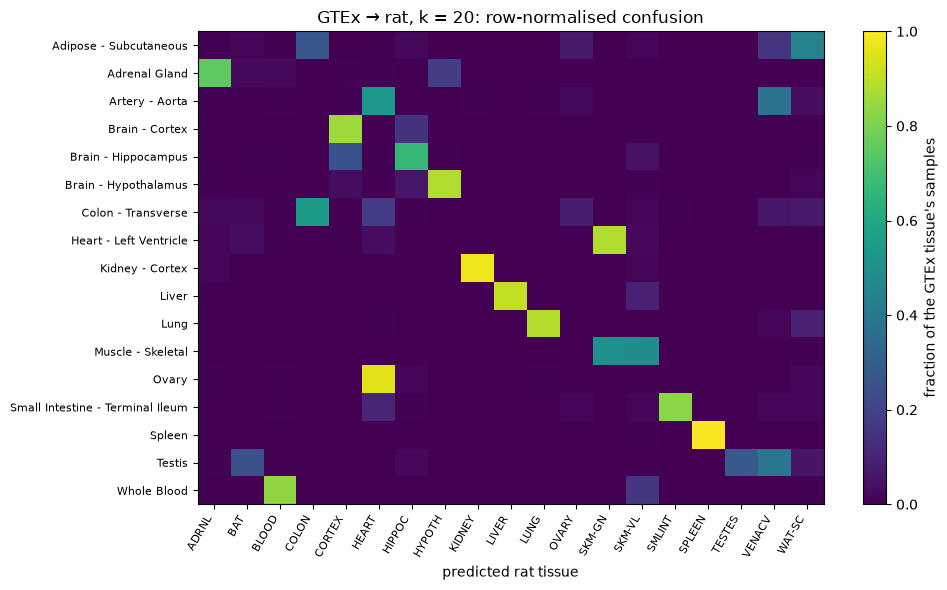

In [32]:
# notebook-only helper (not in the pipeline): presentation of tables the pipeline wrote
def s10_confusion_summary(cf: pd.DataFrame) -> pd.DataFrame:
    """Per GTEx tissue: n, correct (super-class diagonal), accuracy, the main wrong destination and its share."""
    rows = []
    for tissue, r in cf.iterrows():
        ok_cols = [c for c in GTEX_TO_RAT[tissue] if c in cf.columns]
        wrong = r.drop(ok_cols)
        rows.append({"gtex_tissue": tissue, "n": int(r.sum()), "correct": int(r[ok_cols].sum()),
                     "accuracy": r[ok_cols].sum() / r.sum(), "main_wrong_call": wrong.idxmax() if wrong.sum() else "—",
                     "main_wrong_frac": wrong.max() / r.sum()})
    return pd.DataFrame(rows).set_index("gtex_tissue")


s10_cf = {m: s10_t[f"confusion_{m}"].set_index("organ") for m in ("k20", "k50", "full")}
s10_cs = s10_confusion_summary(s10_cf["k20"])
print("k = 20, derived from confusion_k20.csv:")
print(s10_cs.round(2).to_string())
_d = max(float((s10_confusion_summary(s10_cf[m])["accuracy"] - s10_acc[m]).abs().max()) for m in s10_cf)
print("max |confusion-derived − published per-tissue accuracy| over the three models:", _d)
_cfn = s10_cf["k20"].div(s10_cf["k20"].sum(axis=1), axis=0)
_cfn = _cfn.loc[:, (_cfn > 0).any(axis=0)]
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(_cfn.to_numpy(), cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(_cfn.shape[1]), _cfn.columns, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(_cfn.shape[0]), _cfn.index, fontsize=8)
ax.set_xlabel("predicted rat tissue"); ax.set_title("GTEx → rat, k = 20: row-normalised confusion")
fig.colorbar(im, ax=ax, label="fraction of the GTEx tissue's samples")
plt.tight_layout(); plt.show()
record("s10.heart_to_skm_frac_k20", float(s10_cf["k20"].loc["Heart - Left Ventricle", ["SKM-GN", "SKM-VL"]].sum()
                                           / s10_cf["k20"].loc["Heart - Left Ventricle"].sum()), "10")
record("s10.ovary_to_heart_frac_k20", float(s10_cf["k20"].loc["Ovary", "HEART"] / s10_cf["k20"].loc["Ovary"].sum()), "10")

**What this shows.** The fingerprint crosses species unevenly: tissues with a strong, conserved
marker program (kidney, liver, lung, spleen, skeletal muscle) transfer at every panel size, while at
k = 20 some tissues collapse almost entirely into one wrong rat tissue — the `main_wrong_call` column
names where (e.g. the human left ventricle into the rat skeletal-muscle classes, the human ovary into
rat heart). Larger models recover most of these; the full model is the best overall. The
derived-vs-published check confirms the confusion tables and the accuracy table describe the same
predictions.

**What it does not show.** *Why* a tissue collapses. A 20-gene panel has one or two markers per
tissue, so a single marker that is not conserved (or not expressed in the human sample) can move a
whole tissue; the panel-gene check in `results/13_gtex/panel_gene_check.csv` lists which markers fail
in GTEx, but which failure causes which collapse is not tested here. Aorta → VENACV is an
artery-for-vein mapping and its accuracy is not a fair test of either tissue.

### 10.3 Conformal coverage with rat calibration, and recalibration on GTEx donors

As in 9.3: models refit on the MoTrPAC fit animals, calibrated on held-out MoTrPAC animals, sets
formed on every GTEx sample; then the threshold is recalibrated on 3 or 5 GTEx donors (pooled
tissues, 20 draws) and tested on the remaining donors. Every number is printed beside its pre-fix
value.

In [33]:
_key = ["model", "conformal"]
_ct = s10_t["conformal_transfer"].merge(s10_pre["conformal_transfer"], on=["stage"] + _key, suffixes=("", "_prefix"))
s10_cov = _ct[_key + ["coverage_mapped", "coverage_mapped_prefix", "frac_empty_mapped", "frac_empty_mapped_prefix",
                      "avg_set_size_mapped", "avg_set_size_mapped_prefix"]]
print("All GTEx samples, rat calibration, α = 0.10:")
print(s10_cov.round(3).to_string(index=False))
_pt = s10_t["coverage_by_tissue"]
_ptw = _pt[(_pt["model"] == "k20")].pivot(index="gtex_tissue", columns="conformal", values="coverage_rat_cal")
print("\nPer GTEx tissue, k = 20, rat calibration:")
print(_ptw[["marginal", "mondrian", "floored"]].assign(accuracy_k20=s10_acc["k20"]).round(2).to_string())
_rc = s10_t["recalibration"].merge(s10_pre["recalibration"], on=["model", "n_recal"], suffixes=("", "_prefix"))
s10_recal = _rc[["model", "n_recal", "draws", "coverage_recalibrated", "coverage_recalibrated_prefix",
                 "coverage_source_cal_same_test", "coverage_source_cal_same_test_prefix",
                 "set_size_recalibrated", "set_size_recalibrated_prefix", "frac_empty_recalibrated"]]
print("\nRecalibration on GTEx donors:")
print(s10_recal.round(3).to_string(index=False))
_c = s10_cov.set_index(_key)
for m in ("k20", "k50", "full"):
    for v in ("marginal", "mondrian", "floored"):
        record(f"s10.cov_{m}_{v}", _c.loc[(m, v), "coverage_mapped"], "10")
_r = s10_recal.set_index(["model", "n_recal"])
for m in ("k20", "k50", "full"):
    for n in (3, 5):
        record(f"s10.recal_cov_{m}_n{n}", _r.loc[(m, n), "coverage_recalibrated"], "10")
        record(f"s10.recal_size_{m}_n{n}", _r.loc[(m, n), "set_size_recalibrated"], "10")

All GTEx samples, rat calibration, α = 0.10:
model conformal  coverage_mapped  coverage_mapped_prefix  frac_empty_mapped  frac_empty_mapped_prefix  avg_set_size_mapped  avg_set_size_mapped_prefix
  k20  marginal            0.364                   0.368              0.616                     0.611                0.384                       0.389
  k20  mondrian            0.329                   0.208              0.000                     0.650                2.353                       0.353
  k20   floored            0.522                   0.404              0.000                     0.452                2.548                       0.553
  k50  marginal            0.363                   0.368              0.631                     0.627                0.369                       0.373
  k50  mondrian            0.302                   0.181              0.000                     0.784                2.216                       0.216
  k50   floored            0.510                 

Two of the post-fix numbers above need a mechanism check before they are read: the Mondrian / floored
sets are never empty, and recalibration on 3 donors reaches high coverage with very large sets. The
next cell derives both from the script's own seeded draws: (i) which tissues have too few rat
calibration vials for a finite per-tissue threshold (phase 13 uses the same seed and the same
calibration split as phase 12); (ii) for each recalibration draw, how many GTEx samples the chosen
donors contribute, and whether that is enough for a finite textbook threshold, ⌈(n+1)(1 − α)⌉ ≤ n.

In [34]:
# (i) rat calibration animals, as in scripts/13_gtex_transfer.py: rng = default_rng(seed); rng.shuffle(unique pids)
_g = om_trn.groups()
_uniq = np.unique(_g)
_rng = np.random.default_rng(s10_args.seed)
_rng.shuffle(_uniq)
_cal = set(_uniq[:max(1, int(round(s10_args.cal_frac * len(_uniq))))])
_n_cal = om_trn.meta.loc[[a in _cal for a in _g], "tissue"].value_counts()
_inf = sorted(t for t, n in _n_cal.items() if np.ceil((n + 1) * (1 - s10_args.alpha) - 1e-9) > n)
print("rat tissues whose Mondrian threshold is infinite (in every Mondrian / floored set):", _inf,
      {t: int(_n_cal[t]) for t in _inf}, "calibration vials")
# (ii) the recalibration draws of transfer.conformal_transfer, replayed with the same generator (after the shuffle
# above): per model, per n_recal, 20 draws of donors via rng.choice(ids, n, replace=False); every GTEx tissue is
# mapped, so the calibration set is every sample of the chosen donors
_mg = pd.read_csv(C.EXTERNAL_DIR / "gtex_meta.csv", dtype=str)
_per_donor = _mg["donor"].value_counts()
_ids = sorted(_mg["donor"].unique())
_rows = []
for m in ("k20", "k50", "full"):
    for n_recal in (3, 5):
        for _ in range(s10_args.recal_repeats):
            chosen = tuple(_rng.choice(_ids, size=n_recal, replace=False))
            n = int(_per_donor[list(chosen)].sum())
            _rows.append({"model": m, "n_recal": n_recal, "n_cal_samples": n,
                          "threshold_infinite": bool(np.ceil((n + 1) * (1 - s10_args.alpha) - 1e-9) > n)})
s10_draws = pd.DataFrame(_rows)
print(f"\nGTEx samples per donor: median {int(_per_donor.median())}, range {_per_donor.min()}–{_per_donor.max()}")
s10_draw_sum = s10_draws.groupby(["model", "n_recal"]).agg(median_cal_samples=("n_cal_samples", "median"),
                                                           frac_draws_infinite=("threshold_infinite", "mean"))
s10_draw_sum["set_size_recalibrated"] = s10_recal.set_index(["model", "n_recal"])["set_size_recalibrated"]
print(s10_draw_sum.round(3).to_string())
record("s10.frac_recal_draws_infinite_k20_n3", s10_draw_sum.loc[("k20", 3), "frac_draws_infinite"], "10")

rat tissues whose Mondrian threshold is infinite (in every Mondrian / floored set): ['OVARY', 'TESTES'] {'OVARY': 8, 'TESTES': 7} calibration vials

GTEx samples per donor: median 3, range 1–9
               median_cal_samples  frac_draws_infinite  set_size_recalibrated
model n_recal                                                                
full  3                       7.5                 0.55                 11.178
      5                      13.0                 0.05                  2.045
k20   3                       9.0                 0.45                 11.697
      5                      14.5                 0.00                  6.282
k50   3                       8.5                 0.50                 11.624
      5                      16.0                 0.00                  4.036


**What this shows.** Across species the rat-calibrated guarantee fails badly: marginal coverage on
GTEx is far below the 90 % target for every model and lowest for the *full* model, the most accurate
one — the shortfall is empty sets: on human data the classifiers' top probabilities rarely reach the
threshold set on rat animals, so accuracy (argmax) and coverage (thresholded probability) come
apart. Per tissue, coverage can be far below accuracy for tissues the argmax gets right.

The Mondrian and floored rows look better after the fix only through the always-included tissues of
the cell above: GTEx ovary and testis are "covered" by every set (per-tissue table) although the
argmax never or rarely names them, and every other tissue pays with larger sets.

Recalibration on donors: with 3 donors a large fraction of the draws (printed above) contribute too
few samples for a finite threshold, so the set is every tissue and "coverage" is trivial — read the huge set size, not the
coverage. With 5 donors more draws have a finite threshold, and coverage near the target comes with
sets of several tissues for the panels — a weak answer. Before the fix the same small calibration
sets returned their largest score instead of an infinite threshold, which is why the pre-fix
3-donor sets were smaller and their coverage lower.

**What it does not show.** The replayed draws reproduce the calibration *sizes* only; the per-draw
coverage is not recomputed here (that needs the fitted models — `RECOMPUTE = True`). A finite
threshold from so few samples is still a very noisy one.

### 10.4 Native GTEx panel versus the imported rat panels

The ceiling, as in 9.2: a 20-gene panel selected and cross-validated on GTEx itself (donor-grouped
5-fold CV, all 17 tissues, same samples as the imported scores).

In [35]:
_nat = s10_t["native_panel"].iloc[0]
print(pd.Series({"native GTEx k20 (accuracy)": _nat["native_gtex_panel_k20_accuracy"],
                 "native GTEx k20 (balanced accuracy)": _nat["native_panel_balanced_accuracy"],
                 "imported rat k20": _nat["imported_k20_accuracy"], "imported rat k50": _nat["imported_k50_accuracy"],
                 "imported rat full": _nat["imported_full_accuracy"],
                 "gap native − imported k20": _nat["gap_native_minus_imported_k20"]}).round(3).to_string())
record("s10.native_acc", _nat["native_gtex_panel_k20_accuracy"], "10")
_gc = s10_t["panel_gene_check"]
_bad = _gc[(_gc["fails_in_target"] == True) | (_gc["weakened"] == True)]
print(f"\nk = 20 rat panel genes that fail or weaken in GTEx ({len(_bad)} of {len(_gc)}):")
print(_bad[["gene_symbol", "marker_tissue", "source_effect_z", "target_effect_z", "target_top_organ", "fails_in_target",
            "risk_T7_regulated", "risk_qc_correlated"]].round(2).to_string(index=False))

native GTEx k20 (accuracy)             0.979
native GTEx k20 (balanced accuracy)    0.979
imported rat k20                       0.654
imported rat k50                       0.781
imported rat full                      0.855
gap native − imported k20              0.325

k = 20 rat panel genes that fail or weaken in GTEx (10 of 20):
gene_symbol marker_tissue  source_effect_z  target_effect_z       target_top_organ fails_in_target risk_T7_regulated risk_qc_correlated
     Hoxb13         COLON             4.35             1.52     Colon - Transverse           False             False              False
     Trim29        WAT-SC             3.05            -1.50                 Testis            True             False              False
     Ankrd2        SKM-GN             1.61             0.56      Muscle - Skeletal           False             False              False
      Gdf10        VENACV             1.15            -0.89                   Lung            True             False      

**What this shows.** Human tissues are easy to tell apart with human markers — the native panel is
near the top of the scale — so the imported panels' shortfall is a transfer loss, not a hard task. A
large share of the rat panel's markers fail or weaken in GTEx (the count is printed above), several of
them markers the MoTrPAC-side risk flags (training-regulated, correlated with library mRNA fraction)
had already marked.

**What it does not show.** The native panel is a CV estimate on GTEx; the imported number is an
external test — different kinds of number, set side by side as a ceiling, not as a fair contest.

### 10.5 Do scale-free representations transfer better? (phase 14)

Three representations of a k-gene panel: per-gene **z-scores** within each dataset (used above),
within-sample **ranks** of the panel genes, and **top-scoring pairs** (for every pair of panel genes,
which one is higher in the sample). Ranks and pairs do not depend on the gene's scale, so in principle
they should survive a change of units or library protocol. Two selectors: `standard` round robin and
`transfer_aware` (a tissue may not pick a gene that is training-regulated in it, or correlated with the
library mRNA fraction at |r| > 0.5, computed on MoTrPAC only). The cost side is MoTrPAC animal-grouped
CV; the benefit side is the two external targets.

In [36]:
# ---- phase 14: scripts/14_transfer_representations.py, copied (trimmed: argparse, report.add_section and printing
# dropped; `targets` / `gtex_matrix` / `skip_cv` arguments replace --targets / --gtex-matrix / --skip-cv) ----
from sklearn.metrics import balanced_accuracy_score   # the script's own import (phase-14 CV)

# from scripts/14_transfer_representations.py (verbatim): the organ maps and names
BODYMAP_MAP = {"Adrenal": {"ADRNL"}, "Brain": {"CORTEX", "HIPPOC", "HYPOTH"}, "Heart": {"HEART"}, "Kidney": {"KIDNEY"},
               "Liver": {"LIVER"}, "Lung": {"LUNG"}, "Muscle": {"SKM-GN", "SKM-VL"}, "Spleen": {"SPLEEN"},
               "Testes": {"TESTES"}, "Thymus": None, "Uterus": None}
GTEX_MAP = dict(GTEX_TO_RAT)   # identical to phase 13's GTEX_TO_RAT in the script
SELECTORS = ("standard", "transfer_aware")
TARGET_NAMES = {"bodymap": "BodyMap adults", "gtex": "GTEx"}


# from scripts/14_transfer_representations.py::load_bodymap (verbatim; renamed — this is NOT section 9's
# loader: no sex relabelling, group_id built from the raw sex code, returns log2 CPM on the shared genes)
def s10_load_bodymap_p14(shared_with):
    X = pd.read_csv(C.EXTERNAL_DIR / "bodymap_counts.csv", index_col=0)
    X.index = X.index.astype(str)
    meta = pd.read_csv(C.EXTERNAL_DIR / "bodymap_meta.csv", dtype=str).set_index("sample").loc[X.columns]
    meta["stage_weeks"] = meta["stage_weeks"].astype(int)
    meta["replicate_index"] = meta["replicate"].astype(str).str.rsplit("_", n=1).str[-1]
    meta["group_id"] = meta["sex"].astype(str).str[0] + "_" + meta["stage_weeks"].astype(str) + "_" + meta["replicate_index"]
    lb = io.log_cpm(X.T, log=True)
    shared = [g for g in shared_with if g in set(lb.columns)]
    return lb[shared].to_numpy(dtype=float), shared, meta


# from scripts/14_transfer_representations.py::load_gtex (verbatim)
def load_gtex(motrpac_genes, matrix="tpm"):
    """GTEx samples × 1:1-ortholog genes (rat ids), on log2 TPM or log2 CPM; matching as in phase 13."""
    path = C.EXTERNAL_DIR / ("gtex_cpm_subset.csv" if matrix == "cpm" else "gtex_tpm_subset.csv")
    if not path.exists():
        raise SystemExit(f"{path} is missing — run scripts/11_gtex_prepare.py" + (" --reads <gene_reads.gct.gz>" if matrix == "cpm" else ""))
    Xg = pd.read_csv(path, index_col=0)
    mg = pd.read_csv(C.EXTERNAL_DIR / "gtex_meta.csv", dtype=str).set_index("SAMPID").loc[Xg.index]
    mg["organ"] = mg["SMTSD"]
    mg["group_id"] = mg["donor"]
    mg["stage"] = "adult"
    orth = one_to_one_orthologs()
    orth = orth[orth["RAT_ENSEMBL_ID"].isin(motrpac_genes)]
    by, _, _ = match_gtex_orthologs(orth, Xg.columns, gtex_symbols())
    return Xg[by["HUMAN_ORTHOLOG_ENSEMBL_ID"].tolist()].to_numpy(dtype=float), by["RAT_ENSEMBL_ID"].tolist(), mg


def s10_run_phase14(out: Path, targets=("bodymap", "gtex"), gtex_matrix="tpm", skip_cv=False) -> dict:
    args = s10_args
    out.mkdir(parents=True, exist_ok=True)
    grid = [int(k) for k in args.grid.split(",")]
    recal_ns = [3, 5]
    n_splits = args.n_splits
    reps = list(REPRESENTATIONS)
    selectors = list(SELECTORS)
    target_keys = list(targets)
    om = om_trn
    y = om.meta["tissue"].astype(str).to_numpy()
    g = om.groups()
    classes = sorted(np.unique(y))
    sym = io.map_to_gene_symbols(om.X.columns)
    tm = pd.read_csv(C.META_DIR / "TRNSCRPT.csv", dtype=str, low_memory=False).drop_duplicates("viallabel").set_index("viallabel")
    qc = pd.to_numeric(tm["pct_mrna"], errors="coerce").reindex(om.X.index).to_numpy()
    reg = pd.read_csv(C.RAW_DIR / "training_regulated_features.csv", dtype=str, usecols=["feature_ID", "assay", "tissue"])
    reg = reg[reg["assay"] == "TRNSCRPT"]
    reg_map = reg.groupby("tissue")["feature_ID"].agg(set).to_dict()
    all_genes = list(om.X.columns)
    L_all = om.X.to_numpy(dtype=float)
    tables = {}
    if not skip_cv:
        cv_rows = []
        for fold, (tr, te) in enumerate(grouped_kfold(om.meta, "tissue", n_splits, args.seed)):
            assert_no_group_leak(om.meta, tr, te)
            for selector in selectors:
                ex = None if selector == "standard" else exclusion_mask(L_all[tr], y[tr], all_genes, classes, qc=qc[tr], regulated=reg_map, r_thresh=args.r_thresh)
                for rep in reps:
                    pm = PanelModels(L_all[tr], y[tr], all_genes, grid, args.prefilter, representation=rep, exclude=ex, full=False)
                    Lp_te, Zp_te = pm.source_matrices(L_all[te])
                    for k in grid:
                        p, cls = pm.proba(f"k{k}", Lp_te, Zp_te)
                        pred = np.asarray(cls)[p.argmax(axis=1)]
                        cv_rows.append({"selector": selector, "representation": rep, "k": k, "fold": fold,
                                        "balanced_accuracy": balanced_accuracy_score(y[te], pred), "n_test_animals": int(om.meta.iloc[te]["pid"].nunique())})
        tables["motrpac_cv_cost"] = pd.DataFrame(cv_rows)
    tg = {}
    if "bodymap" in target_keys:
        Lb, shared_b, mb = s10_load_bodymap_p14(all_genes)
        tg[TARGET_NAMES["bodymap"]] = (Lb, shared_b, mb, BODYMAP_MAP, "stage_weeks", 21, ["Thymus", "Uterus"])
    if "gtex" in target_keys:
        Lg, rat_g, mg = load_gtex(set(all_genes), gtex_matrix)
        tg[TARGET_NAMES["gtex"]] = (Lg, rat_g, mg, GTEX_MAP, "stage", "adult", [])
    acc_rows, sum_rows, recal_rows = [], [], []
    for tname, (L_tgt, genes_t, mt, omap, stage_col, primary, ood) in tg.items():
        L_src = om.X[genes_t].to_numpy(dtype=float)
        primary_m = (mt[stage_col] == primary).to_numpy()
        uniq = np.unique(g)
        rng_split = np.random.default_rng(args.seed)
        rng_split.shuffle(uniq)
        cal_animals = set(uniq[:max(1, int(round(args.cal_frac * len(uniq))))])
        is_cal = np.array([a in cal_animals for a in g])
        fit_idx, cal_idx = np.flatnonzero(~is_cal), np.flatnonzero(is_cal)
        assert_no_group_leak(om.meta, fit_idx, cal_idx)
        ex_ta_all = exclusion_mask(L_src, y, genes_t, classes, qc=qc, regulated=reg_map, r_thresh=args.r_thresh)
        for selector in selectors:
            ex_all = None if selector == "standard" else ex_ta_all
            ex_fit = None if selector == "standard" else exclusion_mask(L_src[fit_idx], y[fit_idx], genes_t, classes, qc=qc[fit_idx], regulated=reg_map, r_thresh=args.r_thresh)
            for rep in reps:
                pm = PanelModels(L_src, y, genes_t, grid, args.prefilter, representation=rep, exclude=ex_all, full=False)
                Lt_pre, Zt_pre = pm.target_matrices(L_tgt)
                for k in grid:
                    pred, ok, _, _ = score_block(pm, f"k{k}", Lt_pre[primary_m], Zt_pre[primary_m], mt[primary_m], omap)
                    sub = mt[primary_m].assign(correct=ok, pred=pred)
                    for organ, d in sub.groupby("organ"):
                        if not omap.get(organ):
                            continue
                        acc_rows.append({"target": tname, "selector": selector, "representation": rep, "k": k, "organ": organ,
                                         "n": len(d), "accuracy": float(d["correct"].mean()), "top_prediction": d["pred"].value_counts().index[0]})
                    mapped = np.array([bool(omap.get(o)) for o in sub["organ"]])
                    per_organ = [float(d["correct"].mean()) for o, d in sub.groupby("organ") if omap.get(o)]
                    sum_rows.append({"target": tname, "selector": selector, "representation": rep, "k": k,
                                     "accuracy": float(ok[mapped].mean()), "accuracy_macro_over_tissues": float(np.mean(per_organ)),
                                     "n": int(mapped.sum())})
                pm_c = PanelModels(L_src[fit_idx], y[fit_idx], genes_t, grid, args.prefilter, representation=rep, exclude=ex_fit, full=False)
                Lm_c, Zm_c = pm_c.source_matrices(L_src[cal_idx])
                names = [f"k{k}" for k in grid]
                calib = calibrate_models(pm_c, Lm_c, Zm_c, y[cal_idx], pm_c.classes, args.alpha, names)
                Lt_c, Zt_c = pm_c.target_matrices(L_tgt)
                conf_df, _, recal = conformal_transfer(calib, pm_c.classes, Lt_c, Zt_c, mt, omap, args.alpha, stage_col, primary,
                                                       recal_ns, args.recal_repeats, np.random.default_rng(args.seed), names, ood)
                src_cov = conf_df[(conf_df[stage_col] == primary) & (conf_df["conformal"] == "marginal")].set_index("model")
                for _, r in recal.iterrows():
                    recal_rows.append({"target": tname, "selector": selector, "representation": rep, "k": int(r["model"][1:]),
                                       "n_recal": int(r["n_recal"]), "coverage_source_cal": float(src_cov.loc[r["model"], "coverage_mapped"]),
                                       "frac_empty_source_cal": float(src_cov.loc[r["model"], "frac_empty_mapped"]),
                                       "coverage_recalibrated": r["coverage_recalibrated"], "set_size_recalibrated": r["set_size_recalibrated"],
                                       "frac_empty_recalibrated": r["frac_empty_recalibrated"]})
    tables.update({"target_accuracy": pd.DataFrame(acc_rows), "target_summary": pd.DataFrame(sum_rows),
                   "recalibration": pd.DataFrame(recal_rows)})
    for name, t in tables.items():
        t.to_csv(out / f"{name}.csv", index=False)
    return tables

S10_T14 = ["target_accuracy", "target_summary", "recalibration"]
if RECOMPUTE:
    s10_p14 = s10_run_phase14(S10_OUT / "14_transfer")                                    # `make transfer`, first command
    s10_p14cpm = s10_run_phase14(S10_OUT / "14_transfer_cpm", targets=("gtex",), gtex_matrix="cpm", skip_cv=True)  # second
else:
    s10_p14 = {n: pd.read_csv(res("14_transfer", f"{n}.csv")) for n in S10_T14 + ["motrpac_cv_cost"]}
    s10_p14cpm = {n: pd.read_csv(res("14_transfer_cpm", f"{n}.csv")) for n in S10_T14}
    print("phase 14 tables loaded from", RES / "14_transfer", "and", RES / "14_transfer_cpm")
s10_p14_pre = {n: pd.read_csv(PREFIX / "14_transfer" / f"{n}.csv") for n in S10_T14}

# cost: MoTrPAC CV balanced accuracy (mean ± sd over the 5 folds)
_cv = s10_p14["motrpac_cv_cost"].groupby(["representation", "k", "selector"])["balanced_accuracy"].agg(["mean", "std"]).unstack("selector")
print("MoTrPAC animal-grouped CV balanced accuracy (the cost):")
print(_cv.round(3).to_string())
# benefit: accuracy on the external targets (sample-weighted over mapped samples; BodyMap adults; GTEx on log2 TPM)
s10_rep = s10_p14["target_summary"].pivot_table(index=["target", "k", "representation"], columns="selector", values="accuracy")
print("\nTarget accuracy:")
print(s10_rep.round(3).to_string())
_rc14 = s10_p14["recalibration"].merge(s10_p14_pre["recalibration"], on=["target", "selector", "representation", "k", "n_recal"],
                                      suffixes=("", "_prefix"))
_rc14 = _rc14[(_rc14["n_recal"] == 3) & (_rc14["selector"] == "standard")]
print("\nCoverage, standard selector, source-calibrated vs recalibrated on 3 target individuals (with pre-fix values):")
print(_rc14[["target", "k", "representation", "coverage_source_cal", "coverage_source_cal_prefix", "coverage_recalibrated",
             "coverage_recalibrated_prefix", "set_size_recalibrated", "set_size_recalibrated_prefix"]].round(3).to_string(index=False))
for (t, k, r), v in s10_rep["standard"].items():
    if t == "GTEx":
        record(f"s10.p14_gtex_{r}_k{k}_acc", v, "10")
_rcs = _rc14.set_index(["target", "k", "representation"])
for (t, k, r) in _rcs.index:
    tag = "gtex" if t == "GTEx" else "bodymap"
    record(f"s10.p14_{tag}_{r}_k{k}_srccov", _rcs.loc[(t, k, r), "coverage_source_cal"], "10")
    record(f"s10.p14_{tag}_{r}_k{k}_recalcov_n3", _rcs.loc[(t, k, r), "coverage_recalibrated"], "10")

phase 14 tables loaded from <repo>/results/14_transfer and <repo>/results/14_transfer_cpm
MoTrPAC animal-grouped CV balanced accuracy (the cost):
                      mean                     std               
selector          standard transfer_aware standard transfer_aware
representation k                                                 
pairs          20    0.934          0.943    0.011          0.011
               50    0.972          0.981    0.009          0.006
rank           20    0.914          0.947    0.010          0.012
               50    0.968          0.975    0.008          0.016
zscore         20    0.976          0.979    0.011          0.004
               50    0.989          0.988    0.004          0.004

Target accuracy:
selector                          standard  transfer_aware
target         k  representation                          
BodyMap adults 20 pairs              0.941           0.824
                  rank               0.926           0.853
      

**What this shows.** The cost side is small: in MoTrPAC cross-validation every representation and
both selectors are close to one another (the transfer-aware selector even helps the rank panels), so
the choice is decided on the targets. Within species (BodyMap adults) all three representations
transfer, z-scores best at k = 20. Across species z-scores are clearly best, and ranks and pairs fall
far behind at k = 20 — the opposite of the "scale-free transfers better" hope. The transfer-aware
selector does not help the z-score panels on either target. The coverage table repeats the pattern
of 10.3: source-calibrated coverage far below target on GTEx for every representation; recalibrated
coverage on 3 target individuals looks restored, but on GTEx it comes with very large sets, for the
same small-calibration-set reason shown in 10.3 (phase 14 draws its own donors, so the replay above
does not apply draw-for-draw).

**What it does not show.** One seed, one calibration split, five CV folds; the differences between
representations in MoTrPAC CV are of the order of the fold-to-fold spread printed above.

### 10.6 Is the rank / pair failure a units problem? (the CPM test)

On GTEx the scale-free representations do *worse* than z-scores at k = 20, the opposite of the
hope. One obvious suspect is units: GTEx was scored on log2 TPM (length-normalised), MoTrPAC and the
BodyMap are log2 CPM, and ranks *within* a sample are changed by a per-gene length factor while
z-scores within a dataset are not. The pipeline tested it by re-scoring GTEx on log2 CPM computed from
the GTEx read counts (`make transfer`, second command). If units were the cause, rank and pair accuracy
should rise towards z-score accuracy on CPM.

In [37]:
_a = s10_p14["target_summary"]
_a = _a[_a["target"] == "GTEx"]
s10_units = _a.merge(s10_p14cpm["target_summary"], on=["target", "selector", "representation", "k"], suffixes=("_tpm", "_cpm"))
s10_units["cpm_minus_tpm"] = s10_units["accuracy_cpm"] - s10_units["accuracy_tpm"]
print(s10_units[["selector", "representation", "k", "accuracy_tpm", "accuracy_cpm", "cpm_minus_tpm"]].round(3).to_string(index=False))
_std = s10_units[s10_units["selector"] == "standard"]
_rp = _std[_std["representation"].isin(["rank", "pairs"])]
s10_units_mean = float(_rp["cpm_minus_tpm"].mean())
_z = _std[_std["representation"] == "zscore"].set_index("k")["accuracy_cpm"]
s10_gap_cpm = float((_rp.set_index("k")["accuracy_cpm"] - _z).mean())
print(f"\nstandard selector, rank + pairs, mean (CPM − TPM) accuracy: {s10_units_mean:+.4f}")
print(f"standard selector, on CPM, mean (rank/pairs − z-score) accuracy: {s10_gap_cpm:+.3f}")
_ta = s10_p14["target_accuracy"]
_tc = s10_p14cpm["target_accuracy"]
_pt20 = (pd.concat([_ta[_ta["target"] == "GTEx"].assign(units="tpm"), _tc.assign(units="cpm")])
         .query("k == 20 and selector == 'standard'")
         .pivot_table(index="organ", columns=["representation", "units"], values="accuracy"))
print("\nPer GTEx tissue, k = 20, standard selector:")
print(_pt20.round(2).to_string())
record("s10.units_rankpairs_cpm_minus_tpm", s10_units_mean, "10")
record("s10.units_rankpairs_minus_z_on_cpm", s10_gap_cpm, "10")

      selector representation  k  accuracy_tpm  accuracy_cpm  cpm_minus_tpm
      standard         zscore 20         0.654         0.668          0.014
      standard         zscore 50         0.781         0.788          0.006
      standard           rank 20         0.287         0.329          0.043
      standard           rank 50         0.632         0.573         -0.058
      standard          pairs 20         0.285         0.297          0.013
      standard          pairs 50         0.637         0.622         -0.015
transfer_aware         zscore 20         0.641         0.648          0.007
transfer_aware         zscore 50         0.738         0.750          0.012
transfer_aware           rank 20         0.498         0.472         -0.026
transfer_aware           rank 50         0.518         0.532          0.014
transfer_aware          pairs 20         0.479         0.475         -0.004
transfer_aware          pairs 50         0.577         0.573         -0.003

standard se

**What this shows (measured).** Matching the units barely moves rank and pair accuracy on GTEx — the
mean change is printed above, and it is small against the gap between rank/pairs and z-scores, which
remains on the CPM matrix. Units are therefore ruled out as the main cause. Within species (BodyMap
adults) the rank representation does transfer (target-accuracy table in 10.5). The per-tissue table
shows the failure is concentrated: some tissues (kidney, liver, skeletal muscle, ovary) are called
well by ranks, others (adrenal, aorta, brain regions, heart, spleen, testis, blood) almost never.

**What it does not show — the failure is unexplained.** The test rules out one cause (TPM vs CPM
units); it does not identify the actual cause. Candidate explanations — species differences in the
within-sample ordering of the panel genes, differences in library protocol, the 5,000-gene prefilter
being chosen on rat variance — have not been tested here and are not claimed. Note also that the
transfer-aware selector *raises* rank/pair accuracy on GTEx at k = 20 while lowering it at k = 50
(10.5), which no single one of those candidates obviously predicts.

**What this section as a whole does not show.** GTEx donors are post-mortem adults with their own
ischaemic-time and cause-of-death effects; the transfer numbers mix those with the species effect.
Only one GTEx subset (≤ 150 donors per tissue) and one seed for the calibration split were run.

## 11. Multi-omic fusion, the permutation null, and the batch check

**Question.** Does fusing omics (transcriptome + metabolome + proteome) beat the best *single* omic,
(A) for tissue identity and (B) for control vs 8-week-trained animals within one tissue? And when
Task B separates the groups almost perfectly, is that training — or a processing batch?

**Why it matters.** "Fusion helps" is the default expectation of a multi-omic hackathon project. With a
few dozen animals per tissue (counts printed below), 13 model arms and a best-of-13 pick, a
near-perfect AUROC is cheap; the
honest comparator is the *null of the best arm* under shuffled labels, not 0.5. And a perfect
separation proves nothing about training if QC or collection covariates alone also separate the
groups.

**What to look for.** (1) Task A: is every arm at the ceiling, so fusion has no room to help?
(2) Task B: does fusion beat the best single omic by more than one fold sd anywhere, and does the
best arm beat the permutation null's 95th percentile? (3) Batch check: which tissues does the verdict
rule call "unresolvable", and why? (4) The two different SKM-GN covariate-only AUROCs that circulate in the findings —
which row of the table each one is, and which statement each supports.

**Mode.** Fusion is the slowest phase of the pipeline (tuned arms plus a 200-draw permutation null per
tissue), and the covariate-only classifiers carry 100-draw nulls. In the default mode these are
**loaded** from `results/07_fusion/`; the cheap derived steps (best-vs-null table, verdict rule, and
the two SKM-GN covariate classifiers without their null) are recomputed live and compared with the
published files. `RECOMPUTE = True` reruns the copied script logic into `_outputs/s11/`.

In [38]:
section("11 fusion")
# ---- helpers copied from scripts/07_fusion_vs_baselines.py (used by the RECOMPUTE branch) ----
import warnings as _s11_warn
from joblib import Parallel, delayed
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

S11_OUT = OUT / "s11"
S11_OUT.mkdir(parents=True, exist_ok=True)
S11_DURATION_WEEKS = {"1w": 1, "2w": 2, "4w": 4, "8w": 8}


# from scripts/07_fusion_vs_baselines.py::load_block (verbatim)
def load_block(assay: str, tissue: str, pheno, source_trn: str, complete: bool):
    om = io.load_counts(tissue, pheno) if (assay == "TRNSCRPT" and source_trn == "counts") else io.load_norm(assay, tissue, pheno)
    n0, s0 = om.n_features, om.n_samples
    if complete and assay != "TRNSCRPT":
        # samples missing a whole platform / plex block first (else no feature is complete), then complete features
        keep_s = (om.X.isna().mean(axis=1) <= 0.2).to_numpy()
        om = om.subset(keep_s)
        keep = om.X.notna().all(axis=0)
        om = om.select_features(list(om.X.columns[keep.to_numpy()]))
        om.notes.append(f"{assay}/{tissue}: dropped {s0 - om.n_samples} samples missing > 20% of features; "
                        f"{om.n_features}/{n0} features with no missing value in the remaining samples")
    return om


# from scripts/07_fusion_vs_baselines.py::build_blocks (verbatim)
def build_blocks(tissues, assays, pheno, source_trn, complete=True, complete_stage="tissue"):
    """Per-assay matrices indexed by bid, aligned across assays within tissue and stacked across tissues.
    complete_stage='tissue': drop incomplete samples / keep complete features inside each tissue (Task B,
    one tissue). complete_stage='stacked': join features across tissues first, then drop samples missing
    > 20% of the joined features and keep complete features (Task A)."""
    blocks = {a: [] for a in assays}
    metas, notes = [], []
    for t in tissues:
        mats = {a: load_block(a, t, pheno, source_trn, complete and complete_stage == "tissue") for a in assays}
        n_before = {a: m.n_samples for a, m in mats.items()}
        al = io.align_by_animal(mats, key="bid")
        notes.append(f"{t}: {n_before} → {al[assays[0]].n_samples} shared biospecimens; features "
                     + ", ".join(f"{a}={al[a].n_features}" for a in assays)
                     + "; " + "; ".join(n for m in mats.values() for n in m.notes if "dropped" in n))
        for a in assays:
            blocks[a].append(al[a].X)
        metas.append(al[assays[0]].meta)
    out = {}
    for a in assays:
        common = set(blocks[a][0].columns)
        for b in blocks[a][1:]:
            common &= set(b.columns)
        common = [c for c in blocks[a][0].columns if c in common]
        out[a] = pd.concat([b[common] for b in blocks[a]], axis=0)
    meta = pd.concat(metas, axis=0)
    if complete and complete_stage == "stacked":
        keep_s = pd.Series(True, index=meta.index)
        for a in assays:
            if a != "TRNSCRPT":
                keep_s &= (out[a].isna().mean(axis=1) <= 0.2)
        n_drop = int((~keep_s).sum())
        for a in assays:
            out[a] = out[a].loc[keep_s.to_numpy()]
            if a != "TRNSCRPT":
                n0 = out[a].shape[1]
                out[a] = out[a].loc[:, out[a].notna().all(axis=0).to_numpy()]
                notes.append(f"{a}: {out[a].shape[1]}/{n0} joined features with no missing value after dropping "
                             f"{n_drop} samples missing > 20% of the joined features")
        meta = meta.loc[keep_s.to_numpy()]
    return out, meta, notes


# from scripts/07_fusion_vs_baselines.py::with_sex (verbatim)
def with_sex(X: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    return X.assign(sex_male=(meta["sex"].astype(str) == "male").astype(float).to_numpy())


# from scripts/07_fusion_vs_baselines.py::run_task (verbatim)
def run_task(blocks, meta, label, strat_label, n_splits, prefilter, quick, seed, kinds, add_sex=False,
             rf_trees=None, verbose=True):
    assays = list(blocks)
    y = meta[label].astype(str).to_numpy()
    g = meta["pid"].astype(str).to_numpy()
    classes = sorted(np.unique(y))
    Xb = {a: (with_sex(blocks[a], meta) if add_sex else blocks[a]) for a in assays}
    Xs = {a: Xb[a].to_numpy(dtype=float) for a in assays}
    Xf, sizes = models.early_fusion_matrix(Xb)
    Xf = Xf.to_numpy(dtype=float)
    rows = []

    def fit(kind, X, ytr, gtr, fusion=False):
        if fusion:
            pipe = models.make_fusion_pipeline(kind, sizes, seed=seed)
        else:
            pipe = models.make_pipeline(kind, k=None, prefilter=prefilter, seed=seed)
        if rf_trees and kind == "rf":
            pipe.set_params(clf__n_estimators=rf_trees)
        if quick or fusion:
            with _s11_warn.catch_warnings():
                _s11_warn.simplefilter("ignore")
                return pipe.fit(X, ytr)
        return models.fit_tuned(kind, X, ytr, gtr, prefilter=prefilter, quick=quick, seed=seed)

    for fold, (tr, te) in enumerate(grouped_kfold(meta, strat_label, n_splits, seed)):
        assert_no_group_leak(meta, tr, te)
        n_te_animals = int(meta.iloc[te]["pid"].nunique())
        per_block_est = {}
        for a in assays:
            for kind in kinds:
                est = fit(kind, Xs[a][tr], y[tr], g[tr])
                proba = est.predict_proba(Xs[a][te]) if models.has_proba(est) else None
                m = models.classification_metrics(y[te], est.predict(Xs[a][te]), proba, list(est.classes_) if proba is not None else classes)
                rows.append({"fold": fold, "arm": f"single:{a}", "model": kind, "n_test_animals": n_te_animals, **m})
                if kind == "logreg_l2":
                    per_block_est[a] = est
        for kind in kinds:
            pipe = fit(kind, Xf[tr], y[tr], g[tr], fusion=True)
            proba = pipe.predict_proba(Xf[te]) if models.has_proba(pipe) else None
            m = models.classification_metrics(y[te], pipe.predict(Xf[te]), proba, list(pipe.classes_) if proba is not None else classes)
            rows.append({"fold": fold, "arm": "early_fusion", "model": kind, "n_test_animals": n_te_animals, **m})
        if len(per_block_est) == len(assays):
            P, cls = models.late_fusion_proba([per_block_est[a] for a in assays], [Xs[a][te] for a in assays])
            y_pred = np.asarray(cls)[P.argmax(axis=1)]
            m = models.classification_metrics(y[te], y_pred, P, list(cls))
            rows.append({"fold": fold, "arm": "late_fusion", "model": "logreg_l2", "n_test_animals": n_te_animals, **m})
        if verbose:
            last = [r for r in rows if r["fold"] == fold]
            best = max(last, key=lambda r: r["balanced_accuracy"])
            print(f"  fold {fold}: best arm {best['arm']}/{best['model']} bal.acc={best['balanced_accuracy']:.3f}")
    return pd.DataFrame(rows)


# from scripts/07_fusion_vs_baselines.py::summarize (verbatim)
def summarize(per_fold, metric, by=("arm", "model")):
    s = per_fold.groupby(list(by))[metric].agg(["mean", "std"]).reset_index()
    s.columns = list(by) + [f"{metric}_mean", f"{metric}_sd"]
    return s.sort_values(f"{metric}_mean", ascending=False)


# from scripts/07_fusion_vs_baselines.py::permuted_max_auroc (verbatim)
def permuted_max_auroc(blocks, meta, n_splits, prefilter, seed, kinds, perm_seed):
    """One permutation: shuffle group within sex (animal level), rerun all arms quick, return the max mean AUROC."""
    rng = np.random.default_rng(perm_seed)
    m = meta.copy()
    grp = m["group"].astype(str).to_numpy().copy()
    for sx in np.unique(m["sex"]):
        idx = np.flatnonzero((m["sex"] == sx).to_numpy())
        grp[idx] = rng.permutation(grp[idx])
    m["group"] = grp
    m["sex_group"] = m["sex"].astype(str) + "/" + m["group"].astype(str)
    pf = run_task(blocks, m, "group", "sex_group", n_splits, prefilter, True, seed, kinds, add_sex=True, rf_trees=100, verbose=False)
    metric = "auroc" if "auroc" in pf.columns else "balanced_accuracy"
    return float(pf.groupby(["arm", "model"])[metric].mean().max())


# from scripts/07_fusion_vs_baselines.py::batch_balance (verbatim)
def batch_balance(tissue: str, meta_sub: pd.DataFrame) -> dict:
    """Group balance across TMT plex and channel for the animals of a Task B subset (from meta/PROT.csv)."""
    p = C.META_DIR / "PROT.csv"
    out = {"tissue": tissue, "n_control": int((meta_sub["group"] == "control").sum()), "n_8w": int((meta_sub["group"] == "8w").sum())}
    if not p.exists():
        return out
    pm = pd.read_csv(p, dtype=str)
    pm = pm[pm["tissue"] == tissue].drop_duplicates("viallabel")
    pm["bid"] = pm["viallabel"].str[:5]
    j = pm.merge(meta_sub.reset_index()[["bid", "group"]], on="bid", how="inner")
    for col in ("tmt_plex", "tmt11_channel"):
        ct = pd.crosstab(j[col], j["group"])
        n = ct.to_numpy().sum()
        if n == 0 or ct.shape[1] < 2:
            out[f"V_{col}"] = np.nan
            continue
        exp = np.outer(ct.sum(1), ct.sum(0)) / n
        chi2 = ((ct.to_numpy() - exp) ** 2 / exp).sum()
        out[f"V_{col}"] = float(np.sqrt(chi2 / (n * (min(ct.shape) - 1))))
        out[f"n_{col}_levels"] = int(ct.shape[0])
        out[f"max_frac_one_group_in_a_{col}"] = float((ct.max(axis=1) / ct.sum(axis=1)).max())
    return out


# from src/tfp/cli.py::resolve_source (verbatim; cli.py is not pasted into the notebook)
def resolve_source(assay: str, source: str) -> str:
    if source != "auto":
        return source
    if assay == "TRNSCRPT" and any((C.COUNTS_DIR).glob(f"{assay}__*.csv")):
        return "counts"
    return "norm"


# The `make fusion` settings: --models centroid,logreg_l2,rf --durations 1w,2w,4w,8w; script defaults otherwise
S11_ARGS = SimpleNamespace(assays="TRNSCRPT,METAB", assays_b="TRNSCRPT,PROT,METAB", kinds=["centroid", "logreg_l2", "rf"],
                           n_splits=5, prefilter=5000, n_perm=200, perm_jobs=-1, durations=["1w", "2w", "4w", "8w"],
                           primary="8w", seed=C.SEED)
print("fusion helpers defined; settings:", vars(S11_ARGS))

fusion helpers defined; settings: {'assays': 'TRNSCRPT,METAB', 'assays_b': 'TRNSCRPT,PROT,METAB', 'kinds': ['centroid', 'logreg_l2', 'rf'], 'n_splits': 5, 'prefilter': 5000, 'n_perm': 200, 'perm_jobs': -1, 'durations': ['1w', '2w', '4w', '8w'], 'primary': '8w', 'seed': 20260925}


In [39]:
# ---- Task A: tissue identity on the tissues that have both TRNSCRPT and METAB (PROT excluded on purpose) ----
if RECOMPUTE:
    # from scripts/07_fusion_vs_baselines.py::main, Task A block (trimmed: report text dropped, output → OUT/s11)
    _files = io.list_sample_files("norm")
    _assays = S11_ARGS.assays.split(",")
    _tissues = sorted(set.intersection(*[set(_files[_files["assay"] == a]["tissue"]) for a in _assays]))
    _blocks, _meta, _notes = build_blocks(_tissues, _assays, cached("pheno", io.load_pheno), resolve_source("TRNSCRPT", "auto"),
                                          complete=True, complete_stage="stacked")
    s11_pfA = run_task(_blocks, _meta, "tissue", "tissue", S11_ARGS.n_splits, S11_ARGS.prefilter, False, S11_ARGS.seed, S11_ARGS.kinds)
    s11_pfA.to_csv(S11_OUT / "taskA_per_fold.csv", index=False)
    s11_taskA = summarize(s11_pfA, "balanced_accuracy")
    s11_taskA.to_csv(S11_OUT / "taskA_summary.csv", index=False)
else:
    s11_pfA = pd.read_csv(res("07_fusion", "taskA_per_fold.csv"))
    s11_taskA = pd.read_csv(res("07_fusion", "taskA_summary.csv"))

# n animals per test fold (evaluation rule: report it next to the mean)
print("Task A test animals per fold:", s11_pfA.groupby("fold")["n_test_animals"].first().tolist())
print(s11_taskA.to_string(index=False, float_format="%.4f"))
_single = s11_taskA[s11_taskA["arm"].str.startswith("single:")]["balanced_accuracy_mean"].max()
_fusion = s11_taskA[~s11_taskA["arm"].str.startswith("single:")]["balanced_accuracy_mean"].max()
print(f"\nbest single-omic arm {_single:.4f}  vs  best fusion arm {_fusion:.4f};  lowest arm {s11_taskA['balanced_accuracy_mean'].min():.4f}")
record("s11.taskA_best_single", _single, "11")
record("s11.taskA_best_fusion", _fusion, "11")
record("s11.taskA_min_arm", s11_taskA["balanced_accuracy_mean"].min(), "11")

Task A test animals per fold: [10, 10, 10, 10, 10]
            arm     model  balanced_accuracy_mean  balanced_accuracy_sd
   single:METAB  centroid                  1.0000                0.0000
   single:METAB logreg_l2                  1.0000                0.0000
   single:METAB        rf                  1.0000                0.0000
   early_fusion  centroid                  0.9989                0.0025
   early_fusion        rf                  0.9989                0.0025
    late_fusion logreg_l2                  0.9989                0.0025
single:TRNSCRPT        rf                  0.9989                0.0025
single:TRNSCRPT logreg_l2                  0.9978                0.0030
   early_fusion logreg_l2                  0.9954                0.0044
single:TRNSCRPT  centroid                  0.9932                0.0061

best single-omic arm 1.0000  vs  best fusion arm 0.9989;  lowest arm 0.9932


**What Task A shows.** Every arm — single omic or fused, any model — sits at or within a hair of
perfect balanced accuracy, and a single omic (METAB) is already at the top. Tissue identity is a
ceiling task here: fusion has nothing left to add.

**What it does not show.** That fusion is useless in general. A ceiling task cannot rank methods;
it only says that tissue identity is not the place to demonstrate fusion.

In [40]:
# ---- Task B: control vs 8w within each fusion tissue; per-arm AUROC and the best-of-13-arms permutation null ----
if RECOMPUTE:
    # from scripts/07_fusion_vs_baselines.py::main, Task B block (trimmed: --time-one-tissue branch and report text dropped)
    _pheno = cached("pheno", io.load_pheno)
    _files = io.list_sample_files("norm")
    _assays_b = S11_ARGS.assays_b.split(",")
    _tissues = sorted(set.intersection(*[set(_files[_files["assay"] == a]["tissue"]) for a in _assays_b]))
    _rowsB, _nulls, _balance, _rows_dur = [], [], [], []
    for t in _tissues:
        blocks_t, meta_t, notes_t = build_blocks([t], _assays_b, _pheno, resolve_source("TRNSCRPT", "auto"), complete=True)
        for dur in S11_ARGS.durations:
            m = meta_t["group"].isin(["control", dur]).to_numpy()
            sub_blocks = {a: b.loc[m] for a, b in blocks_t.items()}
            sub_meta = meta_t.loc[m].copy()
            sub_meta["sex_group"] = sub_meta["sex"].astype(str) + "/" + sub_meta["group"].astype(str)
            if sub_meta["pid"].nunique() < 12 or sub_meta["group"].nunique() < 2:
                continue
            n_splits_b = min(4, sub_meta["pid"].nunique() // 3)
            pf = run_task(sub_blocks, sub_meta, "group", "sex_group", n_splits_b, min(S11_ARGS.prefilter, 2000), False,
                          S11_ARGS.seed, S11_ARGS.kinds, add_sex=True, verbose=False)
            pf["tissue"], pf["duration"], pf["n_animals"] = t, dur, int(sub_meta["pid"].nunique())
            _rows_dur.append(pf)
            if dur != S11_ARGS.primary:
                continue
            _rowsB.append(pf)
            _balance.append(batch_balance(t, sub_meta))
            null = Parallel(n_jobs=S11_ARGS.perm_jobs)(
                delayed(permuted_max_auroc)(sub_blocks, sub_meta, n_splits_b, min(S11_ARGS.prefilter, 2000), S11_ARGS.seed,
                                            S11_ARGS.kinds, S11_ARGS.seed + 100 * i) for i in range(S11_ARGS.n_perm))
            _nulls.append(pd.DataFrame({"tissue": t, "perm": range(len(null)), "max_auroc": null}))
            print(f"  {t}: tuned arms + {len(null)} permutations done")
    _pfD = pd.concat(_rows_dur, ignore_index=True)
    _pfD.to_csv(S11_OUT / "taskB_by_duration.csv", index=False)
    _sD = _pfD.groupby(["tissue", "duration", "arm", "model"]).agg(auroc_mean=("auroc", "mean"), auroc_sd=("auroc", "std"),
                                                                    n_animals=("n_animals", "first")).reset_index()
    _drows = []
    for (t, dur), st in _sD.groupby(["tissue", "duration"]):
        single = st[st["arm"].str.startswith("single:")].sort_values("auroc_mean", ascending=False)
        _drows.append({"tissue": t, "duration": dur, "weeks": S11_DURATION_WEEKS.get(dur, np.nan), "n_animals": int(st["n_animals"].iloc[0]),
                       "best_single_arm": f"{single.iloc[0]['arm']}/{single.iloc[0]['model']}",
                       "best_single_auroc": single.iloc[0]["auroc_mean"], "best_single_sd": single.iloc[0]["auroc_sd"]})
    s11_dur = pd.DataFrame(_drows).sort_values(["tissue", "weeks"])
    s11_dur.to_csv(S11_OUT / "taskB_duration_summary.csv", index=False)
    _pfB = pd.concat(_rowsB, ignore_index=True)
    _pfB.to_csv(S11_OUT / "taskB_per_fold.csv", index=False)
    s11_sB = _pfB.groupby(["tissue", "arm", "model"])["auroc"].agg(["mean", "std"]).reset_index()
    s11_sB.columns = ["tissue", "arm", "model", "auroc_mean", "auroc_sd"]
    s11_sB.to_csv(S11_OUT / "taskB_summary.csv", index=False)
    s11_null = pd.concat(_nulls, ignore_index=True)
    s11_null.to_csv(S11_OUT / "taskB_null.csv", index=False)
    s11_bal = pd.DataFrame(_balance)
    s11_bal.to_csv(S11_OUT / "taskB_batch_balance.csv", index=False)
else:
    s11_sB = pd.read_csv(res("07_fusion", "taskB_summary.csv"))
    s11_null = pd.read_csv(res("07_fusion", "taskB_null.csv"))
    s11_bal = pd.read_csv(res("07_fusion", "taskB_batch_balance.csv"))
    s11_dur = pd.read_csv(res("07_fusion", "taskB_duration_summary.csv"))
print("Task B arms per tissue:", s11_sB.groupby("tissue").size().to_dict(),
      "| permutation draws per tissue:", s11_null.groupby("tissue").size().to_dict())

Task B arms per tissue: {'CORTEX': 13, 'HEART': 13, 'KIDNEY': 13, 'LIVER': 13, 'LUNG': 13, 'SKM-GN': 13, 'WAT-SC': 13} | permutation draws per tissue: {'CORTEX': 200, 'HEART': 200, 'KIDNEY': 200, 'LIVER': 200, 'LUNG': 200, 'SKM-GN': 200, 'WAT-SC': 200}


In [41]:
# ---- best arm vs best single vs best fusion, and vs the null — recomputed live from the summary + null tables ----
# from scripts/07_fusion_vs_baselines.py::main, the best-vs-null loop (verbatim, metric = "auroc")
metric = "auroc"
_rows = []
for t, st in s11_sB.groupby("tissue"):
    best = st.sort_values(f"{metric}_mean", ascending=False).iloc[0]
    single = st[st["arm"].str.startswith("single:")].sort_values(f"{metric}_mean", ascending=False).iloc[0]
    fus = st[~st["arm"].str.startswith("single:")].sort_values(f"{metric}_mean", ascending=False).iloc[0]
    q = s11_null.loc[s11_null["tissue"] == t, "max_auroc"]
    _rows.append({"tissue": t, "best_arm": f"{best['arm']}/{best['model']}", "best_auroc": best[f"{metric}_mean"],
                  "best_sd": best[f"{metric}_sd"], "best_single": f"{single['arm']}/{single['model']}",
                  "single_auroc": single[f"{metric}_mean"], "single_sd": single[f"{metric}_sd"],
                  "best_fusion": f"{fus['arm']}/{fus['model']}", "fusion_auroc": fus[f"{metric}_mean"],
                  "fusion_minus_single": fus[f"{metric}_mean"] - single[f"{metric}_mean"],
                  "fusion_beats_single_by_gt_sd": bool(fus[f"{metric}_mean"] - single[f"{metric}_mean"] > single[f"{metric}_sd"]),
                  "null_median_max_auroc": float(q.median()) if len(q) else np.nan,
                  "null_p95_max_auroc": float(q.quantile(0.95)) if len(q) else np.nan,
                  "p_perm": float((np.sum(q >= best[f"{metric}_mean"]) + 1) / (len(q) + 1)) if len(q) else np.nan,
                  "best_beats_null_p95": bool(len(q) and best[f"{metric}_mean"] > q.quantile(0.95))})
s11_bv = pd.DataFrame(_rows)
_cols = ["tissue", "best_arm", "best_auroc", "single_auroc", "single_sd", "fusion_auroc", "fusion_minus_single",
         "null_median_max_auroc", "null_p95_max_auroc", "p_perm", "fusion_beats_single_by_gt_sd", "best_beats_null_p95"]
print(s11_bv[_cols].to_string(index=False, float_format="%.3f"))
# recomputed vs published (default mode: the same inputs, so this checks the copied logic, not the models)
_pub = pd.read_csv(res("07_fusion", "taskB_best_vs_null.csv"))
_num = ["best_auroc", "fusion_auroc", "null_p95_max_auroc", "p_perm"]
print("\nmax |recomputed − published| over", _num, ":",
      float((s11_bv.set_index("tissue")[_num] - _pub.set_index("tissue")[_num]).abs().max().max()))
_nf, _nn = int(s11_bv["fusion_beats_single_by_gt_sd"].sum()), int(s11_bv["best_beats_null_p95"].sum())
print(f"fusion beats best single by > 1 sd: {_nf} of {len(s11_bv)} tissues (published {int(_pub['fusion_beats_single_by_gt_sd'].sum())})")
print(f"best arm beats the null's 95th percentile: {_nn} of {len(s11_bv)} tissues (published {int(_pub['best_beats_null_p95'].sum())})")
print(f"null 95th percentile of the best-of-arms AUROC, range over tissues: "
      f"{s11_bv['null_p95_max_auroc'].min():.3f}–{s11_bv['null_p95_max_auroc'].max():.3f}")
record("s11.taskB_n_fusion_beats_single", _nf, "11")
record("s11.taskB_n_beats_null", _nn, "11")
record("s11.taskB_null_p95_max", s11_bv["null_p95_max_auroc"].max(), "11")

tissue               best_arm  best_auroc  single_auroc  single_sd  fusion_auroc  fusion_minus_single  null_median_max_auroc  null_p95_max_auroc  p_perm  fusion_beats_single_by_gt_sd  best_beats_null_p95
CORTEX   single:PROT/centroid       1.000         1.000      0.000         0.938               -0.062                  0.729               0.896   0.020                         False                 True
 HEART early_fusion/logreg_l2       1.000         1.000      0.000         1.000                0.000                  0.688               0.875   0.005                         False                 True
KIDNEY  late_fusion/logreg_l2       1.000         1.000      0.000         1.000                0.000                  0.667               0.875   0.005                         False                 True
 LIVER early_fusion/logreg_l2       1.000         1.000      0.000         1.000                0.000                  0.708               0.876   0.005                         False  

In [42]:
# ---- Task B by training duration (best single-omic AUROC): a training effect should grow with duration, a batch should not ----
_wide = s11_dur.pivot(index="tissue", columns="duration", values="best_single_auroc")
_wide = _wide[[d for d in sorted(S11_DURATION_WEEKS, key=S11_DURATION_WEEKS.get) if d in _wide.columns]]
print("best single-omic AUROC, control vs each duration (animal-grouped CV):")
print(_wide.to_string(float_format="%.3f"))
print("\nmean over tissues:", _wide.mean().round(3).to_dict())
# TMT plex / channel balance of the Task B animals (Cramér's V of group vs plex or channel; near 1 = confounded)
print("\nTMT plex/channel balance (Cramér's V, group vs batch):")
print(s11_bal[[c for c in s11_bal.columns if c in ("tissue", "n_control", "n_8w", "V_tmt_plex", "V_tmt11_channel")]]
      .to_string(index=False, float_format="%.2f"))

best single-omic AUROC, control vs each duration (animal-grouped CV):
duration    1w    2w    4w    8w
tissue                          
CORTEX   0.958 0.958 0.833 1.000
HEART    1.000 1.000 1.000 1.000
KIDNEY   1.000 1.000 0.833 1.000
LIVER    1.000 1.000 0.958 1.000
LUNG     0.958 1.000 1.000 1.000
SKM-GN   1.000 1.000 1.000 1.000
WAT-SC   0.833 1.000 0.958 0.958

mean over tissues: {'1w': 0.964, '2w': 0.994, '4w': 0.94, '8w': 0.994}

TMT plex/channel balance (Cramér's V, group vs batch):
tissue  n_control  n_8w  V_tmt_plex  V_tmt11_channel
CORTEX          9    10        0.22             0.61
 HEART         10    10        0.18             0.66
KIDNEY         10    10        0.18             0.55
 LIVER         10    10        0.18             0.66
  LUNG         10    10        0.18             0.59
SKM-GN          8     9        0.46             0.68
WAT-SC         10    10        0.26             0.73


**What Task B shows.** In every fusion tissue the best arm separates control from 8-week animals
almost perfectly and beats the 95th percentile of the best-of-arms permutation null — but in no tissue
does fusion beat the best single omic by more than that omic's fold sd. So: there is a real group
difference, and one omic already captures it. The duration table shows the separation is already high
after one week of training, so the duration series cannot, by itself, tell a fast training response
from a batch (and by design only the 8-week animals share their collection dates with the controls).

**What it does not show.** That the separation is *training*. The permutation null tests "is there any
difference between the two groups", not "what caused it". That is what the batch check below is for.
Note also that the null used the untuned (quick) arms with 100-tree forests, a cheaper version of
the observed arms; the pipeline states this in its report.

In [43]:
# ---- batch check: helpers copied from scripts/07_batch_check.py ----
FUSION_TISSUES = ["CORTEX", "HEART", "KIDNEY", "LIVER", "LUNG", "SKM-GN", "WAT-SC"]
# from scripts/07_batch_check.py (verbatim constants)
DROP = {"pid", "bid", "labelid", "viallabel", "vial_label", "2D_barcode", "BID", "PID", "Tissue", "Species", "Sample_category",
        "Phase", "biclabeldata.barcode", "registration.ratid", "tissue", "tissue_code_no", "tissue_description",
        "specimen.processing.sampletypedescription", "specimen.processing.aliquotdescription", "group", "sex", "assay"}
CATEGORY_RULES = [  # (regex on the column name, category); first match wins; None = dropped (administrative)
    (r"comments$|formname|versionnbr|visitcode", None),
    (r"^(key\.(anirandgroup|sacrificetime|intervention|protocol|agegroup)|study_group_timepoint|sacrificetime|intervention|biclabeldata\.protocol)$", "design"),
    (r"^training\.|^vo2\.max\.test\.|^calculated\.variables\.(vo2_max_change|pct_body_(fat|lean|fluid)_change|lactate_change_dueto_train)|^nmr\.testing\..*_2$|^terminal\.weight\.", "outcome"),
    (r"^familiarization\.|^nmr\.testing\..*_1$|^registration\.(weight|d_birth|days_birth)$", "baseline"),
    (r"^key\.(d_arrive|d_sacrifice|siteid)$|^registration\.|^specimen\.collection\.|^specimen\.processing\.|^calculated\.variables\.(coll_time_train|deathtime_after_train|frozetime_after_train)$|^time_to_freeze$|^biclabeldata\.", "collection"),
    (r"^(GET_site|RNA_extr_|RIN$|r_260_|Lib_|Seq_)", "library"),
    (r"^(reads_raw|reads|uniquely_mapped|num_.*splices)$", "depth"),   # library depth: pooling / loading, a pure processing batch
    (r"^(pct_|avg_|median_5_3_bias)", "qc"),                             # composition and quality fractions: batch or biology
    (r"^tmt", "processing"),
]
BATCH_CATEGORIES = ("collection", "library", "depth", "qc", "processing")


# from scripts/07_batch_check.py::categorize (verbatim)
def categorize(col: str) -> str | None:
    if col in DROP:
        return None
    for pat, cat in CATEGORY_RULES:
        if re.search(pat, col):
            return cat
    return "other"


# from scripts/07_batch_check.py::parse_series (verbatim)
def parse_series(v: pd.Series):
    """→ (kind, values): numeric (float), time (hours), datetime (days since 2018-01-01) or categorical (string)."""
    s = v.astype("string").str.strip()
    s = s.where(s.str.len() > 0)
    n_ok = int(s.notna().sum())
    if n_ok == 0:
        return "empty", s
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().sum() >= 0.9 * n_ok:
        return "numeric", num.astype(float)
    if s.dropna().str.fullmatch(r"\d{1,2}:\d{2}(:\d{2})?").all():
        td = pd.to_timedelta(s.where(s.str.count(":") == 2, s + ":00"), errors="coerce")
        return "time", td.dt.total_seconds() / 3600.0
    for fmt in ("%d%b%Y", "%m/%d/%Y", "%Y-%m-%d", "%b %Y"):
        dt = pd.to_datetime(s, format=fmt, errors="coerce")
        if dt.notna().sum() >= 0.9 * n_ok:
            return "datetime", (dt - pd.Timestamp("2018-01-01")).dt.days.astype(float)
    return "categorical", s


# from scripts/07_batch_check.py::cramers_v (verbatim)
def cramers_v(ct: pd.DataFrame) -> tuple[float, float]:
    ct = ct.loc[ct.sum(axis=1) > 0, ct.sum(axis=0) > 0]
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan, np.nan
    n = ct.to_numpy().sum()
    if ct.shape == (2, 2):
        p = stats.fisher_exact(ct.to_numpy())[1]
        chi2 = stats.chi2_contingency(ct.to_numpy(), correction=False)[0]
    else:
        chi2, p = stats.chi2_contingency(ct.to_numpy(), correction=False)[:2]
    return float(np.sqrt(chi2 / (n * (min(ct.shape) - 1)))), float(p)


# from scripts/07_batch_check.py::screen (verbatim)
def screen(table: pd.DataFrame, y: np.ndarray, source: str, level: dict, tissue: str) -> list[dict]:
    rows = []
    pos = y == 1
    for col in table.columns:
        cat = categorize(col)
        if cat is None:
            continue
        kind, vals = parse_series(table[col])
        miss_c, miss_t = float(vals[~pos].isna().mean()), float(vals[pos].isna().mean())
        row = {"tissue": tissue, "variable": col, "source": source, "category": cat, "level": level.get(col, "animal"), "kind": kind,
               "n_control": int((~pos).sum()), "n_trained": int(pos.sum()), "frac_missing_control": miss_c, "frac_missing_trained": miss_t,
               "missing_in_one_group_only": bool((miss_c >= 0.8 and miss_t <= 0.2) or (miss_t >= 0.8 and miss_c <= 0.2)),
               "n_levels": int(vals.dropna().nunique()), "stat": None, "separation": np.nan, "p_value": np.nan}
        if kind == "empty" or row["n_levels"] < 2:
            rows.append(row)
            continue
        if kind in ("numeric", "time", "datetime"):
            a, b = vals[pos].dropna().to_numpy(float), vals[~pos].dropna().to_numpy(float)
            if len(a) >= 2 and len(b) >= 2:
                u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
                auc = u / (len(a) * len(b))
                row.update({"stat": "auroc", "separation": float(max(auc, 1 - auc)), "p_value": float(p), "auroc_trained_higher": float(auc)})
        else:
            ct = pd.crosstab(vals, pd.Series(np.where(pos, "trained", "control"), index=vals.index))
            v, p = cramers_v(ct)
            row.update({"stat": "cramers_v", "separation": v, "p_value": p})
        rows.append(row)
    return rows


# from scripts/07_batch_check.py::covariate_frame (verbatim)
def covariate_frame(table: pd.DataFrame, cols: list[str]) -> tuple[pd.DataFrame, list[str], list[str]]:
    num, cat = {}, {}
    for c in cols:
        kind, vals = parse_series(table[c])
        if kind == "empty" or vals.dropna().nunique() < 2:
            continue
        if kind == "categorical":
            if vals.dropna().nunique() >= 0.9 * vals.notna().sum():   # identifier-like (unique per sample): no batch structure to learn
                continue
            cat[c] = vals.astype(object).where(vals.notna(), "missing")
        else:
            num[c] = vals.astype(float)
    X = pd.DataFrame({**num, **cat}, index=table.index)
    return X, list(num), list(cat)


# from scripts/07_batch_check.py::covariate_auroc (verbatim)
def covariate_auroc(X: pd.DataFrame, num_cols, cat_cols, y, meta, n_splits, seed, model, n_perm=0, rng=None):
    pre = ColumnTransformer([("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])
    clf = (LogisticRegression(C=0.1, max_iter=3000) if model == "logreg"
           else RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=seed, n_jobs=-1))
    pipe = Pipeline([("pre", pre), ("clf", clf)])
    folds = list(grouped_kfold(meta, "sex_group", n_splits, seed))

    def cv_auc(yy):
        aucs = []
        for tr, te in folds:
            assert_no_group_leak(meta, tr, te)
            if len(np.unique(yy[te])) < 2 or len(np.unique(yy[tr])) < 2:
                continue
            with _s11_warn.catch_warnings():
                _s11_warn.simplefilter("ignore")
                pipe.fit(X.iloc[tr], yy[tr])
                aucs.append(roc_auc_score(yy[te], pipe.predict_proba(X.iloc[te])[:, 1]))
        return aucs
    aucs = cv_auc(y)
    out = {"auroc_mean": float(np.mean(aucs)), "auroc_sd": float(np.std(aucs)), "n_folds": len(aucs)}
    if n_perm:
        sex = meta["sex"].to_numpy()
        null = []
        for _ in range(n_perm):
            yp = y.copy()
            for sx in np.unique(sex):
                idx = np.flatnonzero(sex == sx)
                yp[idx] = rng.permutation(yp[idx])
            null.append(float(np.mean(cv_auc(yp))))
        out["null_p95_auroc"] = float(np.quantile(null, 0.95))
        out["p_perm"] = float((np.sum(np.asarray(null) >= out["auroc_mean"]) + 1) / (len(null) + 1))
    return out


# from scripts/07_batch_check.py::main, the per-tissue table construction (restructured: the loop body up to the
# covariate frames is a function here, so the live SKM-GN check below and the RECOMPUTE branch share it)
def batch_tables(t, ph, tm, pmeta, trained_group="8w"):
    d = ph[(ph["tissue"] == t) & ph["viallabel"].isin(tm["viallabel"])].drop_duplicates("pid").copy()   # the animal's TRNSCRPT vial
    vials = tm[tm["viallabel"].isin(d["viallabel"])]
    if d["pid"].nunique() < 12 or d["group"].nunique() < 2:
        return None
    d = d.set_index("pid")
    y = (d["group"] == trained_group).astype(int).to_numpy()
    meta = pd.DataFrame({"pid": d.index, "sex": d["sex"].to_numpy(), "group": d["group"].to_numpy()}, index=d.index)
    meta["sex_group"] = meta["sex"] + "/" + meta["group"]
    n_splits = min(4, len(d) // 3)
    tv = vials.set_index("viallabel").reindex(d["viallabel"]).set_axis(d.index).copy()
    if "Lib_barcode_well" in tv.columns:   # plate position as two numbers (processing order is a classic batch axis)
        w = tv["Lib_barcode_well"].astype("string").str.upper().str.extract(r"^([A-H])(\d{1,2})$")
        tv["Lib_barcode_well_row"] = w[0].map({c: i + 1 for i, c in enumerate("ABCDEFGH")}).astype("string")
        tv["Lib_barcode_well_col"] = w[1]
    pheno_cols = [c for c in ph.columns if categorize(c)]
    trn_cols_t = [c for c in tv.columns if categorize(c)]
    tables = {"pheno_collection": (d, [c for c in pheno_cols if categorize(c) == "collection"]),
              "trnscrpt_library": (tv, [c for c in trn_cols_t if categorize(c) == "library"]),
              "trnscrpt_depth": (tv, [c for c in trn_cols_t if categorize(c) == "depth"]),
              "trnscrpt_qc": (tv, [c for c in trn_cols_t if categorize(c) == "qc"])}
    if pmeta is not None:
        pv = pmeta[(pmeta["tissue"] == t) & pmeta["viallabel"].astype(str).str.fullmatch(r"\d{11}")].drop_duplicates("viallabel").copy()
        pv["bid"] = pv["viallabel"].str[:5]
        pv = pv.drop_duplicates("bid").set_index("bid").reindex(d["bid"]).set_axis(d.index)[["tmt_plex", "tmt11_channel"]]
        tables["prot_plex_channel"] = (pv, ["tmt_plex", "tmt11_channel"])
    frames = {fs: covariate_frame(tab, cols) for fs, (tab, cols) in tables.items()}
    X_all = pd.concat([f[0] for f in frames.values()], axis=1)
    frames["all_batch_covariates"] = (X_all, sum((f[1] for f in frames.values()), []), sum((f[2] for f in frames.values()), []))
    return SimpleNamespace(d=d, y=y, meta=meta, n_splits=n_splits, tv=tv, trn_cols_t=trn_cols_t, pheno_cols=pheno_cols,
                           tables=tables, frames=frames)


# the batch-check inputs (read-only): pheno.csv (control + 8w rows), transcript library meta, proteomics plex meta
s11_ph = pd.read_csv(C.RAW_DIR / "pheno.csv", dtype=str, low_memory=False)
s11_ph = s11_ph[s11_ph["group"].isin(["control", "8w"])]
s11_tm = pd.read_csv(C.META_DIR / "TRNSCRPT.csv", dtype=str, low_memory=False).drop_duplicates("viallabel")
s11_pm = pd.read_csv(C.META_DIR / "PROT.csv", dtype=str) if (C.META_DIR / "PROT.csv").exists() else None
print("batch-check inputs:", len(s11_ph), "control/8w pheno rows;", len(s11_tm), "TRNSCRPT library-meta vials")

batch-check inputs: 2430 control/8w pheno rows; 899 TRNSCRPT library-meta vials


In [44]:
# ---- (b) covariate-only classifiers and (c) the univariate screen: loaded (100-draw nulls), or recomputed ----
if RECOMPUTE:
    # from scripts/07_batch_check.py::main (trimmed: the markdown report and the duration read-out dropped; output → OUT/s11)
    _rng = np.random.default_rng(C.SEED)
    _animal_level = {c: ("animal" if s11_ph.groupby("pid")[c].nunique(dropna=True).max() <= 1 else "vial") for c in s11_ph.columns}
    _auc_rows, _screen_rows = [], []
    for t in FUSION_TISSUES:
        bt = batch_tables(t, s11_ph, s11_tm, s11_pm)
        if bt is None:
            continue
        for fs, (X, num, cat) in bt.frames.items():
            if X.shape[1] == 0:
                continue
            for model in ("logreg", "rf"):
                r = covariate_auroc(X, num, cat, bt.y, bt.meta, bt.n_splits, C.SEED, model,
                                    n_perm=100 if model == "logreg" else 0, rng=_rng)
                _auc_rows.append({"tissue": t, "feature_set": fs, "model": model, "n_animals": int(len(bt.d)), "n_features": int(X.shape[1]),
                                  "n_numeric": len(num), "n_categorical": len(cat), **r})
        _screen_rows += screen(bt.d[bt.pheno_cols], bt.y, "PHENO", _animal_level, t)
        _screen_rows += screen(bt.tv[bt.trn_cols_t], bt.y, "meta/TRNSCRPT", {c: "vial" for c in bt.trn_cols_t}, t)
        if s11_pm is not None:
            _screen_rows += screen(bt.tables["prot_plex_channel"][0], bt.y, "meta/PROT", {"tmt_plex": "vial", "tmt11_channel": "vial"}, t)
    s11_auc = pd.DataFrame(_auc_rows)
    s11_auc.to_csv(S11_OUT / "batch_covariate_auroc.csv", index=False)
    s11_sc = pd.DataFrame(_screen_rows)
    s11_sc.to_csv(S11_OUT / "batch_variable_screen.csv", index=False)
else:
    s11_auc = pd.read_csv(res("07_fusion", "batch_covariate_auroc.csv"))
    s11_sc = pd.read_csv(res("07_fusion", "batch_variable_screen.csv"), low_memory=False)

# "separates" flag, recomputed from the screen's statistics (script defaults --sep-auroc 0.9 --sep-v 0.8, p < 0.01)
_sep = s11_sc["missing_in_one_group_only"].astype(bool) | (((s11_sc["stat"] == "auroc") & (s11_sc["separation"] >= 0.9)
                                                             | (s11_sc["stat"] == "cramers_v") & (s11_sc["separation"] >= 0.8)) & (s11_sc["p_value"] < 0.01))
if "separates" in s11_sc.columns:
    print("recomputed 'separates' flag equals the published one:", bool((_sep == s11_sc["separates"].astype(bool)).all()))
s11_sc["separates"] = _sep
print(f"{len(s11_auc)} covariate-classifier rows ({s11_auc['tissue'].nunique()} tissues × feature sets × 2 models); "
      f"{len(s11_sc)} screened tissue × variable rows")

recomputed 'separates' flag equals the published one: True
84 covariate-classifier rows (7 tissues × feature sets × 2 models); 3605 screened tissue × variable rows


In [45]:
# ---- (d) the verdict rule, recomputed live from the two tables ----
# from scripts/07_batch_check.py::main, the per-tissue verdict loop (verbatim)
PURE = ("pheno_collection", "trnscrpt_library", "trnscrpt_depth", "prot_plex_channel")
auc, sc = s11_auc, s11_sc
verdict_rows = []
for t in auc["tissue"].unique():
    a_t = auc[auc["tissue"] == t]
    pure_max = float(a_t[a_t["feature_set"].isin(PURE)]["auroc_mean"].max())
    qc_max = float(a_t[a_t["feature_set"] == "trnscrpt_qc"]["auroc_mean"].max()) if (a_t["feature_set"] == "trnscrpt_qc").any() else np.nan
    sb_t = sc[(sc["tissue"] == t) & sc["separates"] & sc["category"].isin(("collection", "library", "depth", "processing"))]
    sq_t = sc[(sc["tissue"] == t) & sc["separates"] & (sc["category"] == "qc")]
    pure_set = a_t[a_t["feature_set"].isin(PURE)].sort_values("auroc_mean", ascending=False).iloc[0]["feature_set"]
    if pure_max >= 0.8 or len(sb_t):
        verdict = ("unresolvable: sequencing depth separates the groups" if set(sb_t["category"]) <= {"depth"} and len(sb_t)
                   else f"unresolvable: {pure_set} covariates classify the groups (AUROC {pure_max:.2f})")
    elif (not np.isnan(qc_max) and qc_max >= 0.8) or len(sq_t):
        verdict = "unresolvable: library QC metrics separate the groups (a within-plate batch or a training effect on RNA composition)"
    else:
        verdict = "training"
    verdict_rows.append({"tissue": t, "max_auroc_collection_library_plex": pure_max, "max_auroc_qc_metrics": qc_max,
                         "max_auroc_all_covariates": float(a_t[a_t["feature_set"] == "all_batch_covariates"]["auroc_mean"].max()),
                         "null_p95_logreg_max": float(a_t["null_p95_auroc"].max()) if "null_p95_auroc" in a_t else np.nan,
                         "batch_variables_separating": ";".join(sb_t["variable"]), "qc_variables_separating": ";".join(sq_t["variable"]),
                         "verdict": verdict})
s11_vt = pd.DataFrame(verdict_rows)
print(s11_vt[["tissue", "max_auroc_collection_library_plex", "max_auroc_qc_metrics", "max_auroc_all_covariates", "verdict"]]
      .to_string(index=False, float_format="%.3f"))
_pubv = pd.read_csv(res("07_fusion", "batch_conclusion.csv"))
print("\nverdicts equal to published batch_conclusion.csv:",
      bool((s11_vt.set_index("tissue")["verdict"] == _pubv.set_index("tissue")["verdict"]).all()))
print("published overall verdict:", _pubv["overall_verdict"].iloc[0])
_n_unres = int((s11_vt["verdict"] != "training").sum())
print(f"unresolvable tissues: {_n_unres} of {len(s11_vt)}")
record("s11.batch_n_unresolvable", _n_unres, "11")
del auc, sc, metric  # generic names from the verbatim loops; keep s11_auc / s11_sc / s11_vt

tissue  max_auroc_collection_library_plex  max_auroc_qc_metrics  max_auroc_all_covariates                                                                    verdict
CORTEX                              0.740                 0.354                     0.438                                                                   training
 HEART                              0.958                 0.792                     0.875                        unresolvable: sequencing depth separates the groups
KIDNEY                              0.885                 0.688                     0.792 unresolvable: trnscrpt_library covariates classify the groups (AUROC 0.89)
 LIVER                              0.677                 0.698                     0.552                                                                   training
  LUNG                              0.667                 0.500                     0.500                                                                   training
SKM-GN    

In [46]:
# ---- SKM-GN: "0.917" vs "0.958" — both are real rows of batch_covariate_auroc.csv ----
_sk = s11_auc[(s11_auc["tissue"] == "SKM-GN") & s11_auc["feature_set"].isin(["trnscrpt_depth", "trnscrpt_qc"])]
print(_sk[["tissue", "feature_set", "model", "n_features", "auroc_mean", "auroc_sd", "null_p95_auroc", "p_perm"]]
      .to_string(index=False, float_format="%.4f"))
_depth_rf = _sk.query("feature_set == 'trnscrpt_depth' and model == 'rf'").iloc[0]
_qc_lr = _sk.query("feature_set == 'trnscrpt_qc' and model == 'logreg'").iloc[0]
_qc_rf = _sk.query("feature_set == 'trnscrpt_qc' and model == 'rf'").iloc[0]
_vsk = s11_vt.set_index("tissue").loc["SKM-GN"]
print(f"\n(1) sequencing-depth covariates, RF: AUROC {_depth_rf['auroc_mean']:.3f} = the verdict rule's max over the 'pure' "
      f"(collection/library/depth/plex) sets for SKM-GN: {_vsk['max_auroc_collection_library_plex']:.3f}; its own null: "
      f"{'none (RF rows have no permutation null)' if pd.isna(_depth_rf['p_perm']) else _depth_rf['p_perm']}")
print(f"(2) library-QC fractions: logreg {_qc_lr['auroc_mean']:.3f}, RF {_qc_rf['auroc_mean']:.3f}; logreg permutation "
      f"p = {_qc_lr['p_perm']:.3f} (null 95th pct {_qc_lr['null_p95_auroc']:.3f})")
_dl = _sk.query("feature_set == 'trnscrpt_depth' and model == 'logreg'").iloc[0]
print(f"    for comparison, depth covariates with logreg: {_dl['auroc_mean']:.3f}, p = {_dl['p_perm']:.3f}")
_other = s11_auc[(s11_auc["tissue"] == "SKM-GN") & (s11_auc["p_perm"] <= 0.05)]
print("    SKM-GN logreg rows with p_perm ≤ 0.05:", [(r.feature_set, round(r.auroc_mean, 3), round(r.p_perm, 4)) for r in _other.itertuples()])
record("s11.skmgn_depth_rf", _depth_rf["auroc_mean"], "11")
record("s11.skmgn_qc_logreg", _qc_lr["auroc_mean"], "11")
record("s11.skmgn_qc_logreg_p", _qc_lr["p_perm"], "11")

# Live recompute of those three classifiers (no permutation null: the null's RNG stream runs through every
# tissue and set in order, so a single row's null cannot be replayed on its own).
_bt = batch_tables("SKM-GN", s11_ph, s11_tm, s11_pm)
for fs, model, pub in (("trnscrpt_depth", "rf", _depth_rf), ("trnscrpt_qc", "logreg", _qc_lr), ("trnscrpt_qc", "rf", _qc_rf)):
    X, num, cat = _bt.frames[fs]
    r = covariate_auroc(X, num, cat, _bt.y, _bt.meta, _bt.n_splits, C.SEED, model)
    print(f"  live {fs:15s} {model:6s}: AUROC {r['auroc_mean']:.4f}  (published {pub['auroc_mean']:.4f}); "
          f"{X.shape[1]} covariates, {len(_bt.d)} animals, {r['n_folds']} folds")
    record(f"s11.skmgn_{fs.split('_')[1]}_{model}_live", r["auroc_mean"], "11")
for _n in ("X", "num", "cat", "r", "fs", "model", "pub", "t", "m", "q", "best", "single", "fus", "verdict", "verdict_rows"):
    globals().pop(_n, None)   # generic loop names from the verbatim code

tissue    feature_set  model  n_features  auroc_mean  auroc_sd  null_p95_auroc  p_perm
SKM-GN trnscrpt_depth logreg           9      0.6771    0.3957          0.8333  0.1782
SKM-GN trnscrpt_depth     rf           9      0.9167    0.1443             NaN     NaN
SKM-GN    trnscrpt_qc logreg          26      0.9583    0.0722          0.8056  0.0099
SKM-GN    trnscrpt_qc     rf          26      0.9583    0.0722             NaN     NaN

(1) sequencing-depth covariates, RF: AUROC 0.917 = the verdict rule's max over the 'pure' (collection/library/depth/plex) sets for SKM-GN: 0.917; its own null: none (RF rows have no permutation null)
(2) library-QC fractions: logreg 0.958, RF 0.958; logreg permutation p = 0.010 (null 95th pct 0.806)
    for comparison, depth covariates with logreg: 0.677, p = 0.178
    SKM-GN logreg rows with p_perm ≤ 0.05: [('trnscrpt_qc', 0.958, 0.0099), ('all_batch_covariates', 0.958, 0.0099)]


  live trnscrpt_depth  rf    : AUROC 0.9167  (published 0.9167); 9 covariates, 20 animals, 4 folds
  live trnscrpt_qc     logreg: AUROC 0.9583  (published 0.9583); 26 covariates, 20 animals, 4 folds


  live trnscrpt_qc     rf    : AUROC 0.9583  (published 0.9583); 26 covariates, 20 animals, 4 folds


**What the batch check shows.** The verdict rule, rerun here on the loaded tables, reproduces the
published verdicts: several tissues are "unresolvable" — their control-vs-8w separation cannot be
attributed to training on these data — and the rest are attributed to training (or to anything else
that differs by design between the arms, such as daily handling).

**The two SKM-GN numbers.** Both are real rows of `batch_covariate_auroc.csv`, and they support different statements:
- **The lower number** (row 1 of the printout) is the *sequencing-depth* covariates (`trnscrpt_depth`: raw, mapped and splice-junction
  read counts) with a **random forest**. It is the maximum over the "pure" batch sets (collection,
  library, depth, TMT plex) — the number the verdict rule uses — so it supports *"in SKM-GN a pure
  processing covariate set classifies control vs trained, so the verdict is unresolvable"*. It has no
  permutation null of its own (the script runs nulls for the logistic model only), and the logistic
  model on the same depth covariates is not significant — so read it as a flag, not as a test.
- **The higher number** (row 2) is the *library-QC fractions* (`trnscrpt_qc`: mapping, mRNA, intronic, mitochondrial
  fractions, …) with **both** logistic regression and random forest. The logistic row has its own
  within-sex permutation null, and it clears it (the p-value printed above). It supports *"library
  composition differs between control and trained muscle, beyond chance"*. The all-covariates
  logistic row clears its null too, but it contains the QC set. Whether a composition difference is
  batch or biology (a higher mitochondrial read fraction is what training-induced mitochondrial
  biogenesis would produce) cannot be told from these data.

**What it does not show.** That the other tissues are free of batch: "training" here means "no
*recorded* covariate separates the groups", at the small per-tissue n printed above, where the logistic nulls'
95th percentiles are themselves high (the table above). Unrecorded batches are not tested.

## 12. Transcript–protein discordance

**Question.** In the seven tissues with both RNA-seq and proteomics, how often do the two layers
disagree about a gene's training response — opposite signs, or significant in one layer only — and
can simple gene covariates predict which genes disagree?

**Why it matters.** Track 2 is about RNA–protein discordance. Before building on it, one needs to know
what "discordance" mostly *is* in these data. If nearly every discordant gene is "significant in one
layer, not significant in the other", that is at least partly a statement about statistical power,
not about biology. And a predictor of discordance is only interesting if it does not use information
that already defines the label.

**What to look for.** (1) The per-gene RNA–protein correlation across animals, and how much the TMT
channel (which encodes sex in HEART and LIVER) moves it. (2) The three counts over all
tissue × sex × time-point contrasts at FDR 0.10: gene × contrast pairs significant in either layer,
significant in one layer only, and significant in both with opposite signs. (3) The AUROC for
predicting "one-layer-only" genes **with and without the circular covariate** `is_training_regulated`
— the consortium's training-regulated flag, derived from the same differential-analysis tables that
define "significant in one layer" (the script's own caveat).

**Mode.** Correlations, DA counts and the discordance-prediction AUROCs are recomputed live in both modes;
per-gene tables go to `_outputs/s12/`. Only the per-covariate drop-one importances (a refit per covariate per
fold, most of this phase's run time) are loaded from `results/09_discordance/` unless `RECOMPUTE = True`;
the AUROCs themselves are the same fits either way.

In [47]:
section("12 discordance")
# from scripts/09_discordance.py::main (trimmed: argparse, rho histograms and report.add_section dropped; output → OUT/s12;
# defaults --assay-a TRNSCRPT --assay-b PROT --fdr 0.1, complete protein features; `make discordance` passes no flags)


# [notebook workaround] src/tfp/discordance.py::ptm_site_counts has a function-local relative import
# (`from .io import read_sample_table`) that the builder does not strip (it strips only top-level ones), so the
# pasted version raises ImportError here. Below: the same function, verbatim, minus that one line
# (read_sample_table is already defined bare in this namespace). Noted as a build.py fix.
def _s12_ptm_site_counts(tissue: str, assay: str, f2g=None, raw_dir=None) -> pd.Series:
    """Number of quantified PTM sites per gene in this tissue (0 when the assay has no table here)."""
    p = (raw_dir or C.RAW_DIR) / "norm" / f"{assay}__{C.tissue_token(tissue)}.csv"
    if not p.exists():
        return pd.Series(dtype=float, name=f"n_{assay.lower()}_sites")
    feat, _ = read_sample_table(p)
    acc = pd.Series([str(f).rsplit("_", 1)[0] for f in feat.index])
    genes = map_to_gene_symbols(acc.unique(), f2g, raw_dir)
    g = acc.map(genes.to_dict())
    return g.dropna().value_counts().rename(f"n_{assay.lower()}_sites")


import inspect as _s12_inspect
D = discordance
if "from .io import" in _s12_inspect.getsource(discordance.ptm_site_counts):
    D = SimpleNamespace(**{**vars(discordance), "ptm_site_counts": _s12_ptm_site_counts})
S12_OUT = OUT / "s12"
S12_OUT.mkdir(parents=True, exist_ok=True)
_A, _B, _FDR, _complete_b, _seed = "TRNSCRPT", "PROT", 0.1, True, C.SEED
pheno = cached("pheno", io.load_pheno)
f2g = io.load_feature_to_gene()
files = io.list_sample_files("norm")
tissues = sorted(set(files[files["assay"] == _A]["tissue"]) & set(files[files["assay"] == _B]["tissue"]))
da_files = {C.tissue_from_token(p.stem.split("__")[1]) for p in C.DA_DIR.glob(f"{_B}__*.csv")} if C.DA_DIR.exists() else set()
ptm_tissues = {a: set(files[files["assay"] == a]["tissue"]) for a in ("PHOSPHO", "ACETYL", "UBIQ")}
try:
    reg = pd.read_csv(C.RAW_DIR / "training_regulated_features.csv", dtype=str)
    regulated = set(io.map_to_gene_symbols(reg["feature_ID"], f2g).dropna())
except Exception:
    regulated = None
chan = D.channel_map(_B)

summary, rates, aucs, imps, chan_rows = [], [], [], [], []
s12_rho = {}
for t in tissues:
    A, B, meta = D.paired_layers(t, _A, _B, pheno, f2g, complete_b=_complete_b)
    corr = D.per_gene_correlation(A, B)
    row = {"tissue": t, "n_animals": len(meta), "n_genes": len(corr), "median_rho": corr["rho"].median(),
           "frac_rho_gt_0.3": float((corr["rho"] > 0.3).mean()), "frac_rho_lt_0": float((corr["rho"] < 0).mean())}
    # channel residualization (unsupervised) → ρ after
    if chan is not None:
        A2, B2, _ = D.paired_layers(t, _A, _B, pheno, f2g, complete_b=_complete_b, residualize_b=chan)
        corr2 = D.per_gene_correlation(A2, B2).rename(columns={"rho": "rho_after_channel"})
        cc = corr.merge(corr2[["gene", "rho_after_channel"]], on="gene")
        cc.to_csv(S12_OUT / f"per_gene_rho_{C.tissue_token(t)}.csv", index=False)
        chan_rows.append({"tissue": t, "median_rho_before": cc["rho"].median(), "median_rho_after": cc["rho_after_channel"].median(),
                          "frac_rho_lt_0_before": float((cc["rho"] < 0).mean()), "frac_rho_lt_0_after": float((cc["rho_after_channel"] < 0).mean()),
                          "frac_genes_sign_flip": float((np.sign(cc["rho"]) != np.sign(cc["rho_after_channel"])).mean())})
        row["median_rho_after_channel"] = cc["rho_after_channel"].median()
        row["frac_rho_lt_0_after_channel"] = float((cc["rho_after_channel"] < 0).mean())
    s12_rho[t] = corr["rho"].to_numpy()
    ptm = {}
    for a in ("PHOSPHO", "ACETYL", "UBIQ"):
        if t in ptm_tissues[a]:
            ptm[f"n_{a.lower()}_sites"] = D.ptm_site_counts(t, a, f2g)
    feat = D.discordance_features(A, B, corr, regulated, ptm)
    if t in da_files:
        dd = D.da_discordance(t, _A, _B, _FDR, f2g)
        dd.to_csv(S12_OUT / f"da_discordance_{C.tissue_token(t)}.csv", index=False)
        r = dd.groupby(["sex", "comparison_group"]).agg(
            n_genes=("gene", "size"), n_sig_either=("sig_a", lambda s: int((s | dd.loc[s.index, "sig_b"]).sum())),
            n_concordant=("concordant", "sum"), n_sign_discordant=("discordant_sign", "sum"),
            n_one_layer_only=("discordant_sig", "sum")).reset_index()
        r["tissue"] = t
        rates.append(r)
        gene_flag = dd.groupby("gene").agg(any_sign_discordant=("discordant_sign", "any"),
                                            any_one_layer=("discordant_sig", "any")).reset_index()
        feat = feat.merge(gene_flag, on="gene", how="left")
        feat["any_sign_discordant"] = feat["any_sign_discordant"].fillna(False).astype(int)
        feat["any_one_layer"] = feat["any_one_layer"].fillna(False).astype(int)
        fcols = [c for c in ("mean_a", "var_a", "mean_b", "var_b", "prot_abundance_rank", "rho", "is_training_regulated")
                 if c in feat.columns] + list(ptm)
        for target in ("any_sign_discordant", "any_one_layer"):
            # the training-regulated flag is derived from the same DA tables that define the target
            # ('significant in one layer'), so it is reported with and without that flag
            for tag, cols in (("", fcols), (" (no regulated flag)", [c for c in fcols if c != "is_training_regulated"])):
                # [notebook] importance only when RECOMPUTE (same folds and fits; importance adds drop-one refits)
                if RECOMPUTE:
                    res_, imp = D.predict_discordance(feat, target, cols, seed=_seed, importance=True)
                else:
                    res_, imp = D.predict_discordance(feat, target, cols, seed=_seed, importance=False), []
                res_["tissue"], res_["target"] = t, target + tag
                aucs.append(res_)
                if len(imp):
                    imp["tissue"], imp["target"] = t, target + tag
                    imps.append(imp)
        row["frac_genes_any_sign_discordant"] = float(feat["any_sign_discordant"].mean())
        row["frac_genes_any_one_layer"] = float(feat["any_one_layer"].mean())
    feat["rho_low"] = (feat["rho"] < 0.1).astype(int)
    res_ = D.predict_discordance(feat, "rho_low", [c for c in ("mean_a", "var_a", "mean_b", "var_b", "prot_abundance_rank",
                                                                "is_training_regulated") if c in feat.columns] + list(ptm), seed=_seed)
    res_["tissue"], res_["target"] = t, "rho_low(<0.1)"
    aucs.append(res_)
    summary.append(row)
    print(f"  {t}: {len(corr)} genes, {len(meta)} animals, median rho={row['median_rho']:.2f}"
          + (f" → {row['median_rho_after_channel']:.2f} after channel" if "median_rho_after_channel" in row else ""))
s12_summ = pd.DataFrame(summary)
s12_rates = pd.concat(rates, ignore_index=True)
s12_au = pd.concat(aucs, ignore_index=True)
s12_imp = (pd.concat(imps, ignore_index=True) if RECOMPUTE and imps
           else pd.read_csv(res("09_discordance", "covariate_importance.csv")))   # default mode: loaded
for _n, _df in (("summary", s12_summ), ("discordance_rates", s12_rates), ("prediction_auroc", s12_au), ("covariate_importance", s12_imp)):
    _df.to_csv(S12_OUT / f"{_n}.csv", index=False)
# keep the namespace clean: the verbatim loop used generic names (the library alias stays `discordance`;
# note `res_` above — the script's `res` would have shadowed the notebook's res() helper)
for _n in ("D", "f2g", "files", "tissues", "da_files", "ptm_tissues", "reg", "regulated", "chan", "summary", "rates",
           "aucs", "imps", "chan_rows", "t", "A", "B", "meta", "corr", "A2", "B2", "corr2", "cc", "row", "ptm", "a", "feat", "dd",
           "r", "gene_flag", "fcols", "target", "tag", "cols", "imp", "res_"):
    globals().pop(_n, None)

  CORTEX: 8820 genes, 50 animals, median rho=0.03 → 0.03 after channel


  HEART: 5708 genes, 50 animals, median rho=0.11 → 0.05 after channel


  KIDNEY: 7981 genes, 50 animals, median rho=0.13 → 0.14 after channel


  LIVER: 6479 genes, 49 animals, median rho=0.19 → 0.08 after channel


  LUNG: 8846 genes, 50 animals, median rho=0.06 → 0.06 after channel


  SKM-GN: 4317 genes, 47 animals, median rho=0.10 → 0.08 after channel


  WAT-SC: 7773 genes, 50 animals, median rho=0.37 → 0.37 after channel


tissue  n_animals  n_genes  median_rho  median_rho_after_channel  frac_rho_lt_0  frac_rho_gt_0.3
CORTEX         50     8820       0.030                     0.026          0.427            0.041
 HEART         50     5708       0.112                     0.047          0.298            0.219
KIDNEY         50     7981       0.132                     0.141          0.289            0.278
 LIVER         49     6479       0.192                     0.081          0.258            0.382
  LUNG         50     8846       0.063                     0.062          0.361            0.115
SKM-GN         47     4317       0.095                     0.082          0.302            0.145
WAT-SC         50     7773       0.372                     0.369          0.175            0.566

recomputed vs published summary.csv, max |difference|: {'median_rho': 0.0, 'median_rho_after_channel': 0.0, 'n_genes': 0.0}


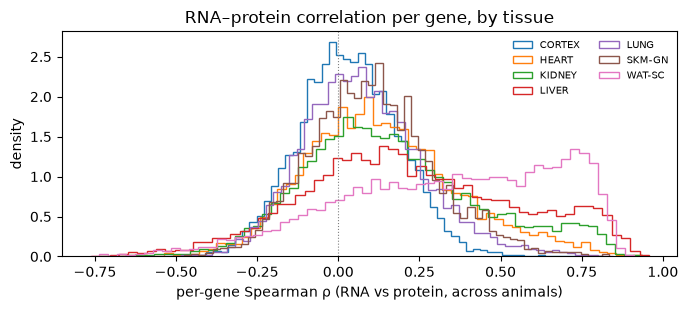

In [48]:
# ---- (1) per-gene RNA–protein Spearman ρ across animals, before and after removing the TMT channel means ----
_pub = pd.read_csv(res("09_discordance", "summary.csv"))
_cols = ["tissue", "n_animals", "n_genes", "median_rho", "median_rho_after_channel", "frac_rho_lt_0", "frac_rho_gt_0.3"]
print(s12_summ[_cols].to_string(index=False, float_format="%.3f"))
_d = (s12_summ.set_index("tissue")[["median_rho", "median_rho_after_channel", "n_genes"]]
      - _pub.set_index("tissue")[["median_rho", "median_rho_after_channel", "n_genes"]]).abs().max()
print("\nrecomputed vs published summary.csv, max |difference|:", _d.round(12).to_dict())
fig, ax = plt.subplots(figsize=(7, 3.2))
for t, r in s12_rho.items():
    ax.hist(r, bins=60, histtype="step", density=True, label=t)
ax.axvline(0, color="grey", lw=0.8, ls=":")
ax.set_xlabel("per-gene Spearman ρ (RNA vs protein, across animals)")
ax.set_ylabel("density")
ax.legend(fontsize=7, ncol=2, frameon=False)
ax.set_title("RNA–protein correlation per gene, by tissue")
fig.tight_layout()
plt.show()
record("s12.median_rho_WATSC", s12_summ.set_index("tissue").loc["WAT-SC", "median_rho"], "12")
record("s12.median_rho_CORTEX", s12_summ.set_index("tissue").loc["CORTEX", "median_rho"], "12")

**What (1) shows.** Across animals, the RNA and protein levels of a gene are only weakly correlated
in most tissues (median ρ near zero in CORTEX, highest in WAT-SC), with a large fraction of negative
correlations. Removing the TMT channel means moves ρ materially only in HEART and LIVER — the two
tissues where the channel encodes sex, so there the "correction" also removes a real biological
(sex) source of concordance. Read those two tissues separately.

In [49]:
# ---- (2) DA-based discordance: every tissue × sex × time-point contrast at FDR 0.10, pooled ----
_tot = s12_rates[["n_sig_either", "n_concordant", "n_sign_discordant", "n_one_layer_only"]].sum()
_pubr = pd.read_csv(res("09_discordance", "discordance_rates.csv"))
_pubt = _pubr[["n_sig_either", "n_concordant", "n_sign_discordant", "n_one_layer_only"]].sum()
print(f"contrasts: {len(s12_rates)} (tissue × sex × time point), genes per tissue {s12_rates['n_genes'].min()}–{s12_rates['n_genes'].max()}")
print(pd.DataFrame({"recomputed": _tot, "published": _pubt}).to_string())
print(f"\none-layer-only share of pairs significant in either layer: {_tot['n_one_layer_only'] / _tot['n_sig_either']:.3f}")
_sd = s12_rates[s12_rates["n_sign_discordant"] > 0][["tissue", "sex", "comparison_group", "n_sig_either", "n_concordant", "n_sign_discordant"]]
print("contrasts holding the sign-discordant pairs:\n" + _sd.to_string(index=False))
print(f"pairs from 8-week contrasts: {int(s12_rates.loc[s12_rates['comparison_group'] == '8w', 'n_sig_either'].sum())} of {int(_tot['n_sig_either'])}")
record("s12.n_sig_either", _tot["n_sig_either"], "12")
record("s12.n_one_layer_only", _tot["n_one_layer_only"], "12")
record("s12.n_sign_discordant", _tot["n_sign_discordant"], "12")
record("s12.n_concordant", _tot["n_concordant"], "12")

contrasts: 56 (tissue × sex × time point), genes per tissue 5413–9825
                   recomputed  published
n_sig_either             1948       1948
n_concordant               45         45
n_sign_discordant           4          4
n_one_layer_only         1899       1899

one-layer-only share of pairs significant in either layer: 0.975
contrasts holding the sign-discordant pairs:
tissue  sex comparison_group  n_sig_either  n_concordant  n_sign_discordant
 HEART male               8w           233            17                  2
 LIVER male               8w           158             5                  2
pairs from 8-week contrasts: 1062 of 1948


**What (2) shows.** These are the three counts quoted in the findings: gene × contrast pairs
significant in RNA or protein; of those, the ones significant in one layer only; and the ones
significant in both with opposite signs. Nearly all "discordance" is one-layer-only significance;
opposite-sign pairs are a handful, all in male 8-week HEART and LIVER — the channel = sex tissues —
where the denominators are too small to carry a rate.

**What it does not show.** That one-layer-only genes are biologically discordant. With few animals
per contrast, "significant in one layer, not in the other" is what two noisy tests of the same true
effect produce routinely; the findings read it as mostly statistical power (an interpretation, not a
measurement). The counts also inherit the consortium's DA thresholds and the c1.0 release.

In [50]:
# ---- (3) can gene covariates predict "one-layer-only" genes? With and without the circular flag ----
# gene-grouped 5-fold CV inside each tissue (library function discordance.predict_discordance); pooled like SUMMARY.md
_pubau = pd.read_csv(res("09_discordance", "prediction_auroc.csv"))
_agg = lambda a: a.groupby(["target", "model"])["auroc"].agg(["mean", "std", "count"])
s12_auc_tab = _agg(s12_au).join(_agg(_pubau)[["mean"]].rename(columns={"mean": "published_mean"}))
print(s12_auc_tab.to_string(float_format="%.3f"))
_w = s12_auc_tab.loc[("any_one_layer", "logreg"), "mean"]
_wo = s12_auc_tab.loc[("any_one_layer (no regulated flag)", "logreg"), "mean"]
print(f"\nlogreg AUROC, any_one_layer: with is_training_regulated {_w:.3f}  →  without it {_wo:.3f}  (drop {_w - _wo:.3f})")
_rw = s12_auc_tab.loc[("any_one_layer", "rf"), "mean"]
_rwo = s12_auc_tab.loc[("any_one_layer (no regulated flag)", "rf"), "mean"]
print(f"rf     AUROC, any_one_layer: with {_rw:.3f}  →  without {_rwo:.3f}")
# which covariates carry the signal (mean drop-one ΔAUROC of the logistic model over tissues and folds)
# (importances: recomputed when RECOMPUTE, else loaded from results/09_discordance/covariate_importance.csv)
_top = (s12_imp.groupby(["target", "covariate"])["logreg_drop_one_dAUROC"].mean().reset_index()
        .sort_values(["target", "logreg_drop_one_dAUROC"], ascending=[True, False]).groupby("target").head(3))
print("\ntop covariates by drop-one ΔAUROC (logreg):\n" + _top.to_string(index=False, float_format="%+.3f"))
record("s12.auroc_one_layer_logreg_with_flag", _w, "12")
record("s12.auroc_one_layer_logreg_without_flag", _wo, "12")
record("s12.auroc_one_layer_rf_with_flag", _rw, "12")
record("s12.auroc_one_layer_rf_without_flag", _rwo, "12")

                                                mean   std  count  published_mean
target                                  model                                    
any_one_layer                           logreg 0.780 0.058     35           0.780
                                        rf     0.775 0.077     35           0.775
any_one_layer (no regulated flag)       logreg 0.742 0.078     35           0.742
                                        rf     0.747 0.093     35           0.747
any_sign_discordant                     n/a      NaN   NaN      0             NaN
any_sign_discordant (no regulated flag) n/a      NaN   NaN      0             NaN
rho_low(<0.1)                           logreg 0.601 0.036     35           0.601
                                        rf     0.643 0.046     35           0.643

logreg AUROC, any_one_layer: with is_training_regulated 0.780  →  without it 0.742  (drop 0.038)
rf     AUROC, any_one_layer: with 0.775  →  without 0.747

top covariates by drop-

**What (3) shows.** Gene covariates predict which genes are one-layer-only well above chance, and the
circular covariate `is_training_regulated` adds to that — as it must, because the flag comes from the
same consortium DA tables that define the label. The rows *without* the flag are the honest number;
the gap between the two is the part of the "predictability" that was circular. Without the flag, the
transcript variance and mean and the RNA–protein ρ carry most of the signal — covariates of
measurement power (how noisy the transcript is, how well the layers agree at baseline), which fits the
"mostly power" reading of (2).

**What it does not show.** A biological mechanism for discordance. The predictor is fit on
tissue-specific gene sets with gene-grouped folds, but its covariates describe measurability, not
regulation; the sign-discordant target has too few positives to model at all (the "too few
positives" rows in `prediction_auroc.csv`).

## 13. NEW ANALYSIS — can RNA-seq QC covariates alone classify tissue?

> **This section is new analysis, not part of the pipeline.** Nothing here was in `results/`; the
> values it records become the reference values for later runs. It follows the scoping probe
> `an earlier QC-only probe` (feature lists copied from it), but evaluates on
> **section 4's exact animal-grouped folds**, so it is directly comparable with the fingerprint
> baselines there.

**Question.** If a classifier never sees a gene — only the per-library QC numbers the consortium
reports (RIN, read counts, duplication, mapping and composition fractions) — how well does it
identify the tissue?

**Why it matters.** The evaluation rules require a tuned simple baseline. The simplest one here is a
covariates-only model. Each tissue was extracted, library-prepped and sequenced as one batch, so the
QC numbers can carry the tissue label without any biology. If they do, the within-study fingerprint
accuracy of section 4 cannot on its own prove that the fingerprint is biology.

**What to look for.** (1) Accuracy per fold, mean ± sd, animals per fold, for the technical,
composition and combined feature sets, against chance. (2) How many RNA plates, library batches and
flowcells each tissue spans, and how many tissues share each. (3) The two-part reading at the end.

In [51]:
section("13 QC-only baseline (new)")
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ---- the matrix and folds of section 4: reuse them when section 4 ran, otherwise rebuild identically ----
# from scripts/04_fingerprint_baselines.py::main (trimmed: Makefile `baselines` flags for TRNSCRPT — --assay TRNSCRPT,
# --source auto (→ counts), no --tissues, no --complete-features, no --drop-incomplete-samples); shared cache key
if "S04_OM" in globals():
    s14_om = S04_OM
else:
    _src = "counts" if (C.COUNTS_DIR.exists() and any(C.COUNTS_DIR.glob("TRNSCRPT__*.csv"))) else "norm"  # cli.resolve_source
    s14_om = cached("TRNSCRPT_counts", lambda: io.stack_tissues(
        "TRNSCRPT", tissues=None, source=_src, join="inner", pheno=cached("pheno", io.load_pheno),
        complete=False, drop_incomplete_samples=None))
# the identical call section 4 makes (models.evaluate_cv uses the same one inside)
s14_folds = list(grouped_kfold(s14_om.meta, "tissue", 5, C.SEED))
if "S04_FOLDS" in globals():
    assert len(S04_FOLDS) == len(s14_folds) and all(
        np.array_equal(a_tr, b_tr) and np.array_equal(a_te, b_te) for (a_tr, a_te), (b_tr, b_te) in zip(S04_FOLDS, s14_folds))
    s14_folds = S04_FOLDS
    print("using section 4's folds (S04_FOLDS); rebuilt folds are identical")
else:
    print("section 4 is in notebook 01: folds rebuilt here with the identical call grouped_kfold(om.meta, 'tissue', 5, C.SEED)")
    _fp = OUT / "s04" / "folds.csv"
    if _fp.exists():   # the fold assignment notebook 01 wrote: assert the rebuilt folds are the same
        _f4 = pd.read_csv(_fp, dtype={"viallabel": str}).set_index("viallabel")["fold"]
        _f14 = pd.Series(np.concatenate([[k] * len(te) for k, (_, te) in enumerate(s14_folds)]),
                         index=s14_om.meta.index[np.concatenate([te for _, te in s14_folds])])
        assert _f14.sort_index().equals(_f4.reindex(_f14.index).sort_index()), "rebuilt folds differ from section 4's"
        print("rebuilt folds are identical to the fold assignment notebook 01 (section 4) wrote to _outputs/s04/folds.csv")
    else:
        print("(notebook 01 has not been run here, so the fold identity is by construction only)")
print(f"matrix: {s14_om.n_samples} vials, {s14_om.n_animals} animals, {s14_om.meta['tissue'].nunique()} tissues")

# ---- the consortium RNA-seq QC table (c1.0; read-only), study vials only, aligned to the section-4 rows ----
S14_QC = REPO / "data/quant-id/rat-training-06/c1.0/transcriptomics/qa-qc/motrpac_pass1b-06_transcript-rna-seq_qa-qc-metrics.csv"
_q = pd.read_csv(S14_QC, dtype=str)
print(f"QC table: {_q.shape[0]} rows × {_q.shape[1]} columns")
_q = _q[_q["vial_label"].str.startswith("9")]                     # study vials (reference standards start with 8)
print(f"study vials: {len(_q)}; duplicated vial labels: {int(_q['vial_label'].duplicated().sum())}")
_q = _q.drop_duplicates("vial_label").set_index("vial_label")
_idx = s14_om.meta.index.astype(str)
_miss = int((~_idx.isin(_q.index)).sum())
print(f"section-4 vials without a QC row: {_miss}; QC vials not in the section-4 matrix: {int((~_q.index.isin(_idx)).sum())}")
assert _miss == 0, "every section-4 vial needs a QC row, or the folds would have to be re-indexed"
s14_qc = _q.loc[_idx]                                               # same row order as S04_OM.meta → the folds apply as is
# the tissue label comes from the phenotype join of section 4 (om.meta), not from the QC table's free-text 'Tissue'
s14_y = s14_om.meta["tissue"].astype(str).to_numpy()
print("QC 'Tissue' text ↔ tissue code is one-to-one:",
      bool(pd.crosstab(s14_qc["Tissue"].to_numpy(), s14_y).gt(0).sum(axis=1).eq(1).all()))

section 4 is in notebook 01: folds rebuilt here with the identical call grouped_kfold(om.meta, 'tissue', 5, C.SEED)
rebuilt folds are identical to the fold assignment notebook 01 (section 4) wrote to _outputs/s04/folds.csv
matrix: 899 vials, 50 animals, 19 tissues
QC table: 935 rows × 82 columns
study vials: 899; duplicated vial labels: 0
section-4 vials without a QC row: 0; QC vials not in the section-4 matrix: 0


QC 'Tissue' text ↔ tissue code is one-to-one: True


In [52]:
# ---- feature sets, copied from an earlier QC-only probe (verbatim lists) ----
s14_qc = s14_qc.copy()
s14_qc["reads_log10"] = np.log10(s14_qc["reads"].astype(float))
tech = ["RIN", "r_260_280", "r_260_230", "pct_adapter_detected", "pct_trimmed", "pct_GC", "pct_dup_sequence",
        "pct_umi_dup", "pct_multimapped", "median_5_3_bias", "reads_log10", "avg_input_read_length"]
comp = ["pct_rRNA", "pct_globin", "pct_chrM", "pct_chrX", "pct_chrY", "pct_mrna", "pct_coding", "pct_utr",
        "pct_intronic", "pct_intergenic"]
S14_SETS = {"technical": tech, "composition": comp, "all": tech + comp}
del tech, comp

# Model: multinomial logistic regression (C = 1, as in the probe) in a Pipeline with median imputation and
# standardization — all fit inside the training fold (the probe imputed with full-data medians; here it is in-fold).
def s14_model():
    return Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()),
                     ("clf", LogisticRegression(C=1.0, max_iter=10000))])


_rows = []
for name, cols in S14_SETS.items():
    X = s14_qc[cols].apply(pd.to_numeric, errors="coerce").to_numpy(float)
    for f, (tr, te) in enumerate(s14_folds):
        assert_no_group_leak(s14_om.meta, tr, te)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            m = s14_model().fit(X[tr], s14_y[tr])
        p = m.predict(X[te])
        _rows.append({"features": name, "n_features": len(cols), "fold": f, "n_test_vials": len(te),
                      "n_test_animals": int(s14_om.meta.iloc[te]["pid"].nunique()),
                      "accuracy": accuracy_score(s14_y[te], p), "balanced_accuracy": balanced_accuracy_score(s14_y[te], p)})
s14_pf = pd.DataFrame(_rows)
print("per fold:")
print(s14_pf.pivot(index="fold", columns="features", values="accuracy")[list(S14_SETS)]
      .join(s14_pf.groupby("fold")[["n_test_vials", "n_test_animals"]].first()).to_string(float_format="%.3f"))
s14_summ = s14_pf.groupby("features", sort=False).agg(n_features=("n_features", "first"), acc_mean=("accuracy", "mean"),
                                                        acc_sd=("accuracy", "std"), bal_acc_mean=("balanced_accuracy", "mean"),
                                                        bal_acc_sd=("balanced_accuracy", "std"))
print("\nsummary (5 animal-grouped folds, mean ± sd):")
print(s14_summ.to_string(float_format="%.3f"))
print(f"chance (1 / number of tissues): {1 / len(np.unique(s14_y)):.3f}")
for name in S14_SETS:
    record(f"s14.acc_{name}", s14_summ.loc[name, "acc_mean"], "14", note="new analysis; section-4 folds")
    record(f"s14.bal_acc_{name}", s14_summ.loc[name, "bal_acc_mean"], "14", note="new analysis; section-4 folds")
(OUT / "s14").mkdir(exist_ok=True)
s14_pf.to_csv(OUT / "s14" / "qc_only_per_fold.csv", index=False)

per fold:
      technical  composition   all  n_test_vials  n_test_animals
fold                                                            
0         0.838        0.944 0.944           179              10
1         0.889        0.967 0.983           180              10
2         0.856        0.939 0.967           180              10
3         0.906        0.944 0.989           180              10
4         0.878        0.950 0.994           180              10

summary (5 animal-grouped folds, mean ± sd):
             n_features  acc_mean  acc_sd  bal_acc_mean  bal_acc_sd
features                                                           
technical            12     0.873   0.027         0.874       0.025
composition          10     0.949   0.011         0.952       0.010
all                  22     0.975   0.020         0.976       0.020
chance (1 / number of tissues): 0.053


In [53]:
# ---- for comparison: the gene-based fingerprint on the same folds (section 4's published baseline summary) ----
_fp = pd.read_csv(res("04_baselines", "TRNSCRPT", "summary.csv"))
print(_fp[[c for c in _fp.columns if c in ("model", "accuracy_mean", "accuracy_std", "balanced_accuracy_mean", "balanced_accuracy_std", "n_test_animals_mean")]]
      .to_string(index=False, float_format="%.3f"))
print("(the probe p4 reported balanced accuracy on its own sex-balanced animal folds; it wrote no file to the repo, so its values"
      " are not reproduced here)")

    model  balanced_accuracy_mean  balanced_accuracy_std  accuracy_mean  accuracy_std  n_test_animals_mean
 centroid                   0.982                  0.005          0.981         0.005               10.000
logreg_l2                   0.995                  0.005          0.994         0.006               10.000
       rf                   0.993                  0.007          0.992         0.007               10.000
(the probe p4 reported balanced accuracy on its own sex-balanced animal folds; it wrote no file to the repo, so its values are not reproduced here)


**What (1) shows.** With no gene at all, a dozen purely technical QC numbers identify the tissue far
above chance, the composition fractions do better, and the combined set comes close to the gene-based
fingerprint on the very same folds. The consortium's library QC table is, in effect, a tissue label.

**What it does not show.** *Why* the QC numbers carry tissue. The composition fractions (mitochondrial,
globin, rRNA, intronic reads) differ between tissues for biological reasons too, so the composition set
is not "pure batch". The technical set is closer to pure processing, but RIN and duplication also
depend on the tissue's RNA. The next cell looks at the processing batches directly.

In [54]:
# ---- (2) processing batches per tissue: which QC-table columns encode plate, library batch and flowcell ----
S14_BATCH_COLS = {"RNA_extr_plate_ID": "RNA extraction plate", "Lib_batch_ID": "library batch",
                  "Lib_prep_date": "library prep date", "Seq_flowcell_ID": "flowcell", "Seq_flowcell_lane": "flowcell lane",
                  "Seq_batch": "sequencing batch", "GET_site": "sequencing site"}
_b = s14_qc[list(S14_BATCH_COLS)].assign(tissue=s14_y)
_per_tissue = _b.groupby("tissue")[list(S14_BATCH_COLS)].nunique()
print("levels of each batch column within a tissue (1 = the whole tissue in one batch):")
print(_per_tissue.to_string())
_shared = pd.DataFrame({c: {"levels": _b[c].nunique(),
                            "max tissues per level": int(_b.groupby(c)["tissue"].nunique().max()),
                            "levels shared by >1 tissue": int((_b.groupby(c)["tissue"].nunique() > 1).sum()),
                            "tissues in exactly 1 level": int((_per_tissue[c] == 1).sum())} for c in S14_BATCH_COLS}).T
print("\nper batch column:")
print(_shared.to_string())
record("s14.n_tissues_one_plate", int((_per_tissue["RNA_extr_plate_ID"] == 1).sum()), "14")
record("s14.n_plates", _b["RNA_extr_plate_ID"].nunique(), "14")
record("s14.n_flowcells", _b["Seq_flowcell_ID"].nunique(), "14")

levels of each batch column within a tissue (1 = the whole tissue in one batch):
        RNA_extr_plate_ID  Lib_batch_ID  Lib_prep_date  Seq_flowcell_ID  Seq_flowcell_lane  Seq_batch  GET_site
tissue                                                                                                         
ADRNL                   1             1              1                1                  1          1         1
BAT                     1             1              2                1                  1          1         1
BLOOD                   1             1              1                1                  1          1         1
COLON                   1             1              1                1                  1          1         1
CORTEX                  1             1              1                1                  1          1         1
HEART                   1             1              1                1                  1          1         1
HIPPOC                 

**What (2) shows.** Within a tissue, every vial shares one RNA extraction plate, one library batch, one
flowcell and one sequencing site (the library prep date is the only column that splits some tissues).
Across tissues the nesting is not one-to-one: a plate or library batch holds at most a couple of
tissues, while a flowcell carries several tissues at once. So "batch is nested in tissue" means *each
tissue sits in one batch*, not *each batch holds one tissue* — which is why plate / library batch are
near-perfect tissue proxies while flowcell alone is not.

In [55]:
# ---- (3) the other half of the argument: an independently processed dataset (rat BodyMap) ----
# The fingerprint was fit on all MoTrPAC animals and applied to BodyMap (GSE53960), a different lab, different
# library prep and sequencing, so none of the MoTrPAC batches exist there. Adults = 21-week animals.
# (loaded from the post-fix results; accuracy did not change with the conformal quantile fix, which touches set sizes only)
_bm = pd.read_csv(res("12_bodymap", "age_shift_accuracy.csv"))
print(_bm.to_string(index=False, float_format="%.3f"))
_ad = _bm.set_index("stage_weeks").loc[21]
print(f"\nBodyMap adults (21 weeks): accuracy full model {_ad['full']:.3f}, k = 20 panel {_ad['k20']:.3f}, k = 50 panel {_ad['k50']:.3f}")
print(f"vs QC-only on MoTrPAC (all QC features): {s14_summ.loc['all', 'acc_mean']:.3f} — a QC-only model cannot transfer, "
      "because the QC table and its batches do not exist for BodyMap")
record("s14.bodymap_adult_k20", _ad["k20"], "14")
record("s14.bodymap_adult_full", _ad["full"], "14")
# ...and what does NOT transfer: the conformal calibration. Coverage of the adult BodyMap organs (α = 0.10, LAC)
# with the threshold calibrated on 15 held-out MoTrPAC animals, then re-calibrated on 3 or 5 BodyMap animals.
_ct = pd.read_csv(res("12_bodymap", "conformal_transfer.csv"))
_ct = _ct[(_ct["stage_weeks"] == 21) & (_ct["conformal"] == "marginal")].set_index("model")
_rc = pd.read_csv(res("12_bodymap", "recalibration.csv")).set_index(["model", "n_recal"])
s14_bm_cov = pd.DataFrame({
    "accuracy (adults)": [_ad[m] for m in ("k20", "k50", "full")],
    "coverage, MoTrPAC-calibrated": [_ct.loc[m, "coverage_mapped"] for m in ("k20", "k50", "full")],
    "empty-set rate, MoTrPAC-calibrated": [_ct.loc[m, "frac_empty_mapped"] for m in ("k20", "k50", "full")],
    "coverage, recalibrated on 3 BodyMap animals": [_rc.loc[(m, 3), "coverage_recalibrated"] for m in ("k20", "k50", "full")],
    "coverage, recalibrated on 5": [_rc.loc[(m, 5), "coverage_recalibrated"] for m in ("k20", "k50", "full")],
    "set size, recalibrated on 3": [_rc.loc[(m, 3), "set_size_recalibrated"] for m in ("k20", "k50", "full")]},
    index=["k20", "k50", "full"])
display(s14_bm_cov.round(3))
record("s14.bodymap_adult_cov_k20", s14_bm_cov.loc["k20", "coverage, MoTrPAC-calibrated"], "14")
record("s14.bodymap_adult_empty_k20", s14_bm_cov.loc["k20", "empty-set rate, MoTrPAC-calibrated"], "14")
record("s14.bodymap_recal3_cov_k20", s14_bm_cov.loc["k20", "coverage, recalibrated on 3 BodyMap animals"], "14")
for _n in ("X", "m", "p", "f", "tr", "te", "name", "cols"):
    globals().pop(_n, None)

 stage_weeks  full   k20   k50
           2 0.941 0.765 0.824
           6 1.000 0.970 0.970
          21 1.000 1.000 0.985
         104 0.938 0.908 0.923

BodyMap adults (21 weeks): accuracy full model 1.000, k = 20 panel 1.000, k = 50 panel 0.985
vs QC-only on MoTrPAC (all QC features): 0.975 — a QC-only model cannot transfer, because the QC table and its batches do not exist for BodyMap


,accuracy (adults),"coverage, MoTrPAC-calibrated","empty-set rate, MoTrPAC-calibrated","coverage, recalibrated on 3 BodyMap animals","coverage, recalibrated on 5","set size, recalibrated on 3"
k20,1.000,0.618,0.382,0.943,0.914,0.998
k50,0.985,0.662,0.324,0.937,0.920,0.953
full,1.000,0.706,0.294,0.946,0.919,0.946


**The honest reading has two parts, and neither is sufficient alone.**

1. **Within MoTrPAC, tissue accuracy cannot separate biology from processing.** QC covariates alone
   identify the tissue, because batch is nested in tissue: each tissue was extracted, library-prepped
   and sequenced as one batch. A classifier that reached the section-4 fingerprint accuracy *could* in
   principle be reading the batch. Within-study accuracy — however high, however leakage-safe the
   folds — therefore does not prove the fingerprint is biological.
2. **But the fingerprint transfers to data processed independently.** Rat BodyMap was collected,
   extracted and sequenced by another lab; none of the MoTrPAC plates, library batches or flowcells
   exist there, yet the MoTrPAC-trained fingerprint identifies the adult BodyMap organs (the accuracy
   column above). A batch signature cannot do that; tissue biology can. What does *not* travel is the
   calibration. With thresholds set on MoTrPAC animals, coverage of the same adult samples falls far
   below 1 − α, almost all of it through empty sets (the coverage and empty-set columns): the model
   names the right organ but is less confident on another lab's libraries than on its own. A few
   BodyMap animals restore coverage at about one class per set (the recalibration columns). So the
   MoTrPAC *confidence scale* is study-specific, as a batch-influenced quantity would be, while the
   *ranking* of tissues is not.

Part 1 alone would say "the fingerprint may be batch"; part 2 alone would leave open that the
within-study numbers are inflated by batch. Together: the fingerprint carries transferable biology,
and the *within-study* accuracy is not the evidence for it — the transfer is. (BodyMap scores only the
organs it shares with MoTrPAC, with muscle and brain as super-classes; see section 14.)

## 14. Limitations

**Question.** What should a reader *not* conclude from the sections above?

The printed facts behind each point are computed in the next cell, so the list stays tied to this run.

1. **Small n.** Each tissue has a few dozen animals, so every accuracy and coverage above has
   wide uncertainty. Per-fold spread is printed in each section; read it before the mean.
2. **Batch is nested in tissue.** Each tissue was extracted, library-prepped and sequenced as
   one batch. Section 13 shows that QC covariates alone classify tissue, so within-study accuracy cannot, on
   its own, separate biology from processing. The external transfers (sections 9–10, notebook 02) carry
   that argument, not the within-study numbers.
3. **Pre-split gene filter (known deviation, not fixed).** When the transcript counts are stacked,
   a gene is kept if it has enough counts in enough samples of *at least one tissue*. That filter
   uses all samples and their tissue labels *before* the animal split, contrary to the pipeline's own
   rule 2 ("everything data-dependent happens inside the training fold"). The leak is presumably
   mild (it selects genes, not a model), but its size was never measured. It is left as is, so the
   notebook reproduces the published numbers; see `docs/findings/FINDINGS_REPORT.md` §14, item 13(b).
   The code that does it is printed below.
4. **Single-sex tissues.** Ovary and testes exist for one sex only, so the sex-shift tests
   (section 8) either drop them or score them as unseen classes. Sex is also confounded with arrival
   cohort within every group.
5. **Design confounds in the time course.** Only 8 w vs control is matched on arrival cohort and
   sacrifice date. 1 w / 2 w / 4 w shift results mix training duration with sacrifice date.
6. **Super-class scoring in external transfer.** BodyMap scores muscle ({SKM-GN, SKM-VL}) and brain
   ({CORTEX, HIPPOC, HYPOTH}) as super-classes, and GTEx scores only muscle that way. Accuracy there
   answers "right organ" for those tissues, not "right tissue". Seven tissues have no BodyMap organ.
7. **Assumed BodyMap animal IDs.** BodyMap samples carry no public animal ID. Its calibration and
   recalibration splits group on *assumed* animal IDs, so its conformal guarantees rest on that
   assumption.
8. **Conformal quantile (fixed 2026-09-25).** The pipeline's quantile was one rank more conservative than
   the textbook rule when there were 19 or more calibration points. With 8 or fewer, it used the largest
   score instead of "all classes", which is less conservative. It is now fixed and the affected phases
   rerun; `results/QUANTILE_FIX_CHANGES.md` lists what moved. Section 7 checks that the certificate,
   which counts errors, did not move.
9. **One release.** Everything here is portal release c1.0 (rn6), the R package. The rn7 c2.0
   reprocessing changes training-regulated sets substantially. Any claim about *which* genes carry the
   signal is release-specific.

In [56]:
section("14 limitations")
# The facts behind points 1, 3 and 4, computed from this run's data rather than stated from memory.
# Point 1: animals per tissue in the transcript classifier's matrix (section 4), else in all study vials.
if "S04_OM" in globals() or "s14_om" in globals():
    _m, _what = (S04_OM if "S04_OM" in globals() else s14_om).meta, "TRNSCRPT classifier matrix (sections 4 / 13)"
else:
    _m = cached("pheno", io.load_pheno)
    _m, _what = _m[_m["viallabel"].astype(str).str.startswith("9")], "all study vials, all assays (PHENO)"
_by = _m.groupby("tissue")["pid"].nunique()
print(f"animals per tissue — {_what}: min / median / max =", int(_by.min()), "/", int(_by.median()), "/", int(_by.max()))
# Point 4: tissues sampled from one sex only.
_sx = _m.groupby("tissue")["sex"].nunique()
print("single-sex tissues:", sorted(_sx[_sx == 1].index))
# Point 3: show the filter as it sits in the (pasted) library, so the deviation is visible, not just asserted.
import inspect
print("\nio._stack_counts — the per-tissue expression mask, computed on all samples before any split:")
for _ln in inspect.getsource(io._stack_counts).splitlines():
    if re.search(r"masks|keep_any", _ln):
        print("   ", _ln.strip())

animals per tissue — TRNSCRPT classifier matrix (sections 4 / 13): min / median / max = 24 / 50 / 50
single-sex tissues: ['OVARY', 'TESTES']

io._stack_counts — the per-tissue expression mask, computed on all samples before any split:
    masks = pd.concat([((om.X >= min_count).mean(axis=0) >= min_frac).rename(om.meta["tissue"].iloc[0])
    keep_any, keep_all = masks.any(axis=1), masks.all(axis=1)
    vals = log_cpm(counts, log=True).loc[:, keep_any.to_numpy()]
    n_any, n_all = int(keep_any.sum()), int(keep_all.sum())
    out.notes.append("genes_expressed_in_n_tissues:" + ",".join(str(int(v)) for v in masks.sum(axis=1).loc[vals.columns]))


## Self-check: did this run reproduce the expected values?

Every headline number printed above was also stored with `record(...)`. This cell compares each one
with `expected_values.csv`:
- `published_value` is what the pipeline reported before the 2026-09-25 conformal-quantile fix;
- `reference_value` is what this notebook should reproduce now, after the fix (the same as published
  where the fix did not touch the number).

A row passes when |value − reference| ≤ tolerance. Tolerances were set per row before running the
notebook, and are never widened to make a row pass. A failure is a finding to explain, not a number to
tune. Rows the expected table lists for the *other* notebook are skipped.

In [57]:
section("99 self-check")
EXPECTED = pd.read_csv(NB / "expected_values.csv", dtype={"key": str, "section": str})
_got = pd.DataFrame.from_dict(CHECKS, orient="index")
_chk = EXPECTED.set_index("key").join(_got[["value"]] if len(_got) else pd.DataFrame(columns=["value"]), how="left")
_chk = _chk[_chk["notebook"] == NOTEBOOK_NAME] if "notebook" in _chk.columns else _chk
_chk["abs_diff"] = (_chk["value"] - _chk["reference_value"]).abs()
_chk["status"] = np.where(_chk["value"].isna(), "NOT RUN",
                          np.where(_chk["abs_diff"] <= _chk["tolerance"] + 1e-12, "pass", "FAIL"))
_chk["moved_by_fix"] = (_chk["published_value"] - _chk["reference_value"]).abs() > 1e-9
with pd.option_context("display.max_rows", 500, "display.precision", 4):
    display(_chk[["section", "published_value", "reference_value", "value", "tolerance", "abs_diff",
                  "status", "moved_by_fix", "source"]])
_unlisted = sorted(set(CHECKS) - set(EXPECTED["key"]))
print(_chk["status"].value_counts().to_string())
if _unlisted:
    print("recorded but not in expected_values.csv:", _unlisted)
_chk.reset_index().to_csv(OUT / f"selfcheck_{NOTEBOOK_NAME.replace('.ipynb', '')}.csv", index=False)

,section,published_value,reference_value,value,tolerance,abs_diff,status,moved_by_fix,source
key,,,,,,,,,
s09.shared_genes,09,21040.0000,21040.0000,21040.0000,1.0000e-09,0.0000e+00,pass,False,results/12_bodymap/gene_overlap.csv:shared_ens...
s09.bodymap_samples,09,316.0000,316.0000,316.0000,1.0000e-09,0.0000e+00,pass,False,"results/SUMMARY.md, BodyMap heading (316 samples)"
s09.acc_adult_k20,09,1.0000,1.0000,1.0000,1.0000e-09,0.0000e+00,pass,False,results/12_bodymap/age_shift_accuracy.csv:stag...
s09.acc_adult_k50,09,0.9853,0.9853,0.9853,1.0000e-09,0.0000e+00,pass,False,results/12_bodymap/age_shift_accuracy.csv:stag...
s09.acc_adult_full,09,1.0000,1.0000,1.0000,1.0000e-09,0.0000e+00,pass,False,results/12_bodymap/age_shift_accuracy.csv:stag...
s09.acc_2wk_k20,09,0.7647,0.7647,0.7647,1.0000e-09,0.0000e+00,pass,False,results/12_bodymap/age_shift_accuracy.csv:stage 2
s09.acc_104wk_k20,09,0.9077,0.9077,0.9077,1.0000e-09,0.0000e+00,pass,False,results/12_bodymap/age_shift_accuracy.csv:stag...
s09.native_bal_acc_11,09,0.9929,0.9929,0.9929,1.0000e-09,0.0000e+00,pass,False,results/12_bodymap/native_panel.csv
s09.native_acc_9,09,0.9925,0.9925,0.9925,1.0000e-09,0.0000e+00,pass,False,results/12_bodymap/native_panel.csv


status
pass    135


In [58]:
# Run time, per section and in total (this run, this machine).
_t = timing_table()
display(_t)
_t.to_csv(OUT / f"timings_{NOTEBOOK_NAME.replace('.ipynb', '')}_{'recompute' if RECOMPUTE else 'default'}.csv")

,seconds
0 setup + library,0.6
9 BodyMap,9.4
10 GTEx,2.5
11 fusion,4.4
12 discordance,73.3
13 QC-only baseline (new),0.3
14 limitations,0.0
99 self-check,0.0
TOTAL,90.5


### Where the code came from
The cell below reads this notebook's own file and lists every provenance comment. These are the lines
that name the pipeline source a block was copied from: `src/tfp/*.py` for the library cells, and
`scripts/*.py::function` for the script logic. It also lists every helper marked notebook-only (not in
the pipeline).

In [59]:
import nbformat as _nbf
_nbpath = NB / NOTEBOOK_NAME
if _nbpath.exists():
    _rows = []
    for _i, _c in enumerate(_nbf.read(_nbpath, 4).cells):
        if _c.cell_type != "code":
            continue
        for _ln in _c.source.splitlines():
            _m = re.search(r"(copied verbatim from src/tfp/\S+|from (?:scripts|code/probes)/[\w./]+(?:::[\w, .]+)?|notebook-only helper)", _ln)
            if _m and _ln.lstrip().startswith("#"):
                _rows.append({"cell": _i, "provenance": _m.group(1).strip(" ,.")})
    _prov = pd.DataFrame(_rows).drop_duplicates("provenance")
    with pd.option_context("display.max_rows", 300, "display.max_colwidth", 120):
        display(_prov.reset_index(drop=True))
else:
    print("notebook file not found next to the kernel's working directory:", _nbpath)

,cell,provenance
0,4,notebook-only helper
1,6,copied verbatim from src/tfp/config.py
2,8,copied verbatim from src/tfp/io.py
3,10,copied verbatim from src/tfp/splits.py
4,12,copied verbatim from src/tfp/models.py
5,14,copied verbatim from src/tfp/conformal.py
6,16,copied verbatim from src/tfp/discordance.py
7,18,copied verbatim from src/tfp/transfer.py
8,20,copied verbatim from src/tfp/plots.py
9,24,from scripts/12_bodymap_validate.py
